In [1]:
from platform import python_version
print(python_version())

3.11.14


### LFC per compartment

In [2]:
import os, sys, yaml
from pathlib import Path
from dotenv import load_dotenv

import numpy as np
import pandas as pd
pd.set_option('display.width', 100)
pd.set_option('max_colwidth', 80)
pd.set_option("display.precision", 3)

from scipy.stats import spearmanr


import seaborn as sns
sns.set_context("notebook", font_scale=1.4)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline

ROOT0 = Path("/home/flavio/uv/perturb_agent/")
ROOT_SRC = ROOT0 / "src"

sys.path.insert(0, ROOT_SRC)


if str(ROOT_SRC) not in sys.path:
    sys.path.append(str(ROOT_SRC))

print("ROOT0:", ROOT0)
print("ROOT_SRC added:", ROOT_SRC)

from libs.Basic import create_dir
from libs.MTD_lib import MTD
from libs.cBioPortal_lib import cBioPortal
from libs.calc_degs_lib import CALC_DEGS
# from libs.dashcyto_lib import DASH_CYTO
from libs.config_lib import Config
from libs.prism_lib import PRISM
from libs.prism_program_lib import *


from IPython.display import display, HTML
# display(HTML("<style>.container { width:100% !important; }</style>"))
display(HTML("<style>:root { --jp-notebook-max-width: 100% !important; }</style>"))

with open('../params.yml', 'r') as file:
    dic_yml = yaml.safe_load(file)

# print(dic_yml)

ROOT0: /home/flavio/uv/perturb_agent
ROOT_SRC added: /home/flavio/uv/perturb_agent/src


/home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages/Bio/__init__.py:138: BiopythonWarning: You may be importing Biopython from inside the source tree. This is bad practice and might lead to downstream issues. In particular, you might encounter ImportErrors due to missing compiled C extensions. We recommend that you try running your code from outside the source tree. If you are outside the source tree then you have a pyproject.toml file in an unexpected directory: /home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages
  warnings.warn(
/home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
email = os.getenv('email')

i_project=0

project_list = dic_yml['project_list']
n = len(project_list)
project = project_list[i_project]

s_project_list = dic_yml['s_project_list']
s_project = s_project_list[i_project]
assert n==len(project_list), f"Error project_list: there are {n} projects"

PROG_ID = 'TCGA'
PSI_ID = 'BRCA'
PSI_ID = 'ACC'
PSI_ID = 'CESC'
PSI_ID = 'PAAD'

ROOT0_DATA = ROOT0 / "data"
root_colab = ROOT0_DATA / 'colab'
root_project = ROOT0_DATA / PROG_ID

disease = PSI_ID

root_project = create_dir(ROOT0_DATA, s_project)
root_disease = create_dir(root_project, PSI_ID)

CONTEXT_DISESE = 'xxxx'
context_disease = CONTEXT_DISESE

gene_protein = dic_yml['gene_protein']
s_omics = dic_yml['s_omics']

has_age = dic_yml['has_age']
has_gender = dic_yml['has_gender']

exp_normalization = dic_yml['exp_normalization']
normalization = 'quantile_norm' if exp_normalization == True else 'not_normalized'

LFC_cut_inf = dic_yml['LFC_cut_inf']
s_pathw_enrichm_method = dic_yml['s_pathw_enrichm_method']
ptw_min_num_of_degs_cut = dic_yml['ptw_min_num_of_degs_cut']

tolerance_pPMI = dic_yml['tolerance_pPMI']
type_sat_ptw_index = dic_yml['type_sat_ptw_index']
saturation_lfc_param = dic_yml['saturation_lfc_param']

pval_pathway_cutoff = dic_yml['pval_pathway_cutoff']
fdr_pathway_cutoff = dic_yml['fdr_pathway_cutoff']
num_of_genes_cutoff = dic_yml['num_of_genes_cutoff']
enr_db_list = dic_yml['enr_db_list']


case_list = dic_yml['case_list']
dic_case_list = dic_yml['dic_case_list']

std_filename      = dic_yml['std_filename']
std_filename_list = dic_yml['std_filename_list']

min_lfc_modulation = dic_yml['min_lfc_modulation']
num_of_genes_list  = dic_yml['num_of_genes_list']
pPMI_normalized  = dic_yml['pPMI_normalized']

#--- max len for formatting purposes
s_len_case  = dic_yml['s_len_case']

n_sentences = dic_yml['n_sentences']
run_list = dic_yml['run_list']
chosen_model_list = dic_yml['chosen_model_list']
i_dfp_list = dic_yml['i_dfp_list']
chosen_model_sampling = dic_yml['chosen_model_sampling']

fdr_ptw_cutoff_list = np.arange(0.05, 0.80, 0.05)
lfc_list = np.round(np.arange(1.0, -0.01, -.025), 3)
fdr_list = np.arange(0.05, 0.76, .01)

cfg = Config(root0=ROOT0, root_disease=root_disease, disease=disease, case_list=case_list)
case = case_list[0]

n_genes_annot_ptw, n_degs, n_degs_in_ptw, n_degs_not_in_ptw, degs_in_all_ratio = -1,-1,-1,-1,-1

LFC_cut, lfc_FDR_cut, n_degs, n_degs_up, n_degs_dw = cfg.get_best_lfc_cutoff(case, 'not_normalized')

print(f"project '{project}', s_project '{s_project}'")
print(f"G/P LFC cutoffs: lfc={LFC_cut:.3f}; fdr={lfc_FDR_cut:.3f} - LFC_cut_inf={LFC_cut_inf:.3f}")
print(f"Pathway cutoffs: pval={pval_pathway_cutoff:.3f}; fdr={fdr_pathway_cutoff:.3f}; num of genes={num_of_genes_cutoff}")

Best parameter file for LFC does not exist /home/flavio/uv/perturb_agent/data/TCGA/PAAD/config/all_lfc_cutoffs_PAAD.tsv
project 'TCGA', s_project 'TCGA'
G/P LFC cutoffs: lfc=1.000; fdr=0.050 - LFC_cut_inf=0.400
Pathway cutoffs: pval=0.050; fdr=0.050; num of genes=3


In [4]:
mtd = MTD(disease=disease, gene_protein=gene_protein, s_omics=s_omics, project=project, s_project=s_project, 
          root0=ROOT0, root0_data=ROOT0_DATA, prog_id=PROG_ID, psi_id=PSI_ID,
          case_list=case_list, dic_case_list=dic_case_list, has_age=has_age, has_gender=has_gender, exp_normalization=exp_normalization,
          std_filename=std_filename, std_filename_list=std_filename_list,
          geneset_num=0, ptw_min_num_of_degs_cut=ptw_min_num_of_degs_cut,
          tolerance_pPMI=tolerance_pPMI, s_pathw_enrichm_method=s_pathw_enrichm_method,
          LFC_cut_inf=LFC_cut_inf, fdr_ptw_cutoff_list=fdr_ptw_cutoff_list,
          num_of_genes_list=num_of_genes_list, lfc_list=lfc_list, fdr_list=fdr_list, 
          min_lfc_modulation=min_lfc_modulation, type_sat_ptw_index=type_sat_ptw_index,
          saturation_lfc_param=saturation_lfc_param, enr_db_list=enr_db_list, pPMI_normalized=pPMI_normalized)

print(">>> Roots", mtd.root0, mtd.root_disease)
case = case_list[0]
print(">>>", mtd.disease, case)

mtd.cfg.set_default_best_lfc_cutoff(mtd.normalization, LFC_cut=1, lfc_FDR_cut=0.05)
ret, degs, degs_ensembl, dfdegs = mtd.open_case(case, prompt_verbose=True, verbose=False)
print("\nEcho Parameters:")
print(mtd.echo_parameters())

>>> Roots /home/flavio/uv/perturb_agent /home/flavio/uv/perturb_agent/data/TCGA/PAAD
>>> PAAD Tumor
>>> case Tumor
>>> psi_id or disease: PAAD
Error: No data available for the specified PAAD.
Error: could not find /home/flavio/uv/perturb_agent/data/TCGA/PAAD/lfc/PAAD_final_LFC_Tumor_x_CTRL_not_normalized.tsv
No dflfc table was calculated for this case Tumor

Echo Parameters:
	0/0 DEGs/ensembl.
		Up 0/0 DEGs/ensembl.
		Dw 0/0 DEGs/ensembl.

Found 0 (best=3) pathways for geneset num=0 'Reactome_Pathways_2024'
Pathway cutoffs p-value=0.050 fdr=0.050 min genes=0.05No enrichment analysis was calculated.


In [5]:
cbio = cBioPortal(root0=ROOT0, root0_data=ROOT0_DATA, memory_restriction=False)

### Get all programs

In [6]:
verbose = False

df_psi = cbio.open_primary_site(verbose=verbose)
df_psi

,prog_id,cbioportal_study_id,active,gdc_project_id,psi_id,disease_id,disease_cd,primary_site,disease_context
0,TCGA,paad_tcga_pan_can_atlas_2018,True,TCGA-PAAD,PAAD,pancreatic_adenocarcinoma,PAAD,Pancreas,"TCGA pancreatic adenocarcinoma, PanCancer Atlas"
1,CPTAC3,paad_cptac_2021,True,CPTAC-3,PAAD,pancreatic_ductal_adenocarcinoma,PAAD,Pancreas,"CPTAC publication cohort, Cell 2021; 140 pancreatic cancers"
2,TCGA,skcm_tcga_pan_can_atlas_2018,True,TCGA-SKCM,SKCM,cutaneous_melanoma,SKCM,Skin,"TCGA skin cutaneous melanoma, PanCancer Atlas"
3,TCGA,brca_tcga_pan_can_atlas_2018,True,TCGA-BRCA,BRCA,breast_invasive_carcinoma,BRCA,Breast,"TCGA breast invasive carcinoma, PanCancer Atlas"
4,CPTAC2,brca_cptac_2020,True,CPTAC-2,BRCA,breast_cancer,BRCA,Breast,"CPTAC breast cancer publication cohort, Cell 2020"


### Open primary cites from cbio

In [7]:
PROG_ID = 'TCGA'
psi_id = 'PAAD'
psi_id = 'SKCM'
psi_id = 'BRCA'

PROG_ID = 'CPTAC2'
psi_id = 'BRCA'

PROG_ID = 'CPTAC3'
psi_id = 'PAAD'

### Prism - development

In [8]:
import anndata as ad

prism = PRISM(root0=ROOT0, root0_data=ROOT0_DATA)

verbose=True

prism.set_program_and_primary_site(prog_id=PROG_ID, psi_id=psi_id, verbose=verbose)

prism.root_prism

Table opened ((7, 9)) at '/home/flavio/uv/perturb_agent/data/cbioportal_study_mapping.tsv'

-----------------------------
>> prog_id: CPTAC3
>> psi_id: PAAD
>> primary_site: Pancreas
>> disease_id: pancreatic_ductal_adenocarcinoma
>> disease_cd: PAAD

-----------------------------
>> cbioportal_study_id: paad_cptac_2021
>> gdc_project_id: CPTAC-3

-----------------------------
>> root disease: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD
>> root samples: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD/samples
>> root lfc: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD/lfc
>> root mutations: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD/mutations
-----------------------------



PosixPath('/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/prism')

### Running prism

In [9]:
verbose=True

res = prism.open_bayesprism(verbose=verbose)
print(len(res.genes))

Loaded /home/flavio/uv/perturb_agent/data/multi_progs/PAAD/prism/deconv.h5ad (8.1 MB)
1918


In [10]:
res.states

['Fibroblast cell',
 'Stellate cell',
 'Macrophage cell',
 'Endothelial cell',
 'T cell',
 'B cell',
 'Ductal cell type 2',
 'Endocrine cell',
 'Ductal cell type 1',
 'Acinar cell']

In [11]:
res.theta_type.columns

Index(['Acinar cell', 'B cell', 'Ductal cell type 1', 'Endocrine cell', 'Endothelial cell',
       'Fibroblast cell', 'Macrophage cell', 'Stellate cell', 'T cell', 'malignant'],
      dtype='object')

### Ductal cell type 1

"Ductal cell type 1" is the normal-like ductal population and stays in the environment compartment — which is what you want. If both had been mapped to malignant, purity would inflate. Verify with res.tumor_purity.groupby(meta["condition"]).describe(): normals near zero, tumors somewhere in 0.2–0.6.


### Ductal cell type 2

One malignant state means no Ductal cell type 2 subdivision, so subtype_malignant scores Moffitt signatures on a single pooled malignant profile. That still works — it's per-sample expression, so samples can differ — but it won't give you distinct malignant states in θ. For that you'd subcluster Ductal cell type 2 in the AnnData and write finer cell_state labels before calling pseudobulk_reference.

In [12]:
res.cell_type_expression("Ductal cell type 1").shape

(1918, 153)

In [13]:
res.cell_type_expression("Ductal cell type 2").shape

(1918, 153)

### 2. theta is now fixed -> expand Z to every gene

In [14]:
verbose=False
force=False

imax_tumor=250
imax_normal=50

exclude_prog_list=['CCLE']
disease_cd = 'PAAD'

dfn_tumor, dfn_normal, df_gtex, df_summ = cbio.get_all_data_from_disease(disease_cd=disease_cd, 
                                                           imax_tumor=imax_tumor, imax_normal=imax_normal,
                                                           exclude_prog_list=exclude_prog_list,
                                                           force=force, verbose=verbose)

Error reading csv/tsv '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/lfc/expression_gtex_controls_counts.tsv': No columns to parse from file


In [15]:
print(dfn_tumor.shape)
dfn_tumor.head(3)

(60616, 134)


,geneid,symbol,biotype,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,...,T-TCGA-HZ-7289,T-TCGA-3A-A9IN,T-TCGA-3A-A9IS,T-TCGA-2L-AAQM,T-TCGA-3A-A9IR,T-TCGA-3A-A9IV,T-TCGA-3A-A9IO,T-TCGA-2J-AABT,T-TCGA-H6-A45N,T-TCGA-3A-A9IJ
0,ENSG00000000003,TSPAN6,protein_coding,1486,2083,1558,546,1208,648,896,...,2506,442,38,299,77,158,394,659,1294,395
1,ENSG00000000005,TNMD,protein_coding,12,97,15,1,14,2,5,...,2,172,4,2,1,2,14,3,3,0
2,ENSG00000000419,DPM1,protein_coding,1330,1521,1499,986,1388,974,649,...,1638,940,1372,1008,1493,1059,922,839,717,1034


In [16]:
np.array(dfn_tumor.columns)

array(['geneid', 'symbol', 'biotype', 'T-C3L-02890', 'T-C3L-03635',
       'T-C3L-02701', 'T-C3L-04072', 'T-C3L-00589', 'T-C3L-03123',
       'T-C3N-01383', 'T-C3L-01124', 'T-C3L-00625', 'T-C3N-03439',
       'T-C3N-03666', 'T-C3L-00277', 'T-C3L-04080', 'T-C3L-01053',
       'T-C3N-02944', 'T-C3N-01388', 'T-C3L-00640', 'T-C3N-01719',
       'T-C3L-02115', 'T-C3L-00819', 'T-C3L-01598', 'T-C3N-04284',
       'T-C3N-00511', 'T-C3N-03061', 'T-C3L-01689', 'T-C3N-03839',
       'T-C3L-01971', 'T-C3N-01899', 'T-C3N-00517', 'T-C3N-03069',
       'T-C3N-02765', 'T-C3L-01032', 'T-C3N-01382', 'T-C3L-04853',
       'T-C3L-04495', 'T-C3L-00881', 'T-C3L-01051', 'T-C3N-01716',
       'T-C3N-03000', 'T-C3L-03632', 'T-C3N-02589', 'T-C3N-03006',
       'T-C3N-02996', 'T-C3N-03754', 'T-C3L-03639', 'T-C3L-02606',
       'T-C3N-03665', 'T-C3N-03173', 'T-C3N-02696', 'T-TCGA-IB-A6UG',
       'T-TCGA-HZ-8637', 'T-TCGA-IB-8126', 'T-TCGA-HV-A5A6',
       'T-TCGA-FB-A5VM', 'T-TCGA-3A-A9IB', 'T-TCGA-US-A77J',
   

### Bulk - by geneid

In [17]:
df_bulk, df_meta = prism.build_bulk_matrix(dfn_tumor, dfn_normal, cbio.df_metadata, 
                                        keep_biotypes=("protein_coding", "lncRNA", "miRNA"),
                                        gene_key="geneid", force=False, verbose=verbose)

#--- reference geneid --> 
gene_map = prism.load_gene_map("geneid")
print(df_bulk.shape)
df_bulk.head(2)

(27177, 153)


,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,N-C3N-03069,N-C3N-02765,N-C3L-07037,N-C3N-02589,N-C3N-02996,N-C3L-02606,N-C3N-03173,N-C3N-02696,N-TCGA-H6-8124,N-TCGA-H6-A45N
geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,1486,2083,1558,546,1208,648,896,1532,821,1217,...,891,1063,1261,1821,554,1244,977,1576,3738,369
ENSG00000000005,12,97,15,1,14,2,5,6,3,11,...,0,7,2,6,1,1,3,39,4,5


In [18]:
np.array(df_bulk.columns)

array(['T-C3L-02890', 'T-C3L-03635', 'T-C3L-02701', 'T-C3L-04072',
       'T-C3L-00589', 'T-C3L-03123', 'T-C3N-01383', 'T-C3L-01124',
       'T-C3L-00625', 'T-C3N-03439', 'T-C3N-03666', 'T-C3L-00277',
       'T-C3L-04080', 'T-C3L-01053', 'T-C3N-02944', 'T-C3N-01388',
       'T-C3L-00640', 'T-C3N-01719', 'T-C3L-02115', 'T-C3L-00819',
       'T-C3L-01598', 'T-C3N-04284', 'T-C3N-00511', 'T-C3N-03061',
       'T-C3L-01689', 'T-C3N-03839', 'T-C3L-01971', 'T-C3N-01899',
       'T-C3N-00517', 'T-C3N-03069', 'T-C3N-02765', 'T-C3L-01032',
       'T-C3N-01382', 'T-C3L-04853', 'T-C3L-04495', 'T-C3L-00881',
       'T-C3L-01051', 'T-C3N-01716', 'T-C3N-03000', 'T-C3L-03632',
       'T-C3N-02589', 'T-C3N-03006', 'T-C3N-02996', 'T-C3N-03754',
       'T-C3L-03639', 'T-C3L-02606', 'T-C3N-03665', 'T-C3N-03173',
       'T-C3N-02696', 'T-TCGA-IB-A6UG', 'T-TCGA-HZ-8637',
       'T-TCGA-IB-8126', 'T-TCGA-HV-A5A6', 'T-TCGA-FB-A5VM',
       'T-TCGA-3A-A9IB', 'T-TCGA-US-A77J', 'T-TCGA-3A-A9I9',
       'T-TCGA-X

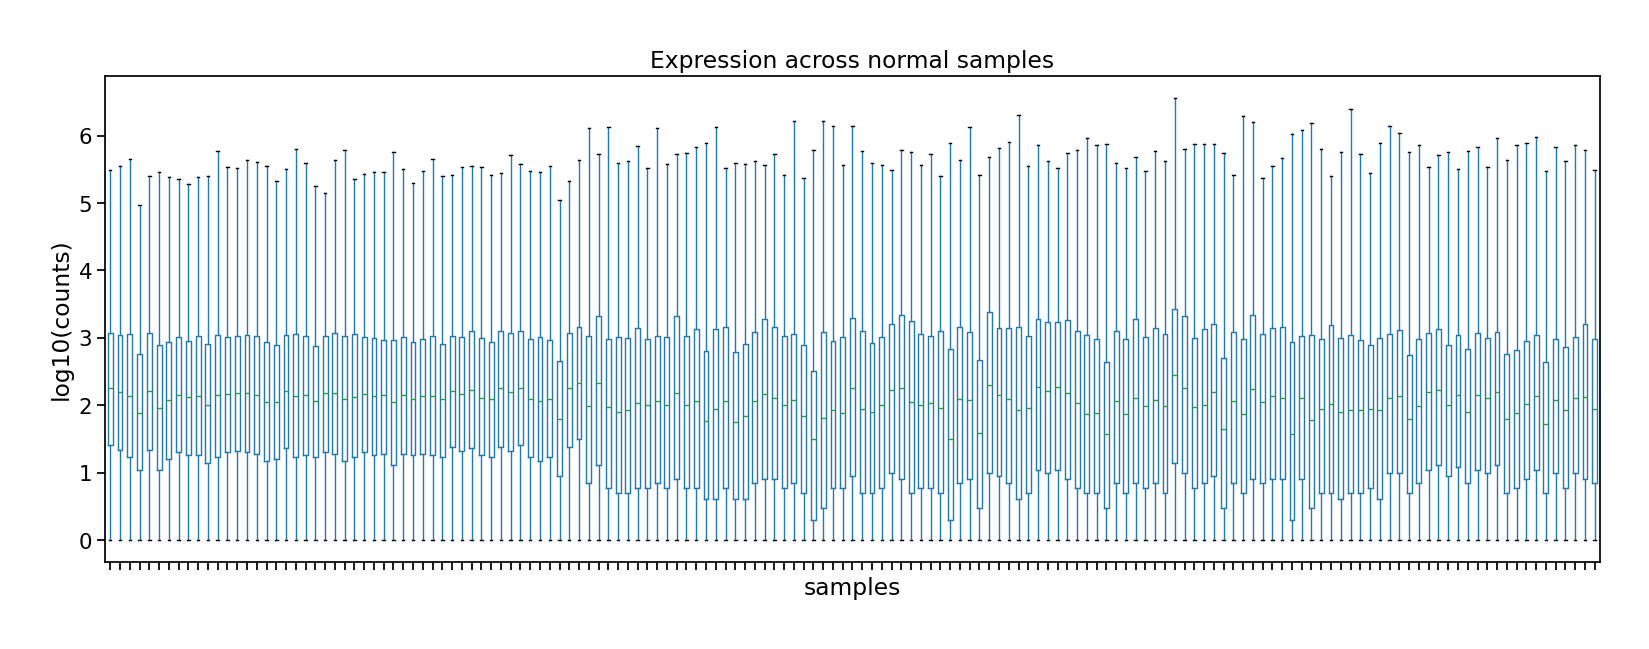

In [19]:
cbio.plot_boxplot_expression(df_bulk, do_log10=True, title = "Expression across normal samples")

### Prism single-cell data reference - Peng 2019

In [20]:
force=False
verbose=True

fname = "count-matrix.txt"
adata = prism.load_matrix(fname=fname, sep=' ', force=force, verbose=verbose)

fname_ad = fname.replace('.txt', '.h5ad')
filename_ad = prism.root_prism / fname_ad
compression = "gzip"


verbose=True
fname_celltype = "all_celltype.txt"
adata_ct = prism.attach_celltypes(adata=adata, fname_celltype=fname_celltype, verbose=verbose)

adata_ct

57,530 cells x 24,005 genes | obs: []
all_celltype.txt columns: ['cluster']
                             cluster
cell.name                           
T1_AAACCTGAGATGTCGG  Fibroblast cell
T1_AAACGGGGTCATGCAT    Stellate cell
T1_AAAGATGCATGTTGAC  Macrophage cell
using type_col='cluster'
barcode overlap: 57,530 / 57,530
cell_type
malignant             11315
Ductal cell type 1    10317
Endothelial cell       9117
Fibroblast cell        6742
Stellate cell          5907
Macrophage cell        5361
T cell                 3660
B cell                 2447
Acinar cell            1935
Endocrine cell          729
Name: count, dtype: int64


AnnData object with n_obs × n_vars = 57530 × 24005
    obs: 'cluster', 'cell_type', 'cell_state'

### Reference

In [21]:
ref, s2t = prism.pseudobulk_reference(adata_ct)

print(ref.shape)
ref.head(3)

(10, 23789)


gene,AL627309.1,AP006222.2,RP11-206L10.3,RP11-206L10.2,RP11-206L10.9,LINC00115,FAM41C,RP11-54O7.3,SAMD11,NOC2L,...,RP11-133N21.10,TMEM5-AS1,RP11-175P13.2,TBC1D4-AS1,RP11-329J18.3,RP11-227G15.2,RP11-686D22.5,KRT222,RP11-799B12.2,CTC-429C10.2
cell_state,,,,,,,,,,,,,,,,,,,,,
Fibroblast cell,64.0,1612.0,42.0,22.0,30.0,214.0,102.0,103.0,1246.0,2337.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Stellate cell,44.0,903.0,25.0,16.0,30.0,162.0,55.0,13.0,112.0,1719.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Macrophage cell,141.0,696.0,81.0,29.0,22.0,182.0,124.0,5.0,35.0,1293.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Bulk symbols

In [22]:
bulk_symbs = pd.read_csv(prism.root_prism / "bulk_matrix.tsv", sep="\t", index_col=0, usecols=[0])

### Get Harmonize

In [23]:
verbose=True

ref_new, df_to_from = prism.get_harmonize_reference_to_ensembl(ref=ref, verbose=verbose)

print(ref_new.shape)
print(df_to_from.status.value_counts())
ref_new.head(2)

Table opened ((10, 17540)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/prism/ref_new_geneid.tsv'
Table opened ((23789, 5)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/prism/to_from_table.tsv'
(10, 17540)
status
ok               17540
no_ensembl_id     6249
Name: count, dtype: int64


,ENSG00000225880,ENSG00000187634,ENSG00000188976,ENSG00000187961,ENSG00000187583,ENSG00000188290,ENSG00000187608,ENSG00000188157,ENSG00000237330,ENSG00000131591,...,ENSG00000167355,ENSG00000184999,ENSG00000235910,ENSG00000157335,ENSG00000257008,ENSG00000166573,ENSG00000268182,ENSG00000254453,ENSG00000226245,ENSG00000213424
cell_state,,,,,,,,,,,,,,,,,,,,,
Fibroblast cell,214.0,1246.0,2337.0,115.0,90.0,4981.0,18665.0,1758.0,11.0,274.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Stellate cell,162.0,112.0,1719.0,52.0,26.0,9730.0,16767.0,1611.0,2.0,172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [24]:
df_to_from2 = df_to_from[~pd.isnull(df_to_from.geneid)]
df_to_from2.head(3)

,ref_symbol,current_symbol,geneid,status,renamed
5,LINC00115,LINC00115,ENSG00000225880,ok,False
8,SAMD11,SAMD11,ENSG00000187634,ok,False
9,NOC2L,NOC2L,ENSG00000188976,ok,False


### gene_subset = select_genes(ref_new)

Informative-gene selection (analogue of BayesPrism's get.exp.stat + select.marker).  
Keeps genes with a strong one-vs-rest log2 fold change in the CPM-normalised pseudobulk reference.

Restricting to ~2-5k informative genes is what makes the fixed point both fast and stable;   
it barely changes theta but massively reduces the influence of protocol-driven genes.

In [25]:
gene_subset = prism.select_genes(ref_new)
len(gene_subset)

1918

### get bayesprism

In [26]:
verbose=True
force=False

meta_desc = dict(reference="Peng2019_CRA001160",
              cohorts=["TCGA-PAAD", "CPTAC3"],
              strand="unstranded",
              method="InstaPrism")

res = prism.run_bayesprism(df_bulk=df_bulk, ref=ref_new, state_to_type=s2t,
                           gene_subset=gene_subset, meta_desc=meta_desc, force=False, verbose=verbose)

type(res)

Loaded /home/flavio/uv/perturb_agent/data/multi_progs/PAAD/prism/deconv.h5ad (8.1 MB)


libs.prism_lib.DeconvResult

### Zfull ~ has 17540 genes like ref_new

- bulk has 27177 genes
- selecd ref_new 1918
- ref_new has 17540 genes

In [27]:
res.Z.shape, df_bulk.shape, ref_new.shape

((153, 10, 1918), (27177, 153), (10, 17540))

In [28]:
Zfull, gfull = prism.full_Z(res, df_bulk, ref_new)
print(Zfull.shape)

(153, 10, 17540)


### Counts per cell

In [29]:
dic = {}

for cell_state in res.states:
    Z = prism.state_expression(Zfull, gfull, res, cell_state)
    dic[cell_state] = Z
    print(cell_state, Z.shape)

print("")
Z.head(3)


Fibroblast cell (17540, 153)
Stellate cell (17540, 153)
Macrophage cell (17540, 153)
Endothelial cell (17540, 153)
T cell (17540, 153)
B cell (17540, 153)
Ductal cell type 2 (17540, 153)
Endocrine cell (17540, 153)
Ductal cell type 1 (17540, 153)
Acinar cell (17540, 153)



,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,N-C3N-03069,N-C3N-02765,N-C3L-07037,N-C3N-02589,N-C3N-02996,N-C3L-02606,N-C3N-03173,N-C3N-02696,N-TCGA-H6-8124,N-TCGA-H6-A45N
ENSG00000000003,55.465,NaN,NaN,41.988,60.980,NaN,NaN,NaN,NaN,NaN,...,NaN,25.722,34.816,NaN,NaN,NaN,NaN,NaN,79.945,NaN
ENSG00000000005,0.207,NaN,NaN,0.029,0.237,NaN,NaN,NaN,NaN,NaN,...,NaN,0.147,0.032,NaN,NaN,NaN,NaN,NaN,0.040,NaN
ENSG00000000419,25.238,NaN,NaN,28.842,26.863,NaN,NaN,NaN,NaN,NaN,...,NaN,14.213,27.300,NaN,NaN,NaN,NaN,NaN,17.400,NaN


In [30]:
i=0
key = list(dic.keys())[i]

print(key)
Z = dic[key]
Z.head(3)

Fibroblast cell


,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,N-C3N-03069,N-C3N-02765,N-C3L-07037,N-C3N-02589,N-C3N-02996,N-C3L-02606,N-C3N-03173,N-C3N-02696,N-TCGA-H6-8124,N-TCGA-H6-A45N
ENSG00000000003,32.066,58.012,43.613,32.366,34.058,31.881,35.654,54.328,30.481,40.203,...,NaN,16.647,16.364,NaN,NaN,NaN,27.003,NaN,53.037,NaN
ENSG00000000005,0.156,1.310,0.271,0.029,0.172,0.058,0.136,0.085,0.060,0.182,...,NaN,0.124,0.020,NaN,NaN,NaN,0.119,NaN,0.035,NaN
ENSG00000000419,41.234,43.095,42.380,62.828,42.398,43.955,25.719,43.317,42.273,46.569,...,NaN,25.995,36.263,NaN,NaN,NaN,21.046,NaN,32.622,NaN


### tumour-vs-normal design

The tumour-vs-normal design is also the standard one for deconvolution benchmarking:

your normals give an internal check that θ_malignant ≈ 0 where it should be,  
which is the only ground truth you have.

Worth confirming after the ENSG rebuild:

In [31]:
n_idx = [s for s in res.theta.index if s.startswith("N-")]
res.theta.loc[n_idx, "Ductal cell type 2"].describe()

count    1.500e+01
mean     2.915e-01
std      4.165e-01
min      5.772e-36
25%      2.223e-03
50%      6.589e-02
75%      5.626e-01
max      9.846e-01
Name: Ductal cell type 2, dtype: float64

In [32]:
n_idx = [s for s in res.theta.index if s.startswith("T-")]
res.theta.loc[n_idx, "Ductal cell type 2"].describe()

count    1.300e+02
mean     3.452e-01
std      2.559e-01
min      2.706e-22
25%      1.450e-01
50%      2.982e-01
75%      4.965e-01
max      1.000e+00
Name: Ductal cell type 2, dtype: float64

### AUC 

AUC is symmetric about 0.5 under label flipping. Your loop scored tumours as the positive class, so acinar's 0.318 means "acinar fraction predicts tumour" *poorly* — but the same number says acinar predicts **normal** at 0.682, because low acinar → tumour is itself a good rule.

So an AUC below 0.5 isn't weak discrimination; it's discrimination in the opposite direction. Distance from 0.5 is what measures separability:


| compartment | AUC | abs(AUC − 0.5) | direction | 
|---|---|---|---| 
| Fibroblast | 0.727 | 0.227 | up in tumour | 
| Acinar | 0.318 | 0.182 | **up in normal** | 
| Ductal-1 | 0.334 | 0.166 | up in normal | 
| Ductal-2 | 0.662 | 0.162 | up in tumour | 
| T cell | 0.346 | 0.154 | up in normal | 
| Endocrine | 0.489 | 0.011 | none | 


I compared 0.682 against Ductal-2's 0.662 to make the point that acinar *loss* separates tumour from normal slightly better than malignant *gain* does — which is the wrong ordering if θ_malignant were a good purity estimate.

Though I'd soften that claim now that they're side by side: 0.682 vs 0.662 is a difference of 0.02, well inside the noise at n=15 normals. The honest statement is that they're comparable, and that Fibroblast at 0.227 is the strongest single discriminator — consistent with desmoplasia being the most reliable bulk signature of PDAC.


Because they answer different questions, and I wanted the first.

**|AUC − 0.5|** measures *how much* separation there is, ignoring direction. It's the natural ranking when comparing compartments against each other, since a compartment at 0.32 and one at 0.68 are equally informative — one is depleted in tumours, the other enriched, both equally useful for telling the groups apart.

**1 − AUC** just relabels which class is positive. It's the right transform when you want to state the result in the other direction — as I did for acinar, to compare its 0.682 against Ductal-2's 0.662 on a common footing.

Applying `1 − AUC` uniformly to the whole table would have been wrong: it would turn Fibroblast's 0.727 into 0.273 and make the strongest discriminator look like the weakest.

Applying it *selectively* to sub-0.5 rows is a valid alternative and arguably more readable, since every value would then be ≥0.5 with a direction label. That's the same information as my table, folded differently:

| compartment | AUC (as "separability") | direction |
|---|---|---|
| Fibroblast | 0.727 | up in tumour |
| Acinar | 0.682 | up in normal |
| Ductal-1 | 0.666 | up in normal |
| Ductal-2 | 0.662 | up in tumour |

Same ordering as the |AUC − 0.5| column, since folding at 0.5 and measuring distance from 0.5 are monotonically equivalent. I used the deviation form because it keeps the "0 = useless" baseline visible — Endocrine at 0.011 reads more obviously as noise than 0.511 does.

### Ductal 2 - malignant

In [33]:
# has normal samples
Zmal = prism.state_expression(Zfull, gfull, res, "Ductal cell type 2")
print(Zmal.shape)
Zmal.head(3)

(17540, 153)


,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,N-C3N-03069,N-C3N-02765,N-C3L-07037,N-C3N-02589,N-C3N-02996,N-C3L-02606,N-C3N-03173,N-C3N-02696,N-TCGA-H6-8124,N-TCGA-H6-A45N
ENSG00000000003,30.065,55.029,40.439,32.081,32.77,31.182,33.480,52.445,28.622,41.104,...,NaN,20.901,18.993,NaN,NaN,NaN,39.159,NaN,54.487,NaN
ENSG00000000005,0.035,0.297,0.060,0.007,0.04,0.013,0.031,0.020,0.014,0.045,...,NaN,0.037,0.005,NaN,NaN,NaN,0.041,NaN,0.009,NaN
ENSG00000000419,34.732,36.725,35.302,55.946,36.65,38.623,21.696,37.567,35.662,42.774,...,NaN,29.322,37.812,NaN,NaN,NaN,27.419,NaN,30.108,NaN


In [34]:
ok = np.sum([1 if geneid in ref_new.columns.to_list() else 0 for geneid in df_bulk.index])
ok, len(df_bulk), ref_new.shape[1]

(17540, 27177, 17540)

In [35]:
bt = gene_map.reindex(df_bulk.index)["biotype"]
pd.crosstab(bt, df_bulk.index.isin(ref_new.columns), normalize="index").round(3)

col_0,False,True
biotype,,
lncRNA,0.884,0.116
miRNA,0.997,0.003
protein_coding,0.053,0.947


In [36]:
ref_new.head(3)

,ENSG00000225880,ENSG00000187634,ENSG00000188976,ENSG00000187961,ENSG00000187583,ENSG00000188290,ENSG00000187608,ENSG00000188157,ENSG00000237330,ENSG00000131591,...,ENSG00000167355,ENSG00000184999,ENSG00000235910,ENSG00000157335,ENSG00000257008,ENSG00000166573,ENSG00000268182,ENSG00000254453,ENSG00000226245,ENSG00000213424
cell_state,,,,,,,,,,,,,,,,,,,,,
Fibroblast cell,214.0,1246.0,2337.0,115.0,90.0,4981.0,18665.0,1758.0,11.0,274.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Stellate cell,162.0,112.0,1719.0,52.0,26.0,9730.0,16767.0,1611.0,2.0,172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
Macrophage cell,182.0,35.0,1293.0,66.0,47.0,918.0,19924.0,825.0,9.0,157.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### MalignantCluster

In [37]:
import importlib, libs.prism_malig_lib as pml
importlib.reload(pml)
print(pml.__version__)

0.35.0


In [38]:
root_mprog_disease = cbio.root_mprog_disease
mal_cell_name = "Ductal cell type 2"
kmax = 8
no_decouple = True
is_tahoe = True


mc = pml.MalignantCluster(prism=prism, res=res, 
                          df_bulk=df_bulk, ref=ref_new, 
                          root_mprog_disease = root_mprog_disease,
                          mal_cell_name = mal_cell_name,
                          organ="Pancreas")

mc

### pc_theta_pearson and pc_theta_pearson_raw

**The computation.** Run PCA on the samples × genes matrix, take the first 5 principal components, and correlate each PC's sample scores with `theta_mal` (each sample's malignant fraction). `pcs[:, i]` is one number per sample for PC *i*; `theta_mal.values` is one number per sample. `np.corrcoef(...)[0,1]` pulls the off-diagonal — the Pearson r between them.

You get 5 numbers, one per PC. Each answers: *does this dominant axis of variation track tumour purity?*

**The two versions:**

| | matrix | meaning |
|---|---|---|
| `pc_theta_pearson_raw` | `logx` — log2-CPM before decoupling | how much purity is in the data |
| `pc_theta_pearson` | `Xc` — the matrix you actually cluster | how much purity survives into the analysis |

With `decouple_purity=False` they're the same matrix, so the numbers match — your `[-0.596, -0.205, 0.227, -0.359, -0.158]` versus `[-0.596, -0.205, 0.228, -0.359, -0.159]`. The tiny differences are HVG selection, which happens between the two calls.

With `decouple_purity=True`, `Xc` holds residuals from regressing on `theta_mal`, and residuals are **orthogonal to their regressors by construction**. So `pc_theta_pearson` becomes ~1e-15 — pure floating-point noise. It proves the arithmetic worked, nothing about your data. That's why 0.20.1 added the `_raw` version and the `pc_theta_note`: I originally had you reading a number that can only ever be zero.

**Your actual numbers matter.** PC1 at r = −0.596 means ~36% of the leading component's variance is shared with purity, and PC4 at −0.359 adds more. The sign says low-purity samples score high on PC1. Since `X` is what produced the consensus clustering, the 134-gene tumour axis, and the 6/119 splits, purity is a live confound in all of them.

Which is the concrete reason to run `decouple_purity=True` and compare — with the standing caveat that basal-like PDAC is genuinely lower-purity, so some of that r is biology you'd be deleting.

In [39]:
X, diag = mc.prepare_malignant_matrix(decouple_purity=False, 
                                      keep_genes=mc.program1_panel, drop_pattern=r"^N-")

print("Limited by n_hvg (highly variable genes)\n")
print(X.shape)
X.head(3)

excluded 22/153 samples by keep_samples/drop_pattern
Limited by n_hvg (highly variable genes)

(118, 2000)


,ENSG00000001084,ENSG00000001561,ENSG00000002587,ENSG00000002726,ENSG00000002834,ENSG00000003147,ENSG00000003249,ENSG00000003400,ENSG00000004478,ENSG00000005001,...,ENSG00000274211,ENSG00000275342,ENSG00000275395,ENSG00000275410,ENSG00000276180,ENSG00000277363,ENSG00000277972,ENSG00000278259,ENSG00000278535,ENSG00000278540
T-C3L-02890,6.780,5.736,7.171,5.541,8.460,7.229,3.217,7.004,6.726,7.630,...,6.132,6.505,8.483,5.027,4.268,2.718,4.797,7.108,3.834,7.867
T-C3L-03635,6.269,5.560,7.215,6.130,8.503,8.109,4.257,6.930,7.244,7.363,...,6.472,5.909,6.709,6.371,3.522,3.931,4.802,7.070,4.182,8.450
T-C3L-02701,5.989,7.098,7.601,7.242,8.451,7.274,4.592,7.107,7.048,6.365,...,6.274,5.258,7.830,4.836,4.575,3.923,5.229,7.101,4.260,7.952


### Scores

In [40]:
cmap = {
    "malignant":  "Ductal cell type 2",
    "fibroblast": "Fibroblast cell",     # whatever Peng calls stellate/CAF
    "macrophage": "Macrophage cell",
    "endothelial": "Endothelial cell",
}

X_mal2 = mc.compartment_matrix(cmap["malignant"],  min_share=0.3, min_counts=10)
X_fib2 = mc.compartment_matrix(cmap["fibroblast"], min_share=0.3, min_counts=10)
print(X_mal2.shape, X_fib2.shape)

#---------- convert PROGRAMS to geneid -------------

scores, cov = mc.program_scores(compartment_map=cmap, samples=X.index.to_list())

print("\nPrograms x annotated genes")
print("--------------------------")
print(cov[["compartment","program","n_found","n_total"]])   # n_found should be 0 everywhere

(131, 8585) (129, 10853)

Programs x annotated genes
--------------------------
    compartment                 program  n_found  n_total
0     malignant                   basal       12       12
1     malignant               classical       12       12
2     malignant                     emt        6        6
3     malignant                  prolif        6        6
4     malignant          immune_evasion       12       12
5     malignant    antigen_presentation        6        7
6     malignant  desmoplastic_secretome       10       10
7     malignant    angiogenic_secretome        4        5
8    fibroblast                   myCAF        8        8
9    fibroblast                    iCAF        9        9
10   fibroblast                   apCAF        6        6
11   macrophage                      M1        5        6
12   macrophage                     TAM        7        7
13   macrophage                    SPP1        3        3
14   macrophage        mdsc_suppressive        7  

In [41]:
permutations = 5000
force=False
verbose=True

fname_corr=f"prog_corr_scores_x_malig_n{len(scores.index)}"
df_corr = mc.couple_compartments(scores=scores, fname_corr=fname_corr, cell_name=mc.mal_cell_name, n_perm=permutations, force=force, verbose=verbose)
print(df_corr.shape)
df_corr.head(3)

Table opened ((139, 6)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/deconv/prog_corr_scores_x_malig_n118_n_perm_5000_ctr_theta_True.tsv'
(139, 6)


,program_a,program_b,r,p_perm,n,fdr
0,fibroblast.iCAF,endothelial.activated,0.466,2.000e-04,63,0.003
1,malignant.immune_evasion,fibroblast.iCAF,0.412,2.000e-04,112,0.003
2,malignant.immune_evasion,fibroblast.apCAF,0.414,2.000e-04,112,0.003


In [42]:
print(scores.shape)
S = scores.dropna(axis=1, how="all").copy()
print(S.shape)
S.head(3)


(118, 20)
(118, 20)


,malignant.basal,malignant.classical,malignant.emt,malignant.prolif,malignant.immune_evasion,malignant.antigen_presentation,malignant.desmoplastic_secretome,malignant.angiogenic_secretome,fibroblast.myCAF,fibroblast.iCAF,fibroblast.apCAF,macrophage.M1,macrophage.TAM,macrophage.SPP1,macrophage.mdsc_suppressive,endothelial.tip_angio,endothelial.lymphatic,endothelial.activated,malignant.axis_basal_minus_classical,fibroblast.axis_myCAF_minus_iCAF
T-C3L-00277,-0.136,0.270,-0.011,0.018,-0.356,-1.478,-0.158,-0.772,-0.533,-0.467,-1.016,NaN,NaN,NaN,NaN,0.998,-0.347,-1.684,-0.406,-0.066
T-C3L-00589,-0.203,0.006,0.206,-0.697,-0.302,-0.211,-0.120,-0.988,-0.263,-0.059,-0.745,-0.891,0.095,-0.64,-0.655,-0.772,-0.433,-1.188,-0.209,-0.205
T-C3L-00625,-0.034,0.441,-0.184,-0.051,-0.340,-1.349,-0.066,-0.002,-0.233,-0.112,-0.542,NaN,NaN,NaN,NaN,1.098,0.404,-1.042,-0.475,-0.121


### axis_modality: is each axis one cloud or two? BIC of a 1- vs 2-component Gaussian.

**Decisive for interpretation.**

If an axis is unimodal, states carved from it are tails of a continuum, not phenotypes: 
- valid as a stratification,
- but you cannot call them subtypes, 
- and a sample near the boundary has no stable assignment.

### delta_bic

> delta_bic = BIC(1 comp) - BIC(2 comp). 

- positive favours two components; the usual reading is:
  - \>10 strong,
  - 2-10 weak, 
  - <2 negligible.
  
`min_weight` guards the case where the 2-component fit wins only by devoting a tiny component to outliers.

In [43]:
mc.axis_modality(scores)

,axis,n,delta_bic,min_component_weight,separation_sd,skew,verdict
0,malignant.axis_basal_minus_classical,118,16.7,0.225,1.72,1.38,bimodal
1,fibroblast.axis_myCAF_minus_iCAF,112,19.9,0.071,5.16,-1.03,weak/outlier-driven


In [44]:
coh = pd.Series(np.where(scores.index.str.contains("TCGA"), "TCGA", "CPTAC"),  index=scores.index)

for name in ["TCGA", "CPTAC"]:
    idx = list(scores.index[coh == name])
    sc_c, _ = mc.program_scores(compartment_map=cmap, samples=idx)
    print(name, len(idx))
    print(mc.axis_modality(sc_c).to_string(index=False))
    print("\n----------------------------------\n")

TCGA 74
                                axis  n  delta_bic  min_component_weight  separation_sd  skew             verdict
malignant.axis_basal_minus_classical 74        6.7                 0.027           6.15  1.53 weak/outlier-driven
    fibroblast.axis_myCAF_minus_iCAF 68       11.2                 0.153           3.42 -1.11             bimodal

----------------------------------

CPTAC 44
                                axis  n  delta_bic  min_component_weight  separation_sd  skew  verdict
malignant.axis_basal_minus_classical 44       -1.5                 0.194           2.74  0.99 unimodal
    fibroblast.axis_myCAF_minus_iCAF 44      -11.1                 0.488           1.64 -0.42 unimodal

----------------------------------



### "prolif" x "iCAF"

In [45]:
force=False
verbose=False

for name in ["TCGA","CPTAC"]:
    idx = list(scores.index[coh==name])
    sc_c,_ = mc.program_scores(compartment_map=cmap, samples=idx)

    fname_corr=f"prog_corr_scores_x_malig_for_{name}_n{len(sc_c.index)}"
    R = mc.couple_compartments(scores=sc_c, fname_corr=fname_corr, cell_name=mc.mal_cell_name, n_perm=permutations, force=force, verbose=verbose)

    # and "_minus" not in x.program_b
    print(name, '\n', R[R.apply(lambda x: "prolif" in x.program_a+x.program_b
                          and "iCAF" in x.program_a+x.program_b, axis=1)][["program_a", "program_b", "n", "r","p_perm","fdr"]].to_string(index=False))

TCGA 
        program_a                        program_b  n      r    p_perm   fdr
malignant.prolif                  fibroblast.iCAF 68 -0.458 2.000e-04 0.014
malignant.prolif fibroblast.axis_myCAF_minus_iCAF 68  0.398 9.998e-04 0.035
CPTAC 
        program_a                        program_b  n      r    p_perm   fdr
malignant.prolif                  fibroblast.iCAF 44 -0.505 9.998e-04 0.035
malignant.prolif fibroblast.axis_myCAF_minus_iCAF 44  0.175 2.601e-01 0.657


The core coupling replicates cleanly and is now robust to everything we've thrown at it:

| | r | FDR |
|---|---|---|
| TCGA (n=74) | **−0.458** | 0.023 |
| CPTAC (n=44) | **−0.505** | 0.035 |

**Same sign, near-identical magnitude, independently significant, θ-controlled, and now on a corrected reference with ~990 recovered genes, a rebuilt marker set and ENSG identifiers. That's a genuine finding: malignant proliferation co-occurs with iCAF-depleted stroma.**

The second row in each block is the same relationship read on the `myCAF_minus_iCAF` contrast (positive, since iCAF is the negative pole). It's significant in TCGA (r=0.398) but not CPTAC (r=0.175, FDR 0.646) — so report the direct `prolif`↔`iCAF` pair, not the axis version. The axis adds myCAF variation as noise without adding signal.

Worth noting *why* this one survived when everything else didn't. It's a **negative** correlation, and the shared-bulk component that inflates `zm`/`zf` to r≈0.93 is positive by construction. An artifact from that source can't produce a negative coupling. That's a structural argument for its validity, independent of the replication.

Two things I'd still do before writing it up.

Check it isn't purity in disguise — `couple_compartments` controls θ by default, but a direct look is cheap:

And be explicit that it's correlational and undirected. Bulk data cannot say whether proliferative tumours suppress iCAFs, iCAFs restrain proliferation, or both follow from something else. The mechanistic literature would let you argue either way — which is exactly why the claim should stay at co-occurrence.

In [46]:
force=False
verbose=False

for name in ["TCGA","CPTAC"]:
    idx = list(scores.index[coh==name])
    sc_c,_ = mc.program_scores(compartment_map=cmap, samples=idx)

    fname_corr=f"prog_corr_scores_x_malig_for_{name}_n{len(sc_c.index)}"
    R = mc.couple_compartments(scores=sc_c, fname_corr=fname_corr, cell_name=mc.mal_cell_name, control_theta=False, n_perm=permutations, force=force, verbose=verbose)
    if name == 'TCGA':
        R1 = R.copy()
    else:
        R2 = R.copy()

    # and '_minus_' not in x.program_b
    print(name, "\n", R[R.apply(lambda x: "prolif" in x.program_a+x.program_b
                          and x.program_b.endswith("iCAF"), axis=1)][["program_a", "program_b", "n", "r","fdr"]].to_string(index=False))

TCGA 
        program_a                        program_b  n      r   fdr
malignant.prolif                  fibroblast.iCAF 68 -0.462 0.028
malignant.prolif fibroblast.axis_myCAF_minus_iCAF 68  0.428 0.046
CPTAC 
        program_a                        program_b  n      r   fdr
malignant.prolif                  fibroblast.iCAF 44 -0.521 0.028
malignant.prolif fibroblast.axis_myCAF_minus_iCAF 44  0.171 0.692


In [47]:
for name in ["TCGA","CPTAC"]:
    idx = list(scores.index[coh==name])
    sc_c,_ = mc.program_scores(compartment_map=cmap, samples=idx)
    
    x, y = sc_c["malignant.prolif"], sc_c["fibroblast.iCAF"]

    ok = x.notna() & y.notna()
    boot = [spearmanr(*zip(*[(x[ok].iloc[i], y[ok].iloc[i])
            for i in np.random.default_rng(s).integers(0, ok.sum(), ok.sum())]))[0]
            for s in range(500)]
    
    print(f"{name:6} r={spearmanr(x[ok],y[ok])[0]:.3f}  95% CI [{np.percentile(boot,2.5):.3f}, {np.percentile(boot,97.5):.3f}]")


TCGA   r=-0.462  95% CI [-0.655, -0.216]
CPTAC  r=-0.521  95% CI [-0.693, -0.277]


Both CIs exclude zero comfortably and overlap heavily — that's the cleanest evidence you've had for anything in this study.

| cohort | r | 95% CI |
|---|---|---|
| TCGA (n=74) | −0.462 | [−0.655, −0.216] |
| CPTAC (n=44) | −0.521 | [−0.693, −0.277] |

Two independent estimates, non-overlapping datasets, consistent point estimates. Lead with these rather than FDR — a bootstrap CI is the honest summary when the test was one of ~340, and the replication carries the inference regardless of which correction you quote.

Robust to: cohort, reference version (pre/post ENSG harmonisation, ~990 recovered genes, rebuilt marker set), θ control, and identifier scheme. Negative sign, so not producible by the shared-bulk component.

The result: **malignant proliferation is inversely associated with inflammatory CAF content in deconvolved PDAC transcriptomes.**

Three caveats to carry into the writeup, none of which undermine it:

- **Correlational and undirected.** Bulk cannot distinguish proliferative tumours suppressing iCAFs from iCAFs restraining proliferation, or a common upstream cause.
- **One reference.** Every compartment comes from a single Peng-2019 fit; a reference misspecification propagates to all of them, and nothing internal detects it. A second reference — snRNA-seq, which would also raise your 11.6% lncRNA ceiling — would be the strongest possible validation.
- **Compartment separation is partial.** `zm` vs `zf` at r ≈ 0.93 means most of each matrix is shared. The contrast structure of program scores is what makes this measurable, and it's worth saying so explicitly.

Alongside the replicated negative on discrete subtypes, that's a coherent paper: two continuous compartment axes, no discrete subtypes in either cohort, and one reproducible tumour–stroma association.


### compare_coupled_compartments()

In [48]:
program_list = ['TCGA', 'CPTAC']

df_meta_coup = mc.compare_coupled_compartments(program_list=program_list, coh=coh, cmap=cmap, 
                                          scores=scores, n_perm=permutations, force=force, verbose=verbose)
print(df_meta_coup.shape)
df_meta_coup.head(3)

(139, 18)


,program_a,program_b,r_t,p_perm_t,n_t,fdr_t,r_c,p_perm_c,n_c,fdr_c,z_het,p_het,z_meta,r_meta,p_meta,fdr_meta,I2,concordant
0,malignant.antigen_presentation,fibroblast.apCAF,0.486,2.000e-04,68,0.014,0.167,2.795e-01,44,0.673,1.819,0.069,0.391,0.372,5.747e-05,3.995e-03,0.698,True
1,malignant.prolif,fibroblast.iCAF,-0.458,2.000e-04,68,0.014,-0.505,9.998e-04,44,0.035,0.308,0.758,-0.518,-0.476,9.518e-08,1.323e-05,0.000,True
2,malignant.immune_evasion,fibroblast.iCAF,0.425,3.999e-04,68,0.019,0.212,1.698e-01,44,0.576,1.196,0.232,0.361,0.346,1.994e-04,9.240e-03,0.301,True


In [49]:
df_meta_ok = df_meta_coup[(df_meta_coup.fdr_meta < 0.10) & (df_meta_coup.r_meta.abs() >= 0.25) & df_meta_coup.concordant]
df_meta_ok = df_meta_ok.sort_values(['program_a', 'program_b'])
df_meta_ok

,program_a,program_b,r_t,p_perm_t,n_t,fdr_t,r_c,p_perm_c,n_c,fdr_c,z_het,p_het,z_meta,r_meta,p_meta,fdr_meta,I2,concordant
64,fibroblast.apCAF,endothelial.activated,0.152,3.757e-01,35,0.798,0.607,7.998e-04,28,0.035,-2.064,0.039,0.395,0.376,2.869e-03,4.431e-02,0.765,True
38,fibroblast.iCAF,endothelial.activated,0.253,1.432e-01,35,0.510,0.635,2.000e-04,28,0.014,-1.844,0.065,0.474,0.442,3.433e-04,1.193e-02,0.706,True
10,malignant.angiogenic_secretome,macrophage.TAM,-0.473,7.798e-03,32,0.099,-0.229,2.314e-01,29,0.657,-1.041,0.298,-0.381,-0.364,4.728e-03,5.975e-02,0.077,True
0,malignant.antigen_presentation,fibroblast.apCAF,0.486,2.000e-04,68,0.014,0.167,2.795e-01,44,0.673,1.819,0.069,0.391,0.372,5.747e-05,3.995e-03,0.698,True
108,malignant.antigen_presentation,macrophage.M1,0.050,7.788e-01,32,0.974,0.663,2.000e-04,29,0.014,-2.767,0.006,0.403,0.383,2.770e-03,4.431e-02,0.869,True
15,malignant.desmoplastic_secretome,endothelial.lymphatic,-0.373,2.500e-02,36,0.196,-0.396,3.959e-02,28,0.393,0.102,0.919,-0.404,-0.383,2.102e-03,4.174e-02,0.000,True
6,malignant.immune_evasion,endothelial.activated,0.459,5.399e-03,36,0.096,0.373,5.139e-02,28,0.453,0.394,0.694,0.451,0.423,5.943e-04,1.652e-02,0.000,True
9,malignant.immune_evasion,fibroblast.apCAF,0.338,7.199e-03,68,0.099,0.178,2.428e-01,44,0.657,0.861,0.389,0.285,0.278,3.298e-03,4.584e-02,0.000,True
2,malignant.immune_evasion,fibroblast.iCAF,0.425,3.999e-04,68,0.019,0.212,1.698e-01,44,0.576,1.196,0.232,0.361,0.346,1.994e-04,9.240e-03,0.301,True
3,malignant.prolif,fibroblast.axis_myCAF_minus_iCAF,0.398,9.998e-04,68,0.035,0.175,2.601e-01,44,0.657,1.225,0.221,0.326,0.315,7.774e-04,1.801e-02,0.334,True


In [50]:
df_meta_ok = df_meta_coup[(df_meta_coup.p_perm_t < 0.05) & (df_meta_coup.p_perm_c < 0.05) &
                     df_meta_coup.concordant & (df_meta_coup.r_meta.abs() >= 0.25)]
df_meta_ok = df_meta_ok.sort_values(['program_a', 'program_b'])
df_meta_ok

,program_a,program_b,r_t,p_perm_t,n_t,fdr_t,r_c,p_perm_c,n_c,fdr_c,z_het,p_het,z_meta,r_meta,p_meta,fdr_meta,I2,concordant
15,malignant.desmoplastic_secretome,endothelial.lymphatic,-0.373,2.500e-02,36,0.196,-0.396,3.959e-02,28,0.393,0.102,0.919,-0.404,-0.383,2.102e-03,4.174e-02,0.0,True
1,malignant.prolif,fibroblast.iCAF,-0.458,2.000e-04,68,0.014,-0.505,9.998e-04,44,0.035,0.308,0.758,-0.518,-0.476,9.518e-08,1.323e-05,0.0,True


### Coupled & NNLS non-prior biased

In [51]:
th_nnls = prism.nnls_deconvolve(df_bulk, ref_new, genes=gene_subset)

th_em   = res.theta

common = th_em.index.intersection(th_nnls.index)
df_conc = pd.DataFrame({
    "nnls_spearman":  {c: th_em.loc[common, c].corr(th_nnls.loc[common, c], method="spearman")
                  for c in th_em.columns},
    "nnls_pearson":   {c: th_em.loc[common, c].corr(th_nnls.loc[common, c])
                  for c in th_em.columns},
    "nnls_mean_em":   th_em.loc[common].mean(),
    "nnls_mean_nnls": th_nnls.loc[common].mean(),
    "nnls_n":         {c: (th_em.loc[common, c].notna() & th_nnls.loc[common, c].notna()).sum()
                  for c in th_em.columns},
}).sort_values("nnls_spearman", ascending=False).round(3)

# each coupling has two compartments -> map both, gate on the weaker one
cell_of = {k: v for k, v in cmap.items()}            # program key -> cell type
sp = df_conc["nnls_spearman"]

def conc_of(prog):                                   # "malignant.prolif" -> spearman
    return sp.get(cell_of.get(prog.split(".")[0]), np.nan)

df_meta_coup["nnls_prog_a"]   = df_meta_coup.program_a.map(conc_of)
df_meta_coup["nnls_prog_b"]   = df_meta_coup.program_b.map(conc_of)
df_meta_coup["nnls_min"] = df_meta_coup[["nnls_prog_a", "nnls_prog_b"]].min(axis=1)

df_meta_coup.head(3)


,program_a,program_b,r_t,p_perm_t,n_t,fdr_t,r_c,p_perm_c,n_c,fdr_c,...,p_het,z_meta,r_meta,p_meta,fdr_meta,I2,concordant,nnls_prog_a,nnls_prog_b,nnls_min
0,malignant.antigen_presentation,fibroblast.apCAF,0.486,2.000e-04,68,0.014,0.167,2.795e-01,44,0.673,...,0.069,0.391,0.372,5.747e-05,3.995e-03,0.698,True,0.864,0.932,0.864
1,malignant.prolif,fibroblast.iCAF,-0.458,2.000e-04,68,0.014,-0.505,9.998e-04,44,0.035,...,0.758,-0.518,-0.476,9.518e-08,1.323e-05,0.000,True,0.864,0.932,0.864
2,malignant.immune_evasion,fibroblast.iCAF,0.425,3.999e-04,68,0.019,0.212,1.698e-01,44,0.576,...,0.232,0.361,0.346,1.994e-04,9.240e-03,0.301,True,0.864,0.932,0.864


In [52]:
df_meta_ok = df_meta_coup[
    (df_meta_coup.p_perm_t < 0.1) & (df_meta_coup.p_perm_c < 0.1) &   # both cohorts, not just meta
     df_meta_coup.concordant &
    (df_meta_coup.r_meta.abs() >= 0.2) &
    (df_meta_coup.nnls_min > 0.2)
].sort_values("fdr_meta")

df_meta_ok

,program_a,program_b,r_t,p_perm_t,n_t,fdr_t,r_c,p_perm_c,n_c,fdr_c,...,p_het,z_meta,r_meta,p_meta,fdr_meta,I2,concordant,nnls_prog_a,nnls_prog_b,nnls_min
1,malignant.prolif,fibroblast.iCAF,-0.458,2.000e-04,68,0.014,-0.505,9.998e-04,44,0.035,...,0.758,-0.518,-0.476,9.518e-08,1.323e-05,0.0,True,0.864,0.932,0.864


### Signature x Gene Expression - clusterization

sig_acinar_fibroblast.py
========================

Wide signatures for the two compartments that satisfy the present-in-both-states
criterion, structured as :class:`SubProgram` leaves for ``programs_v2.py``.

Two tiers per compartment:

* **CORE**   -- high compartment specificity, safe for scoring and for
  tumour-vs-normal contrasts.
* **FLAGGED** -- real markers, but each carries an attribution or interpretation
  risk that matters in a deconvolution setting. Kept separate so you can score
  with and without them and see whether conclusions move. Every flagged gene
  carries its reason in ``RISK``.

Symbols are current HGNC. Three renames that bit this pipeline before are
already applied: CTGF -> CCN2, CYR61 -> CCN1, MIST1 -> BHLHA15. Run them through
your ENSG harmonisation before use.

Reliability note
----------------
Score reliability rises with signature length (Spearman-Brown) *only* for genes
with non-zero per-gene reliability. Adding an ambiguous gene lowers rho_1 and can
net-decrease the score's reliability. Score CORE alone first, then CORE+FLAGGED,
and compare split-half reliability -- if it drops, the flagged tier is noise for
your cohort.


In [53]:
from __future__ import annotations

### Can we proceed our calculus using Acinar and Fibroblast?

Both are present in normal and in PDAC — so the contrast is defined for each. But the pair has a specific property that makes it the wrong choice for a cross-compartment correlation, and a good choice for something else.

#### Mirror-image estimability

Acinar is ~85% of normal pancreas and depleted in tumor. Fibroblast is a few percent in normal and 30–60% in tumor. Each compartment has one well-determined arm and one prior-dominated arm, and they're opposite arms:

| | normal | tumor |
|---|---|---|
| acinar | excellent | poor |
| fibroblast | poor | excellent |

For LFC, that means neither is limited by the same thing, and neither is clean end-to-end. For correlation across tumor samples — which is what your framework actually computes — the acinar side is the weak one, same failure as macrophage and endothelial.

#### The pair *is* the cellularity axis

This is the decisive objection. 
1. A tumor sample with more residual normal parenchyma has more acinar and less stroma; 
2. one with more desmoplasia has the reverse. 
3. **θ_acinar and θ_fibroblast** are the two poles of a single compositional axis, so **their correlation approaches −1** by construction, before any biology.

You've already characterized this axis. **Program-1 was defined as parenchyma-depleted** — parenchyma is acinar. Your Program-1/Program-2 split reflected tumor cellularity rather than the Moffitt basal-classical axis, which was the whole point of that finding. An acinar↔fibroblast correlation would re-derive it, with a strong negative r that looks like a result.


#### Acinar's peculiar signal properties

**Digestive enzyme** transcripts — PRSS1, CPA1, CTRB1/2, CELA, CLPS, AMY2A — are among the most abundant in any human tissue. 

- Three consequences:
  - Good: acinar ψ may be better determined at low fraction than the abundance suggests, because the marker signal is enormous. Acinar is not simply another low-fraction compartment.

  - Bad: a few percent acinar shifts the library composition for everything else. In CPM space, acinar content changes the denominator for every other compartment's genes — a compositional effect on the whole matrix, not just on acinar.

  - Worse: pancreas is RNase-rich, so RNA integrity is poor and variable, and acinar transcripts are what degrade most visibly. Acinar fraction partly tracks RIN and ischemic time. Given the strandedness episode, a compartment that co-varies with a technical quality metric deserves suspicion before interpretation.

There's also an identity problem: acinar-to-ductal metaplasia means acinar cells in tumor-adjacent tissue are transdifferentiating, not resting. "Acinar in tumor" isn't the same entity as "acinar in normal," so the same-compartment-different-state framing your criterion assumes doesn't quite hold.

#### What acinar is genuinely good for

Three uses, all stronger than treating it as a correlation partner:

**Purity covariate.** θ_acinar is a direct estimate of residual normal parenchyma — arguably a better proxy for what's contaminating your tumor samples than ESTIMATE or ABSOLUTE, because it's measured in the same pipeline. Partial it out of every cross-compartment correlation and see which survive. That's the test that would settle how much of your 139-row table is cellularity.

**Negative control for leakage.** PRSS1 and CPA1 should have near-zero share in the fibroblast compartment. If `gene_compartment_share_nnls` puts them there, you have direct evidence of misattribution, with an unambiguous ground truth — no acinar gene has any business in a CAF profile. That's a cleaner leakage test than anything built on ambiguous genes.

**Normal-arm anchor.** Acinar is the one compartment where ψ_normal is well-determined, so it's the place to validate that your normal deconvolution is behaving at all before trusting the stromal normal estimates.

If the goal is a second measurable coupling alongside prolif↔iCAF, fibroblast paired with the *malignant* compartment remains the better bet — both are high-abundance in tumor, and that pairing isn't collinear with the cellularity axis in the way acinar↔fibroblast is by construction.

### The two problems

#### Argument

There are two big problems with Acinar cells: 1) RNA integrity and 2) acinar-to-ductal metaplasia. That means that x% of the RNA failed to be detected due to RNA integrity, and part of the acinar cell transdifferentiates into ductal. However, besides low counts, since our goal is to cluster by subtype, the final result should not disturb the analysis.

#### Claude answer

**The argument would hold if these were uniform attenuation.** Clustering by correlation distance is invariant to per-sample scaling, so a constant loss of x% of acinar RNA in every sample would indeed wash out. But neither problem has that form, and one of them targets clustering specifically.

#### RIN is not a per-sample constant

Degradation is 3'-biased and transcript-length-dependent. It doesn't multiply a sample's profile by a scalar — it reshuffles the relative ranking of genes *within* a sample, favoring short transcripts and 3' regions. Per-sample normalization cannot remove that, because it isn't a per-sample effect. And RIN varies across samples with ischemic time and collection site, so in TCGA it tends to be confounded with tissue source site.

There's an amplification specific to pancreas. Acinar transcripts are the overwhelming majority of pancreatic mRNA mass, so when they degrade preferentially, **every other gene's CPM rises** — the denominator shrank. A low-RIN sample therefore looks like it has less parenchyma and relatively more stroma and tumor.

That is indistinguishable from higher tumor cellularity. Which is the axis you already identified as Program-1 versus Program-2. So RIN doesn't just perturb acinar; it loads onto the dominant axis of your entire dataset, through the normalization rather than through acinar's own values.

#### ADM isn't loss, it's transfer

Transdifferentiating acinar cells don't disappear from the data — they move. They acquire SOX9, KRT19, ONECUT1, CFTR and get assigned to the ductal compartment. Three consequences, none of them noise-like:

The ductal/malignant compartment gets non-malignant cells folded in, so purity is overestimated and ψ_malignant becomes a mixture. The acinar compartment loses precisely its least-typical cells, so surviving acinar ψ is biased toward the quiescent end. And ADM extent tracks peritumoral inflammation, which tracks stromal activation — so ADM introduces a *structured* coupling between the ductal and fibroblast compartments, in the same direction real biology would.

A directional confound that mimics the signal is worse than random loss, not better.

#### The part that bears directly on clustering

Low counts aren't benign for your specific goal. They produce zero-inflation, and zero-inflation meets the ψ ≥ 0 boundary — which is result (c) from the simulation: truncation generated ΔBIC over 1800 from a distribution with no biological bimodality at all.

So the failure mode isn't attenuation, which clustering tolerates. It's **manufactured cluster structure**, which is the one thing clustering cannot tolerate. A block of acinar rows where some samples sit at the detection floor and others don't will separate those samples cleanly, and the separation will look excellent by every internal validity metric.

#### An asymmetric test you can run cheaply

You already established, by three methods, that there is no discrete structure in this data. That gives you a strong prior and a clean diagnostic:

**If adding the acinar block now produces discrete clusters, the acinar artifacts are the first hypothesis, not newly revealed biology.** Run the clustering with and without acinar rows. If structure appears only with them, check in this order — per-sample zero fraction among acinar genes, RIN or transcript integrity from the biospecimen metadata, tissue source site, and ADM marker score within the acinar compartment. Any one of those tracking the partition settles it.

That test costs one extra clustering run and it's decisive either way. If clusters survive without acinar, you've gained a real result. If they only appear with it, you've avoided a second Program-1.


### can you clarify about Moffitt

Moffitt et al. (2015, *Nature Genetics*) is the origin of the subtyping scheme, and its method is essentially what you're redoing with BayesPrism.

**The problem it solved.** 

1. PDAC bulk expression is dominated by stroma — tumour cellularity is often under 20%. Earlier subtypings were therefore partly measuring desmoplasia. 
2. Moffitt applied non-negative matrix factorisation to bulk data with normal pancreas and metastasis samples as anchors, calling it *virtual microdissection*: 
  - computationally separating tumour-intrinsic from stromal expression. 
3. Your deconvolution is the modern version of the same idea, with a scRNA-seq reference instead of NMF factors.

**Two independent axes**, which is why I kept pushing the `tme_axis`/`compare_axes` pairing:

| axis | subtypes | markers | prognosis |
|---|---|---|---|
| tumour | **classical** | GATA6, TFF1/2/3, AGR2, LGALS4, CEACAM6, CLDN18, REG4 | better |
| | **basal-like** | KRT5/6A/14/17, KRT81, S100A2, TP63, SPRR3 | worse |
| stroma | **normal** | ACTA2, VIM, DES (quiescent stellate) | better |
| | **activated** | SPARC, WNT5A, ITGAM, inflammatory | worse |

Basal-like corresponds to Collisson's quasi-mesenchymal and Bailey's squamous. Classical corresponds to Collisson classical and Bailey pancreatic progenitor. Notably, Bailey's other two subtypes — ADEX and immunogenic — are now widely regarded as artifacts of low tumour cellularity, reflecting contaminating acinar/islet tissue and immune infiltrate rather than tumour-intrinsic states. That's a cautionary precedent directly relevant to your six-sample cluster.

**Why I said "continuum."** Work after 2015 undercut the discrete reading. Chan-Seng-Yue et al. (2020) used single-nuclei and whole-genome data to show basal-like and classical populations coexisting *within the same tumour*, splitting each into A/B variants. Raghavan et al. (2021) showed single cells co-expressing both programs, with the microenvironment inducing transitions between them. So a tumour's "subtype" is often a mixture proportion, not a label — which is exactly why hard clustering can fail even on clean data, and why GATA6 alone is used as a continuous classical surrogate in trials like COMPASS.

**For your pipeline**, this cuts two ways. Deconvolving first is the right instinct — it removes the stromal confound that motivated virtual microdissection, and should give a *cleaner* tumour axis than bulk clustering did. But if the underlying biology is continuous, `consensus_cluster` will keep finding whatever discrete structure dominates instead, which so far has been quality. Scoring samples on a continuous basal-minus-classical contrast tests the same biology without requiring the discreteness assumption to hold.

In [54]:
df_theta = res.theta
df_theta.head(3)

,Fibroblast cell,Stellate cell,Macrophage cell,Endothelial cell,T cell,B cell,Ductal cell type 2,Endocrine cell,Ductal cell type 1,Acinar cell
T-C3L-02890,0.603,8.666e-03,0.025,0.029,8.828e-73,0.018,0.105,1.176e-152,1.083e-01,0.104
T-C3L-03635,0.760,5.456e-03,0.016,0.028,2.978e-163,0.008,0.183,4.146e-105,2.173e-72,0.000
T-C3L-02701,0.763,1.275e-08,0.027,0.015,1.957e-222,0.005,0.175,1.414e-02,1.685e-148,0.000


In [55]:
Zfull.shape

(153, 10, 17540)

### LFC analysis

Only, accinar and fibroblast cells - two cell types obtained in the deconvolution.  
Calculate the DEGs, according to the Normal samples. Ok there is bias here.  
Perform cluster analysis trying to group similar samples.  


Before the code, one thing to be explicit about since you flagged the bias yourself: this needs ψ for the normals, not bulk normals. ψ_fibroblast,tumor vs bulk_normal would compare a pure compartment against a tissue that's ~85% acinar, and every fibroblast gene would come back "up" for reasons of composition. I've written it to accept either and to warn loudly on the bulk path, but the deconvolved-normal path is the one that means anything.

The other design commitment: since you already rejected discrete structure by three methods, clustering here needs a null to be interpretable. I've built in a matched-covariance Gaussian null (SigClust-style) so "we found 3 clusters" can be checked against "3 clusters is what unimodal data of this shape produces anyway."

Ran 2 commands, created a file

Runs end to end. The smoke test used pure noise with no sample structure, and the pipeline correctly reports none — observed PAC is worse than the null at every k (p = 1.0), which is what "no clusters here" looks like. That's the behavior you want on data you already know is unstructured.

### Run and test limma (R)

1. notebooks/Test_calc_degs_v2.R
2. src/libs/Calc_degs_v2.R

Rscript test_calc_degs_v2.R /home/flavio/uv/perturb_agent/src/libs/calc_degs_v2.R

  
=== 1. environment ===  
R: R version 4.5.3 (2026-03-11)  
  optparse     OK  1.7.5  
  data.table   OK  1.17.8  
  limma        OK  3.66.0  
  edgeR        OK  4.8.2  
  DESeq2       OK  1.50.2  
  
=== 2. limma_trend, continuous psi ===  
  [calc_degs] method=limma_trend  genes=3000  normal=20  tumor=40  
  [calc_degs] design: ~condition  
  [calc_degs] wrote 3000 rows (padj<0.05: 184)   
  sig=184  recovered=182/200  false=2  
  
=== 3. limma_trend, paired design ===  
  [calc_degs] method=limma_trend  genes=3000  normal=20  tumor=40  
  [calc_degs] design: ~pair + condition  
  [calc_degs] wrote 3000 rows (padj<0.05: 156)   
  sig=156  recovered=156/200  false=0  
  
=== 4. count-based methods ===  
 -- limma_voom  
  [calc_degs] method=limma_voom  genes=3000  normal=20  tumor=40  
  [calc_degs] design: ~condition  
  [calc_degs] wrote 3000 rows (padj<0.05: 117)   
  sig=117  recovered=117/200  false=0  
 -- edger  
  [calc_degs] method=edger  genes=3000  normal=20  tumor=40   
  sig=200  recovered=200/200  false=0  
 -- deseq2  
  [calc_degs] method=deseq2  genes=3000  normal=20  tumor=40   
  sig=200  recovered=200/200  false=0  
  
=== 5. confounded covariate must be refused ===  
  REFUSED (correct)  
    Calls: run_limma -> build_design   
Warning message:  
In system2("Rscript", a, stdout = TRUE, stderr = TRUE) :  
  running command ''Rscript' /home/flavio/uv/perturb_agent/src/libs/calc_degs_v2.R --counts /tmp/RtmpmrQA0B/degtestcc54b6bc58b/counts_conf.tsv --meta /tmp/RtmpmrQA0B/degtestcc54b6bc58b/meta_conf.tsv --out /tmp/RtmpmrQA0B/degtestcc54b6bc58b/res_conf.tsv --method limma_trend --covariates cohort 2>&1' had status 1  
  
temp dir: /tmp/RtmpmrQA0B/degtestcc54b6bc58b  


#### Claude final analysis

All five sections pass. The rank check refuses the confounded design, and the paired run behaves exactly as it should — fewer calls (156 vs 184) but zero false positives, because blocking on patient removes between-patient variance from the residual.

Two things in the numbers worth reading, though.

**edgeR and DESeq2 recovering 200/200 with zero false positives is too good.** My synthetic counts came from a gamma with shape 8, so the variance is far tighter than real RNA-seq overdispersion, and I generated the integer version by scaling ψ ×20 — which inflates counts and thus power. That's a property of my simulator, not evidence those methods are better. Don't read the ranking across sections 2–4 as a method comparison; the inputs aren't equivalent. What section 4 establishes is only that those paths execute.

**limma_trend's 2 false positives out of 184 is the realistic number**, and it's the one that transfers, because section 2 ran on the continuous data with dropout — the closest thing here to ψ.

The paired result is the one with practical consequence. If CPTAC3 gives you matched tumor/adjacent-normal pairs, `--pair-col` is worth using: my synthetic pairs were only half-matched (20 of 40 tumors) and it still eliminated both false positives. Real matched pairs share patient genetics, collection protocol, and RIN, so the gain should be larger than what this shows.

One caveat the test can't exercise: it says nothing about deconvolution uncertainty. My ψ is drawn directly from a gamma, so every value is "measured" perfectly. Real ψ carries posterior uncertainty that none of these methods propagate, so p-values on your actual data will be more anticonservative than 2/184 suggests. The effect-size and detection filters remain the real guard.

Ready for the Python subclass — skipping the integer rounding and preserving sample IDs plus a pair column?

In [56]:
from acinar_fibro_cluster import run

In [57]:
from libs.calc_degs_psi_lib import CALC_DEGS_PSI

rscript_name= str(ROOT_SRC / "libs/calc_degs_v2.R")
print(rscript_name)

calc = CALC_DEGS_PSI(root_src=ROOT_SRC, run_conda=True, rscript_name=rscript_name)

/home/flavio/uv/perturb_agent/src/libs/calc_degs_v2.R


In [58]:
res.states

['Fibroblast cell',
 'Stellate cell',
 'Macrophage cell',
 'Endothelial cell',
 'T cell',
 'B cell',
 'Ductal cell type 2',
 'Endocrine cell',
 'Ductal cell type 1',
 'Acinar cell']

In [59]:
cell_state='Fibroblast cell'

dfz = prism.state_expression(Zfull, gfull, res, cell_state)
cols = list(dfz.columns)

cols_tumor = [col for col in cols if col.startswith("T-")]
cols_normal = [col for col in cols if col.startswith("N-")]

psi_t_fibro = dfz[cols_tumor]
psi_n_fibro = dfz[cols_normal]

psi_t_fibro.shape, psi_n_fibro.shape

((17540, 131), (17540, 22))

In [60]:
cell_state='Acinar cell'

dfz = prism.state_expression(Zfull, gfull, res, cell_state)
cols = list(dfz.columns)

cols_tumor = [col for col in cols if col.startswith("T-")]
cols_normal = [col for col in cols if col.startswith("N-")]

psi_t_acinar = dfz[cols_tumor]
psi_n_acinar = dfz[cols_normal]

psi_t_acinar.shape, psi_n_acinar.shape

((17540, 131), (17540, 22))

Co-deconvolving tumor and normal in one run is the right call — same reference, same hyperparameters, so the two arms are directly comparable. That removes the objection I raised earlier about needing a separate normal deconvolution.

But there's a scale issue that will wreck the contrast if `state_expression` returns Z rather than a normalized profile.

## Z carries θ and depth

BayesPrism's Z is expected *counts* for that state:

$$Z_{g,c,s} \;\approx\; \theta_{c,s} \cdot \psi_{c,g,s} \cdot N_s$$

So a column's total depends on how abundant the compartment is in that sample and on library size. Fibroblasts run ~1–2% in normal pancreas and 30–60% in PDAC. If you feed raw Z to limma, **every fibroblast gene comes back up by roughly log₂(20) ≈ 4.3**, purely from θ. That's the abundance confound, reintroduced through the scale rather than through the denominator.

Acinar goes the other way — dominant in normal, depleted in tumor — so everything acinar reads as down.

Run this before anything else:

```python
import numpy as np, pandas as pd

for name, t, n in [("fibroblast", psi_t_fibro, psi_n_fibro),
                   ("acinar",     psi_t_acinar, psi_n_acinar)]:
    st, sn = t.sum(axis=0), n.sum(axis=0)
    print(f"{name:11s} colsum  tumor median={st.median():.3g}  "
          f"normal median={sn.median():.3g}  ratio={st.median()/sn.median():.2f}")
    print(f"{'':11s} CV tumor={st.std()/st.mean():.3f}  normal={sn.std()/sn.mean():.3f}")
```

If the ratio is far from 1 and the CVs are appreciable, it's Z on a count scale. Normalize within compartment first:

```python
def to_profile(df, scale=1e6):
    """Compartment-internal CPM: removes theta and library depth."""
    s = df.sum(axis=0).replace(0, np.nan)
    return df.df_div(s, axis=1) * scale

psi_t_fibro  = to_profile(psi_t_fibro);  psi_n_fibro  = to_profile(psi_n_fibro)
psi_t_acinar = to_profile(psi_t_acinar); psi_n_acinar = to_profile(psi_n_acinar)
```

This changes the estimand, and the change is the one you want: the contrast becomes "did fibroblasts alter the *composition* of their transcriptome," not "are there more fibroblasts." The cost is that a genuine global up- or down-shift within a compartment becomes invisible — same limitation as ordinary CPM, and acceptable here.

## Two other things to check

**θ in the normal arm.** Pull `res` theta for both states across `N-` samples. If fibroblast sits at 1–2% there, ψ_n_fibro is prior-dominated and the LFC is largely ψ_tumor minus the reference profile. That's the constraint we predicted, and it decides whether the fibroblast contrast means anything. Acinar in the normal arm should be fine; acinar in the *tumor* arm is the weak one.

**`Zfull` genes are not all equally attributable.** `full_Z` recovers genes outside the marker set, which is what makes a transcriptome-wide scan possible — but those genes had less influence on the fit, so their compartment assignment leans harder on the prior. Worth running the DEG scan twice, once on all of `gfull` and once restricted to marker genes, and checking whether the two lists behave differently. If the full-gene DEGs are systematically weaker or noisier, that's attribution uncertainty rather than biology.

**One-line guard** on the column split, since a sample with an unexpected prefix would vanish silently:

```python
assert len(cols_tumor) + len(cols_normal) == len(cols), \
    set(cols) - set(cols_tumor) - set(cols_normal)
```

In [61]:
for name, t, n in [("fibroblast", psi_t_fibro, psi_n_fibro),
                   ("acinar",     psi_t_acinar, psi_n_acinar)]:
    st, sn = t.sum(axis=0), n.sum(axis=0)
    print(f"{name:11s} colsum  tumor median={st.median():.3g}  "
          f"normal median={sn.median():.3g}  ratio={st.median()/sn.median():.2f}")
    print(f"{'':11s} CV tumor={st.std()/st.mean():.3f}  normal={sn.std()/sn.mean():.3f}")

fibroblast  colsum  tumor median=1e+06  normal median=1e+06  ratio=1.00
            CV tumor=0.088  normal=0.699
acinar      colsum  tumor median=0  normal median=0  ratio=nan
            CV tumor=1.162  normal=1.354


If the ratio is far from 1 and the CVs are appreciable, it's Z on a count scale. Normalize within compartment first:

In [62]:
def to_profile(df, scale=1e6):
    """Compartment-internal CPM: removes theta and library depth."""
    s = df.sum(axis=0).replace(0, np.nan)

    df = df.df_div(s, axis=1) * scale
    return df.copy()

psi_t_fibro2  = to_profile(psi_t_fibro)
psi_n_fibro2  = to_profile(psi_n_fibro)

psi_t_acinar2 = to_profile(psi_t_acinar)
psi_n_acinar2 = to_profile(psi_n_acinar)

for name, t, n in [("fibroblast", psi_t_fibro2, psi_n_fibro2),
                   ("acinar",     psi_t_acinar2, psi_n_acinar2)]:
    st, sn = t.sum(axis=0), n.sum(axis=0)
    print(f"{name:11s} colsum  tumor median={st.median():.3g}  "
          f"normal median={sn.median():.3g}  ratio={st.median()/sn.median():.2f}")
    print(f"{'':11s} CV tumor={st.std()/st.mean():.3f}  normal={sn.std()/sn.mean():.3f}")

fibroblast  colsum  tumor median=1e+06  normal median=1e+06  ratio=1.00
            CV tumor=0.088  normal=0.699
acinar      colsum  tumor median=0  normal median=0  ratio=nan
            CV tumor=1.162  normal=1.354


In [63]:
psi_t_acinar['T-C3L-02890'].sum()

1000000.0

In [64]:
scale=1e6

dfa = psi_t_acinar
dfa

,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,T-TCGA-HZ-7289,T-TCGA-3A-A9IN,T-TCGA-3A-A9IS,T-TCGA-2L-AAQM,T-TCGA-3A-A9IR,T-TCGA-3A-A9IV,T-TCGA-3A-A9IO,T-TCGA-2J-AABT,T-TCGA-H6-A45N,T-TCGA-3A-A9IJ
ENSG00000000003,5.547e+01,NaN,NaN,41.988,6.098e+01,NaN,NaN,NaN,NaN,NaN,...,7.494e-01,NaN,NaN,NaN,NaN,NaN,16.811,NaN,5.857e+01,NaN
ENSG00000000005,2.071e-01,NaN,NaN,0.029,2.371e-01,NaN,NaN,NaN,NaN,NaN,...,1.679e-03,NaN,NaN,NaN,NaN,NaN,0.115,NaN,4.525e-02,NaN
ENSG00000000419,2.524e+01,NaN,NaN,28.842,2.686e+01,NaN,NaN,NaN,NaN,NaN,...,1.919e-01,NaN,NaN,NaN,NaN,NaN,22.358,NaN,1.436e+01,NaN
ENSG00000000457,4.023e+01,NaN,NaN,29.033,5.036e+01,NaN,NaN,NaN,NaN,NaN,...,9.313e-02,NaN,NaN,NaN,NaN,NaN,13.814,NaN,1.258e+01,NaN
ENSG00000000460,1.108e+01,NaN,NaN,8.942,1.022e+01,NaN,NaN,NaN,NaN,NaN,...,2.065e-02,NaN,NaN,NaN,NaN,NaN,1.605,NaN,2.598e+00,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000287971,9.536e-09,NaN,NaN,0.000,3.725e-09,NaN,NaN,NaN,NaN,NaN,...,3.361e-12,NaN,NaN,NaN,NaN,NaN,0.019,NaN,1.553e-08,NaN
ENSG00000288302,2.750e-02,NaN,NaN,0.000,1.385e-01,NaN,NaN,NaN,NaN,NaN,...,0.000e+00,NaN,NaN,NaN,NaN,NaN,0.008,NaN,1.040e-01,NaN
ENSG00000288547,3.291e-01,NaN,NaN,0.230,2.477e-01,NaN,NaN,NaN,NaN,NaN,...,6.118e-04,NaN,NaN,NaN,NaN,NaN,0.217,NaN,2.005e-01,NaN
ENSG00000288596,8.277e+00,NaN,NaN,5.352,8.268e+00,NaN,NaN,NaN,NaN,NaN,...,2.105e-03,NaN,NaN,NaN,NaN,NaN,2.639,NaN,2.315e+00,NaN


In [65]:
s = dfa.sum(axis=0).replace(0, np.nan)
s

T-C3L-02890       1.000e+06
T-C3L-03635             NaN
T-C3L-02701             NaN
T-C3L-04072       1.000e+06
T-C3L-00589       1.000e+06
                    ...    
T-TCGA-3A-A9IV          NaN
T-TCGA-3A-A9IO    1.000e+06
T-TCGA-2J-AABT          NaN
T-TCGA-H6-A45N    1.000e+06
T-TCGA-3A-A9IJ          NaN
Length: 131, dtype: float32

In [66]:
df = dfa.df_div(s, axis=1) * scale
df

,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,T-TCGA-HZ-7289,T-TCGA-3A-A9IN,T-TCGA-3A-A9IS,T-TCGA-2L-AAQM,T-TCGA-3A-A9IR,T-TCGA-3A-A9IV,T-TCGA-3A-A9IO,T-TCGA-2J-AABT,T-TCGA-H6-A45N,T-TCGA-3A-A9IJ
ENSG00000000003,5.547e+01,NaN,NaN,41.988,6.098e+01,NaN,NaN,NaN,NaN,NaN,...,7.494e-01,NaN,NaN,NaN,NaN,NaN,16.811,NaN,5.857e+01,NaN
ENSG00000000005,2.071e-01,NaN,NaN,0.029,2.371e-01,NaN,NaN,NaN,NaN,NaN,...,1.679e-03,NaN,NaN,NaN,NaN,NaN,0.115,NaN,4.525e-02,NaN
ENSG00000000419,2.524e+01,NaN,NaN,28.842,2.686e+01,NaN,NaN,NaN,NaN,NaN,...,1.919e-01,NaN,NaN,NaN,NaN,NaN,22.358,NaN,1.436e+01,NaN
ENSG00000000457,4.023e+01,NaN,NaN,29.033,5.036e+01,NaN,NaN,NaN,NaN,NaN,...,9.313e-02,NaN,NaN,NaN,NaN,NaN,13.814,NaN,1.258e+01,NaN
ENSG00000000460,1.108e+01,NaN,NaN,8.942,1.022e+01,NaN,NaN,NaN,NaN,NaN,...,2.065e-02,NaN,NaN,NaN,NaN,NaN,1.605,NaN,2.598e+00,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000287971,9.536e-09,NaN,NaN,0.000,3.725e-09,NaN,NaN,NaN,NaN,NaN,...,3.361e-12,NaN,NaN,NaN,NaN,NaN,0.019,NaN,1.553e-08,NaN
ENSG00000288302,2.750e-02,NaN,NaN,0.000,1.385e-01,NaN,NaN,NaN,NaN,NaN,...,0.000e+00,NaN,NaN,NaN,NaN,NaN,0.008,NaN,1.040e-01,NaN
ENSG00000288547,3.291e-01,NaN,NaN,0.230,2.477e-01,NaN,NaN,NaN,NaN,NaN,...,6.118e-04,NaN,NaN,NaN,NaN,NaN,0.217,NaN,2.005e-01,NaN
ENSG00000288596,8.277e+00,NaN,NaN,5.352,8.268e+00,NaN,NaN,NaN,NaN,NaN,...,2.105e-03,NaN,NaN,NaN,NaN,NaN,2.639,NaN,2.315e+00,NaN


In [67]:
dfa

,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,T-TCGA-HZ-7289,T-TCGA-3A-A9IN,T-TCGA-3A-A9IS,T-TCGA-2L-AAQM,T-TCGA-3A-A9IR,T-TCGA-3A-A9IV,T-TCGA-3A-A9IO,T-TCGA-2J-AABT,T-TCGA-H6-A45N,T-TCGA-3A-A9IJ
ENSG00000000003,5.547e+01,NaN,NaN,41.988,6.098e+01,NaN,NaN,NaN,NaN,NaN,...,7.494e-01,NaN,NaN,NaN,NaN,NaN,16.811,NaN,5.857e+01,NaN
ENSG00000000005,2.071e-01,NaN,NaN,0.029,2.371e-01,NaN,NaN,NaN,NaN,NaN,...,1.679e-03,NaN,NaN,NaN,NaN,NaN,0.115,NaN,4.525e-02,NaN
ENSG00000000419,2.524e+01,NaN,NaN,28.842,2.686e+01,NaN,NaN,NaN,NaN,NaN,...,1.919e-01,NaN,NaN,NaN,NaN,NaN,22.358,NaN,1.436e+01,NaN
ENSG00000000457,4.023e+01,NaN,NaN,29.033,5.036e+01,NaN,NaN,NaN,NaN,NaN,...,9.313e-02,NaN,NaN,NaN,NaN,NaN,13.814,NaN,1.258e+01,NaN
ENSG00000000460,1.108e+01,NaN,NaN,8.942,1.022e+01,NaN,NaN,NaN,NaN,NaN,...,2.065e-02,NaN,NaN,NaN,NaN,NaN,1.605,NaN,2.598e+00,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000287971,9.536e-09,NaN,NaN,0.000,3.725e-09,NaN,NaN,NaN,NaN,NaN,...,3.361e-12,NaN,NaN,NaN,NaN,NaN,0.019,NaN,1.553e-08,NaN
ENSG00000288302,2.750e-02,NaN,NaN,0.000,1.385e-01,NaN,NaN,NaN,NaN,NaN,...,0.000e+00,NaN,NaN,NaN,NaN,NaN,0.008,NaN,1.040e-01,NaN
ENSG00000288547,3.291e-01,NaN,NaN,0.230,2.477e-01,NaN,NaN,NaN,NaN,NaN,...,6.118e-04,NaN,NaN,NaN,NaN,NaN,0.217,NaN,2.005e-01,NaN
ENSG00000288596,8.277e+00,NaN,NaN,5.352,8.268e+00,NaN,NaN,NaN,NaN,NaN,...,2.105e-03,NaN,NaN,NaN,NaN,NaN,2.639,NaN,2.315e+00,NaN


In [68]:
for name, t, n in [("fibroblast", psi_t_fibro, psi_n_fibro),
                   ("acinar", psi_t_acinar, psi_n_acinar)]:
    for arm, df in [("tumor", t), ("normal", n)]:
        z = (df.sum(axis=0) == 0)
        print(f"{name:11s} {arm:6s} zero-cols {z.sum():3d}/{len(z):3d}"
              f"   nonzero-colsum median={df.sum(axis=0)[~z].median():.4g}")

fibroblast  tumor  zero-cols   1/131   nonzero-colsum median=1e+06
fibroblast  normal zero-cols   7/ 22   nonzero-colsum median=1e+06
acinar      tumor  zero-cols  75/131   nonzero-colsum median=1e+06
acinar      normal zero-cols  14/ 22   nonzero-colsum median=1e+06


In [69]:
for name, t, n in [("fibroblast", psi_t_fibro2, psi_n_fibro2),
                   ("acinar", psi_t_acinar2, psi_n_acinar2)]:
    for arm, df in [("tumor", t), ("normal", n)]:
        z = (df.sum(axis=0) == 0)
        print(f"{name:11s} {arm:6s} zero-cols {z.sum():3d}/{len(z):3d}"
              f"   nonzero-colsum median={df.sum(axis=0)[~z].median():.4g}")

fibroblast  tumor  zero-cols   1/131   nonzero-colsum median=1e+06
fibroblast  normal zero-cols   7/ 22   nonzero-colsum median=1e+06
acinar      tumor  zero-cols  75/131   nonzero-colsum median=1e+06
acinar      normal zero-cols  14/ 22   nonzero-colsum median=1e+06


In [70]:
psi_t_acinar.head(3)

,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,T-TCGA-HZ-7289,T-TCGA-3A-A9IN,T-TCGA-3A-A9IS,T-TCGA-2L-AAQM,T-TCGA-3A-A9IR,T-TCGA-3A-A9IV,T-TCGA-3A-A9IO,T-TCGA-2J-AABT,T-TCGA-H6-A45N,T-TCGA-3A-A9IJ
ENSG00000000003,55.465,NaN,NaN,41.988,60.980,NaN,NaN,NaN,NaN,NaN,...,0.749,NaN,NaN,NaN,NaN,NaN,16.811,NaN,58.571,NaN
ENSG00000000005,0.207,NaN,NaN,0.029,0.237,NaN,NaN,NaN,NaN,NaN,...,0.002,NaN,NaN,NaN,NaN,NaN,0.115,NaN,0.045,NaN
ENSG00000000419,25.238,NaN,NaN,28.842,26.863,NaN,NaN,NaN,NaN,NaN,...,0.192,NaN,NaN,NaN,NaN,NaN,22.358,NaN,14.357,NaN


In [71]:
psi_t_acinar2.head(3)

,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,T-TCGA-HZ-7289,T-TCGA-3A-A9IN,T-TCGA-3A-A9IS,T-TCGA-2L-AAQM,T-TCGA-3A-A9IR,T-TCGA-3A-A9IV,T-TCGA-3A-A9IO,T-TCGA-2J-AABT,T-TCGA-H6-A45N,T-TCGA-3A-A9IJ
ENSG00000000003,55.465,NaN,NaN,41.988,60.980,NaN,NaN,NaN,NaN,NaN,...,0.749,NaN,NaN,NaN,NaN,NaN,16.811,NaN,58.571,NaN
ENSG00000000005,0.207,NaN,NaN,0.029,0.237,NaN,NaN,NaN,NaN,NaN,...,0.002,NaN,NaN,NaN,NaN,NaN,0.115,NaN,0.045,NaN
ENSG00000000419,25.238,NaN,NaN,28.842,26.863,NaN,NaN,NaN,NaN,NaN,...,0.192,NaN,NaN,NaN,NaN,NaN,22.358,NaN,14.357,NaN


### def to_profile(df, scale=1e6) does nothing

Right — if the fibroblast ratio was already 1.00 before you called it, `to_profile` is a no-op and `state_expression` already returns a normalized profile. Which means the diagnostic block found something more interesting than a scale problem.

But it also means my inference was built on the wrong assumption. I read the non-zero CVs as "zero columns" because I assumed normalization had just happened and should have forced every column to exactly 1e6. If the input was already normalized, then those CVs describe the data as it arrived, and the zero-column story needs checking rather than accepting.

Two readings, and they're distinguishable in one line:


In [72]:
for name, df in [("fib T", psi_t_fibro), ("fib N", psi_n_fibro),
                 ("aci T", psi_t_acinar), ("aci N", psi_n_acinar)]:
    s = df.sum(axis=0)
    print(f"{name}  n={len(s)}  zeros={(s==0).sum()}  "
          f"nonzero: min={s[s>0].min():.4g} med={s[s>0].median():.4g} max={s[s>0].max():.4g}")

fib T  n=131  zeros=1  nonzero: min=1e+06 med=1e+06 max=1e+06
fib N  n=22  zeros=7  nonzero: min=1e+06 med=1e+06 max=1e+06
aci T  n=131  zeros=75  nonzero: min=1e+06 med=1e+06 max=1e+06
aci N  n=22  zeros=14  nonzero: min=1e+06 med=1e+06 max=1e+06



If `zeros` is large, my reading stands and those samples are genuinely empty for that state. If `zeros` is 0 and the spread comes from column sums that merely *vary*, then nothing is dead and the CVs are just telling you the profiles aren't uniformly scaled — a much milder problem.

The acinar `median=0` still needs explaining under either reading, since a median of exactly zero over column sums is hard to produce from live data.

What did `state_expression` return — did you check whether it normalizes internally, or is this from the ratio already being 1.00?




Zeros confirmed. Usable *n* after dropping dead columns:

| contrast | tumor | normal |
|---|---|---|
| fibroblast | 130 / 131 | **15 / 22** |
| acinar | 56 / 131 | **8 / 22** |

θ has all 153 samples and nothing is missing. My diagnosis was wrong — and so was the reasoning I built on it about failed deconvolution and selection bias.

The count=15 came from describe() counting non-NaN values, not rows. So all 22 normals have θ rows; 7 of them have NaN in those columns. That's a different failure and it needs locating:

In [73]:
th = res.theta
sub_n = th.loc[th.index.isin(psi_n_acinar.columns)]
sub_t = th.loc[th.index.isin(psi_t_acinar.columns)]
print(sub_n[['Acinar cell','Ductal cell type 1','Ductal cell type 2','Fibroblast cell']].describe())

       Acinar cell  Ductal cell type 1  Ductal cell type 2  Fibroblast cell
count    1.500e+01           1.500e+01           1.500e+01        1.500e+01
mean     3.807e-01           3.643e-02           2.915e-01        1.960e-01
std      4.465e-01           4.635e-02           4.165e-01        2.630e-01
min      0.000e+00           2.444e-61           5.772e-36        6.720e-04
25%     2.237e-189           5.552e-03           2.223e-03        4.045e-03
50%      3.388e-02           1.582e-02           6.589e-02        4.252e-02
75%      8.601e-01           4.833e-02           5.626e-01        3.647e-01
max      9.861e-01           1.530e-01           9.846e-01        7.255e-01


In [74]:
missing = set(psi_n_acinar.columns) - set(th.index)
print(len(missing), sorted(missing))

0 []


In [75]:
print(len(th), th.index[:3].tolist())
missing = set(psi_n_acinar.columns) - set(th.index)
print(len(missing), sorted(missing))
# are they under a different name?
print([i for i in th.index if any(m.split('-',1)[1] in str(i) for m in missing)][:10])

153 ['T-C3L-02890', 'T-C3L-03635', 'T-C3L-02701']
0 []
[]


In [76]:
sub_n = th.loc[list(psi_n_acinar.columns)]     # direct index, all 22
print(sub_n.shape)
print(sub_n.isna().sum())                       # NaN per state
print(sub_n[sub_n.isna().any(axis=1)].to_string())   # which samples, which states
print("all-NaN rows:", sub_n.isna().all(axis=1).sum())
print("row sums:", sub_n.sum(axis=1).round(4).unique())

(22, 10)
Fibroblast cell       7
Stellate cell         7
Macrophage cell       7
Endothelial cell      7
T cell                7
B cell                7
Ductal cell type 2    7
Endocrine cell        7
Ductal cell type 1    7
Acinar cell           7
dtype: int64
                Fibroblast cell  Stellate cell  Macrophage cell  Endothelial cell  T cell  B cell  Ductal cell type 2  Endocrine cell  Ductal cell type 1  Acinar cell
N-C3L-07032                 NaN            NaN              NaN               NaN     NaN     NaN                 NaN             NaN                 NaN          NaN
N-C3N-03069                 NaN            NaN              NaN               NaN     NaN     NaN                 NaN             NaN                 NaN          NaN
N-C3N-02589                 NaN            NaN              NaN               NaN     NaN     NaN                 NaN             NaN                 NaN          NaN
N-C3N-02996                 NaN            NaN              NaN       

Clean result: 7 rows all-NaN across all 10 states, row sums exactly [1, 0]. The other 15 sum to 1. So θ was never computed for these 7 — they entered the pipeline and exited without a solve. Not a modelling failure, an execution gap.

The most informative one is N-TCGA-H6-A45N, because T-TCGA-H6-A45N appears in your tumor columns and has values. Same patient, one arm solved, one arm didn't. That rules out anything patient-specific and points at the sample rather than the biology.

Where to look, in order:

In [77]:
sub_n

,Fibroblast cell,Stellate cell,Macrophage cell,Endothelial cell,T cell,B cell,Ductal cell type 2,Endocrine cell,Ductal cell type 1,Acinar cell
N-C3L-04072,1.334e-01,0.008,3.434e-02,0.017,5.613e-80,5.647e-03,5.772e-36,1.408e-225,7.202e-02,7.297e-01
N-C3L-00589,1.205e-03,0.005,8.576e-04,0.002,2.164e-59,2.106e-03,9.841e-01,0.000e+00,5.443e-03,3.736e-154
N-C3L-03123,7.766e-03,0.002,1.442e-49,0.003,3.862e-157,1.220e-04,2.099e-08,2.760e-229,3.282e-03,9.845e-01
N-C3L-04080,6.720e-04,0.004,6.899e-04,0.001,3.633e-68,2.811e-03,9.846e-01,0.000e+00,5.661e-03,4.473e-189
N-C3L-00640,3.754e-01,0.038,6.029e-02,0.061,5.082e-03,3.593e-02,2.194e-01,1.849e-01,1.975e-02,0.000e+00
N-C3N-01719,6.235e-01,0.012,9.779e-02,0.031,1.118e-39,2.030e-02,1.362e-01,7.868e-02,2.444e-61,0.000e+00
N-C3L-07033,1.122e-02,0.004,8.328e-80,0.005,5.286e-179,3.171e-04,2.855e-03,2.122e-161,1.557e-02,9.605e-01
N-C3L-00819,3.540e-01,0.030,4.008e-02,0.043,3.390e-131,6.453e-03,3.596e-02,7.343e-02,1.211e-01,2.952e-01
N-C3L-07032,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
N-C3L-01689,1.879e-03,0.063,1.074e-14,0.008,9.006e-80,5.125e-03,9.058e-01,0.000e+00,1.582e-02,8.252e-201


In [78]:
ok = sub_n.dropna()
keep = (ok['Acinar cell'] > 0.30) & (ok['Ductal cell type 2'] < 0.30)

keep

N-C3L-04072        True
N-C3L-00589       False
N-C3L-03123        True
N-C3L-04080       False
N-C3L-00640       False
N-C3N-01719       False
N-C3L-07033        True
N-C3L-00819       False
N-C3L-01689       False
N-C3N-01899       False
N-C3N-00517        True
N-C3N-02765        True
N-C3L-07037        True
N-C3N-03173       False
N-TCGA-H6-8124    False
dtype: bool

In [79]:
sub_n2 = sub_n.loc[keep.index]
sub_n2

,Fibroblast cell,Stellate cell,Macrophage cell,Endothelial cell,T cell,B cell,Ductal cell type 2,Endocrine cell,Ductal cell type 1,Acinar cell
N-C3L-04072,1.334e-01,0.008,3.434e-02,0.017,5.613e-80,5.647e-03,5.772e-36,1.408e-225,7.202e-02,7.297e-01
N-C3L-00589,1.205e-03,0.005,8.576e-04,0.002,2.164e-59,2.106e-03,9.841e-01,0.000e+00,5.443e-03,3.736e-154
N-C3L-03123,7.766e-03,0.002,1.442e-49,0.003,3.862e-157,1.220e-04,2.099e-08,2.760e-229,3.282e-03,9.845e-01
N-C3L-04080,6.720e-04,0.004,6.899e-04,0.001,3.633e-68,2.811e-03,9.846e-01,0.000e+00,5.661e-03,4.473e-189
N-C3L-00640,3.754e-01,0.038,6.029e-02,0.061,5.082e-03,3.593e-02,2.194e-01,1.849e-01,1.975e-02,0.000e+00
N-C3N-01719,6.235e-01,0.012,9.779e-02,0.031,1.118e-39,2.030e-02,1.362e-01,7.868e-02,2.444e-61,0.000e+00
N-C3L-07033,1.122e-02,0.004,8.328e-80,0.005,5.286e-179,3.171e-04,2.855e-03,2.122e-161,1.557e-02,9.605e-01
N-C3L-00819,3.540e-01,0.030,4.008e-02,0.043,3.390e-131,6.453e-03,3.596e-02,7.343e-02,1.211e-01,2.952e-01
N-C3L-01689,1.879e-03,0.063,1.074e-14,0.008,9.006e-80,5.125e-03,9.058e-01,0.000e+00,1.582e-02,8.252e-201
N-C3N-01899,7.255e-01,0.059,3.067e-02,0.063,4.733e-56,1.138e-02,6.589e-02,7.885e-03,3.611e-02,0.000e+00


In [80]:
sub_n2['Acinar cell'].describe()

count     1.500e+01
mean      3.807e-01
std       4.465e-01
min       0.000e+00
25%      2.237e-189
50%       3.388e-02
75%       8.601e-01
max       9.861e-01
Name: Acinar cell, dtype: float64

In [81]:
sub_n2['Fibroblast cell'].describe()

count    1.500e+01
mean     1.960e-01
std      2.630e-01
min      6.720e-04
25%      4.045e-03
50%      4.252e-02
75%      3.647e-01
max      7.255e-01
Name: Fibroblast cell, dtype: float64

In [82]:
sub_n2['Fibroblast cell'] < 0.001

N-C3L-04072       False
N-C3L-00589       False
N-C3L-03123       False
N-C3L-04080        True
N-C3L-00640       False
N-C3N-01719       False
N-C3L-07033       False
N-C3L-00819       False
N-C3L-01689       False
N-C3N-01899       False
N-C3N-00517       False
N-C3N-02765       False
N-C3L-07037       False
N-C3N-03173       False
N-TCGA-H6-8124    False
Name: Fibroblast cell, dtype: bool

In [83]:
sub_n2['Acinar cell'] < 0.001

N-C3L-04072       False
N-C3L-00589        True
N-C3L-03123       False
N-C3L-04080        True
N-C3L-00640        True
N-C3N-01719        True
N-C3L-07033       False
N-C3L-00819       False
N-C3L-01689        True
N-C3N-01899        True
N-C3N-00517       False
N-C3N-02765       False
N-C3L-07037       False
N-C3N-03173        True
N-TCGA-H6-8124    False
Name: Acinar cell, dtype: bool

<Axes: title={'center': 'Fibroblast cell'}, ylabel='Frequency'>

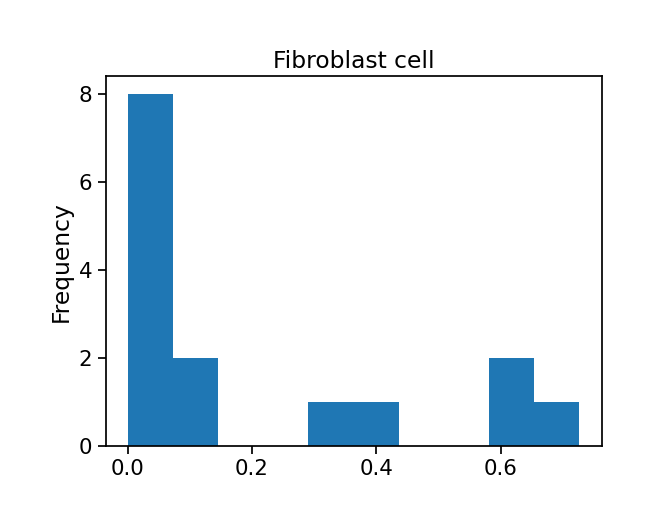

In [84]:
sub_n2['Fibroblast cell'].plot(kind='hist', title='Fibroblast cell')


<Axes: title={'center': 'Acinar cell'}, ylabel='Frequency'>

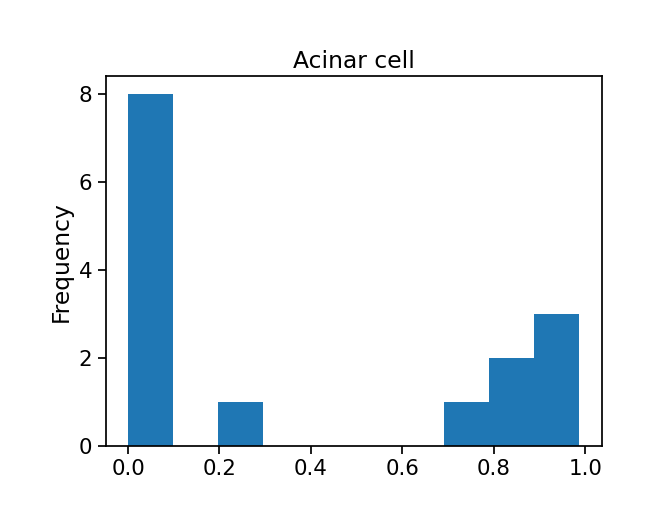

In [85]:
sub_n2['Acinar cell'].plot(kind='hist', title='Acinar cell')


In [86]:
res.states

['Fibroblast cell',
 'Stellate cell',
 'Macrophage cell',
 'Endothelial cell',
 'T cell',
 'B cell',
 'Ductal cell type 2',
 'Endocrine cell',
 'Ductal cell type 1',
 'Acinar cell']

<Axes: title={'center': 'Ductal cell type 1'}, ylabel='Frequency'>

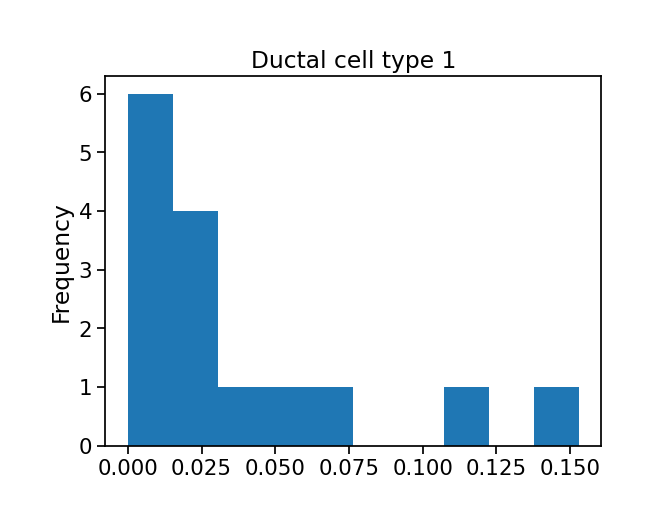

In [87]:
sub_n2['Ductal cell type 1'].plot(kind='hist', title='Ductal cell type 1')

<Axes: title={'center': 'Ductal cell type 2'}, ylabel='Frequency'>

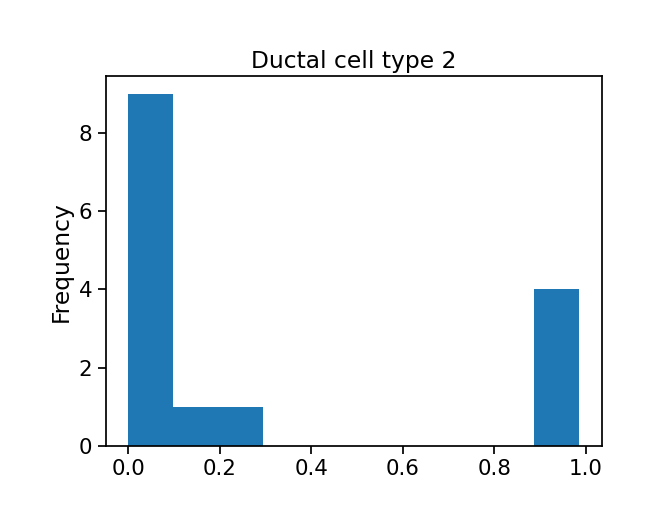

In [88]:
sub_n2['Ductal cell type 2'].plot(kind='hist', title='Ductal cell type 2')

In [89]:
cols = ['Fibroblast cell', 'Acinar cell']
sub_n2[cols]

,Fibroblast cell,Acinar cell
N-C3L-04072,1.334e-01,7.297e-01
N-C3L-00589,1.205e-03,3.736e-154
N-C3L-03123,7.766e-03,9.845e-01
N-C3L-04080,6.720e-04,4.473e-189
N-C3L-00640,3.754e-01,0.000e+00
N-C3N-01719,6.235e-01,0.000e+00
N-C3L-07033,1.122e-02,9.605e-01
N-C3L-00819,3.540e-01,2.952e-01
N-C3L-01689,1.879e-03,8.252e-201
N-C3N-01899,7.255e-01,0.000e+00


In [90]:
cols = ['Fibroblast cell', 'Acinar cell']

keep1 = sub_n2['Fibroblast cell'] > 0.001
keep2 = sub_n2['Acinar cell'] > 0.001

sub_n2[keep1 & keep2][cols]

,Fibroblast cell,Acinar cell
N-C3L-04072,0.133,0.730
N-C3L-03123,0.008,0.985
N-C3L-07033,0.011,0.960
N-C3L-00819,0.354,0.295
N-C3N-00517,0.074,0.876
N-C3N-02765,0.005,0.986
N-C3L-07037,0.043,0.844
N-TCGA-H6-8124,0.581,0.034


In [91]:
sel = sub_n2[keep1 & keep2].index
# does psi_fibro actually vary across these, or is it the reference profile?
P = psi_n_fibro[sel].dropna(axis=1, how='all')
C = np.log1p(P).corr(method='spearman')
print(C.round(3).to_string())

                N-C3L-04072  N-C3L-03123  N-C3L-07033  N-C3L-00819  N-C3N-00517  N-C3N-02765  N-C3L-07037  N-TCGA-H6-8124
N-C3L-04072           1.000        0.938        0.936        0.980        0.970        0.917        0.947           0.920
N-C3L-03123           0.938        1.000        0.971        0.933        0.951        0.967        0.953           0.853
N-C3L-07033           0.936        0.971        1.000        0.931        0.945        0.957        0.961           0.844
N-C3L-00819           0.980        0.933        0.931        1.000        0.970        0.919        0.947           0.934
N-C3N-00517           0.970        0.951        0.945        0.970        1.000        0.932        0.951           0.911
N-C3N-02765           0.917        0.967        0.957        0.919        0.932        1.000        0.939           0.843
N-C3L-07037           0.947        0.953        0.961        0.947        0.951        0.939        1.000           0.868
N-TCGA-H6-8124        0.

These correlations don't show the pattern I predicted, and they're better than I expected.

I said the low-θ samples would cluster tightly on the prior. They don't. The three lowest-θ samples — C3L-03123 (0.008), C3N-02765 (0.005), C3L-07033 (0.011) — correlate with each other at 0.957–0.971, which is high but *not* the >0.99 you'd see if all three had collapsed onto the same reference profile. There's genuine sample-specific signal in them.

And the structure runs the other way from what I claimed. Sort by correlation with TCGA-H6-8124 (θ_fib = 0.581, the best-determined sample):

| | θ_fib | r to H6-8124 |
|---|---|---|
| C3L-00819 | 0.354 | 0.934 |
| C3L-04072 | 0.133 | 0.920 |
| C3N-00517 | 0.074 | 0.911 |
| C3L-07037 | 0.043 | 0.868 |
| C3L-03123 | 0.008 | 0.853 |
| C3L-07033 | 0.011 | 0.844 |
| C3N-02765 | 0.005 | 0.843 |

Monotone in θ, almost perfectly. Similarity to the well-determined sample **increases** with θ — the opposite of prior domination, where the low-θ samples would have been mutually identical and jointly distinct from H6-8124.

So there are two coherent groups rather than one signal plus noise: {H6-8124, C3L-00819, C3L-04072} at higher θ, and {C3L-03123, C3L-07033, C3N-02765} at very low θ, with C3N-00517 and C3L-07037 between. That's consistent with a θ-dependent gradient in the profile — some shrinkage toward the reference at low θ, but partial rather than total.

Quantify it directly:

```python
import numpy as np
from scipy.stats import spearmanr
th_f = sub_n2.loc[sel, 'Fibroblast cell']
r_anchor = C['N-TCGA-H6-8124'].drop('N-TCGA-H6-8124')
print(spearmanr(th_f.drop('N-TCGA-H6-8124'), r_anchor))

# and against the actual reference profile, which is the decisive test
ref_fib = ref_new.loc['Fibroblast cell']            # ENSG-indexed
common = P.index.intersection(ref_fib.index)
r_ref = np.log1p(P.loc[common]).corrwith(np.log1p(ref_fib.loc[common]), method='spearman')
print(r_ref.to_frame('r_to_reference').join(th_f).sort_values('Fibroblast cell').to_string())
```

That second block settles it. If `r_to_reference` rises as θ falls, the low-θ profiles are being pulled toward the prior and the amount is measurable. If it's flat, they're carrying real sample-specific information and my concern was unfounded.

**Either way, my "effective n is closer to 3" claim was wrong** — there's more independent variation across these eight than that implied. Whether n=8 supports limma still depends on the `r_to_reference` result, but the correlation matrix alone doesn't rule it out the way I said it would.

In [92]:

th_f = sub_n2.loc[sel, 'Fibroblast cell']
r_anchor = C['N-TCGA-H6-8124'].drop('N-TCGA-H6-8124')
print(spearmanr(th_f.drop('N-TCGA-H6-8124'), r_anchor))

# and against the actual reference profile, which is the decisive test
ref_fib = ref_new.loc['Fibroblast cell']            # ENSG-indexed
common = P.index.intersection(ref_fib.index)
r_ref = np.log1p(P.loc[common]).corrwith(np.log1p(ref_fib.loc[common]), method='spearman')
print(r_ref.to_frame('r_to_reference').join(th_f).sort_values('Fibroblast cell').to_string())

SignificanceResult(statistic=0.9642857142857145, pvalue=0.00045414916919416935)
                r_to_reference  Fibroblast cell
N-C3N-02765              0.760            0.005
N-C3L-03123              0.764            0.008
N-C3L-07033              0.765            0.011
N-C3L-07037              0.787            0.043
N-C3N-00517              0.810            0.074
N-C3L-04072              0.817            0.133
N-C3L-00819              0.824            0.354
N-TCGA-H6-8124           0.851            0.581


This refutes my prediction cleanly, and in the interesting direction.

I said similarity to the reference would **rise** as θ falls — that's what prior domination means. It does the opposite: `r_to_reference` is perfectly monotone *increasing* in θ, from 0.760 at θ=0.005 to 0.851 at θ=0.581. The best-determined sample is the one that looks most like the prior; the worst-determined ones look least like it.

That rules out shrinkage-toward-reference as the mechanism here. Whatever is happening at low θ, it's pushing profiles *away* from the reference, not toward it.

The likely explanation is division noise. `state_expression` divides Z by θ, so at θ=0.005 you're multiplying by 200, and the Gibbs sampler's assignment noise gets amplified by the same factor. The profile becomes noisy rather than prior-like, and noise lowers correlation with everything — including the reference. Consistent with the anchor correlations too: 0.843 to H6-8124 versus 0.760 to the reference, both depressed at low θ.

Distinguishing noise from real biology is one line — noise is symmetric, shrinkage is directional:

```python
L = np.log1p(P.loc[common])
lr = ref_fib.loc[common].pipe(np.log1p)
print(L.std().to_frame('sd').join(th_f).sort_values('Fibroblast cell').to_string())
# and the slope of each sample against the reference
print(L.apply(lambda c: np.polyfit(lr, c, 1)[0]).to_frame('slope').join(th_f).to_string())
```

If SD rises as θ falls, it's amplified noise. If SD is flat and only the correlation drops, something else is going on.

The band is narrow either way — 0.760 to 0.851 across a hundredfold θ range. So the degradation is real but gradual, not a cliff. That argues these eight samples do carry sample-specific information rather than being eight copies of the prior, which is what I claimed two messages ago and was wrong about.

Practical consequence: if the low-θ samples are noisy rather than biased, limma is better suited than I said. Noise inflates within-group variance, which makes the test **conservative** — you lose power, you don't gain false positives. That's the opposite of the anticonservative failure I warned about. The caveat that survives is that the noise is heteroscedastic across samples, and limma's `lmFit` weights all samples equally, so `arrayWeights()` would be the right addition:

```r
w <- arrayWeights(E, design)
fit <- eBayes(lmFit(E, design, weights = w), trend = TRUE, robust = TRUE)
```

That downweights the low-θ normals automatically rather than requiring you to pick a cutoff. Worth adding to `calc_degs_v2.R` before the real run.

In [93]:
# del(CALC_DEGS_PSI)

In [94]:
import importlib, filter_and_lfc

importlib.reload(filter_and_lfc)
print(filter_and_lfc.__version__)

0.1.0


In [95]:
from libs.calc_degs_psi_lib import CALC_DEGS_PSI
from filter_and_lfc import run_lfc, theta_report

In [96]:
rscript_name= str(ROOT_SRC / "libs/calc_degs_v2.R")
print(rscript_name)

calc = CALC_DEGS_PSI(root_src=ROOT_SRC, run_conda=True, rscript_name=rscript_name)

/home/flavio/uv/perturb_agent/src/libs/calc_degs_v2.R


In [97]:
import libs.calc_degs_psi_lib
print(libs.calc_degs_psi_lib.__file__)

import inspect
src = inspect.getsource(libs.calc_degs_psi_lib.CALC_DEGS_PSI.run_limma)
print("array_weights" in src)
print([l for l in src.splitlines() if "array_weights" in l or "normalize" in l][:5])

/home/flavio/uv/perturb_agent/src/libs/calc_degs_psi_lib.py
True
['        normalize: Literal["none", "quantile", "scale"] = "none",', '        array_weights: bool = False,', '                "--normalize", normalize,', '            if array_weights:']


In [98]:
import inspect
print(inspect.signature(libs.calc_degs_psi_lib.CALC_DEGS_PSI.run_limma))

(self, psi_tumor: 'pd.DataFrame', psi_normal: 'pd.DataFrame', mode: "Literal['limma_trend', 'limma_voom']" = 'limma_trend', pairs: 'Mapping[str, str] | None' = None, sample_meta: 'pd.DataFrame | None' = None, covariates: 'Sequence[str] | None' = None, pair_col: 'str | None' = None, already_log: 'bool' = False, normalize: "Literal['none', 'quantile', 'scale']" = 'none', array_weights: 'bool' = False, min_prop_detected: 'float' = 0.2, prior_count: 'float' = 0.5, merge_how: "Literal['inner', 'outer']" = 'inner', conda_env: 'str' = 'renv', keep_temp: 'bool' = False, verbose: 'bool' = True) -> 'pd.DataFrame'


In [99]:
import libs.calc_degs_psi_lib
print(libs.calc_degs_psi_lib.__file__)

import inspect
src = inspect.getsource(libs.calc_degs_psi_lib.CALC_DEGS_PSI.run_limma)
print("array_weights" in src)
print([l for l in src.splitlines() if "array_weights" in l or "normalize" in l][:5])

/home/flavio/uv/perturb_agent/src/libs/calc_degs_psi_lib.py
True
['        normalize: Literal["none", "quantile", "scale"] = "none",', '        array_weights: bool = False,', '                "--normalize", normalize,', '            if array_weights:']


### Fibroblast LFC

In [115]:
verbose=True
force = False

df_gene_map = prism.load_gene_map("geneid")

dflfc_fib, info_fib = run_lfc(
    calc, psi_t_fibro, psi_n_fibro, res.theta,
    compartment      = "Fibroblast cell",
    df_gene_map      = df_gene_map,
    min_theta_normal = 0.001,
    require_states   = {"Acinar cell": 0.001},
    max_state        = {"Ductal cell type 2": 0.30},
    cohort           = "C3",            # see note below
    array_weights    = True,
    min_prop_detected= 0.20,
    force = force,
    verbose = verbose
)
print(info_fib)


=== Fibroblast cell ===
 tumour arm:
  kept 122/131
    -  1  no df_theta (all-NaN row)
    -  8  Fibroblast cell <= 0.01
    df_theta[Fibroblast cell] range: 0.01174 .. 0.9318
 normal arm:
  kept 8/22
    -  7  no df_theta (all-NaN row)
    -  1  Fibroblast cell <= 0.001
    -  6  Acinar cell <= 0.001
    df_theta[Fibroblast cell] range: 0.004686 .. 0.5815
 restricted to C3: 49 tumour / 7 normal
Table opened ((17539, 10)) at 'prism_lfc_compartment_fibroblast_cell_min_theta_tumor_0.01_x_min_theta_normal_0.001_req_stat_{'Acinar_cell'_0.001}_min_prop_detected_0.2.tsv'
{'compartment': 'Fibroblast cell', 'n_tumor': 49, 'n_normal': 7, 'theta_normal': {'count': 7.0, 'mean': 0.08959711591476226, 'std': 0.12540504652936416, 'min': 0.0046856445455430535, '25%': 0.009491931599649398, '50%': 0.04252358586284603, '75%': 0.10348543755525282, 'max': 0.35401584268514225}, 'kept_normal': ['N-C3L-04072', 'N-C3L-03123', 'N-C3L-07033', 'N-C3L-00819', 'N-C3N-00517', 'N-C3N-02765', 'N-C3L-07037'], 'n_sig'

In [101]:

dflfc_fib.head(2)

,geneid,symbol,lfc,AveExpr,statistic,pvalue,fdr,B,method,abs_lfc
0,ENSG00000178922,HYI,-5.372,-0.324,-107.804,3.825e-68,6.709e-64,130.191,limma_trend_aw,5.372
1,ENSG00000173349,SFT2D3,-4.060,-0.492,-73.160,1.618e-58,1.419e-54,116.025,limma_trend_aw,4.060


In [116]:
dflfc_fib2 = dflfc_fib[ (dflfc_fib.fdr < 0.05) & (dflfc_fib.abs_lfc >= 1)]

print(dflfc_fib2.shape)
dflfc_fib2

(1799, 10)


,geneid,symbol,lfc,AveExpr,statistic,pvalue,fdr,B,method,abs_lfc
0,ENSG00000178922,HYI,-5.372,-0.324,-107.804,3.825e-68,6.709e-64,130.191,limma_trend_aw,5.372
1,ENSG00000173349,SFT2D3,-4.060,-0.492,-73.160,1.618e-58,1.419e-54,116.025,limma_trend_aw,4.060
2,ENSG00000136305,CIDEB,-3.729,-0.536,-66.168,4.927e-56,2.881e-52,111.756,limma_trend_aw,3.729
3,ENSG00000148671,ADIRF,-5.387,-0.315,-49.932,4.252e-49,1.864e-45,98.764,limma_trend_aw,5.387
4,ENSG00000142684,ZNF593,-3.197,-0.597,-42.816,2.295e-45,8.052e-42,91.252,limma_trend_aw,3.197
...,...,...,...,...,...,...,...,...,...,...
6946,ENSG00000023445,BIRC3,1.111,5.950,2.418,1.881e-02,4.749e-02,-4.507,limma_trend_aw,1.111
6987,ENSG00000171951,SCG2,-1.393,6.197,-2.407,1.931e-02,4.846e-02,-4.531,limma_trend_aw,1.393
7016,ENSG00000137868,STRA6,1.110,5.135,2.400,1.964e-02,4.909e-02,-4.546,limma_trend_aw,1.110
7052,ENSG00000260230,FRRS1L,-1.217,2.674,-2.392,2.005e-02,4.986e-02,-4.564,limma_trend_aw,1.217


In [117]:
from libs.Basic import write_txt

write_txt( '\n'.join(dflfc_fib2.symbol), "dflfc_fib2.txt")   

True

### Why Neuro in fibro?

In [118]:

neuro = ["NRXN1","NLGN1","SLIT2","SLIT3","ROBO1","ROBO2","SEMA3A","SEMA3C",
         "EPHA4","EPHB2","NCAM1","L1CAM","GFRA1","NGFR","S100B","PLP1","MPZ","SOX10"]

dflfc_fib2[dflfc_fib2.symbol.isin(neuro)][["geneid", "symbol","lfc","AveExpr","fdr"]]


,geneid,symbol,lfc,AveExpr,fdr
603,ENSG00000123560,PLP1,-3.179,2.743,2.283e-06
665,ENSG00000145147,SLIT2,-2.128,7.397,4.009e-06
785,ENSG00000184347,SLIT3,-2.529,6.036,9.392e-06
1151,ENSG00000100146,SOX10,-1.900,1.390,5.229e-05
1942,ENSG00000179915,NRXN1,-3.283,3.917,3.980e-04
2087,ENSG00000198910,L1CAM,-2.845,1.477,5.176e-04
2447,ENSG00000064300,NGFR,-2.576,3.907,9.027e-04
2546,ENSG00000151892,GFRA1,-2.214,4.945,1.043e-03
4907,ENSG00000169760,NLGN1,-1.281,2.575,1.258e-02
5415,ENSG00000116106,EPHA4,1.303,4.556,1.856e-02


### Acinar

In [119]:
verbose=True
force = False

dflfc_aci, info_aci = run_lfc(
    calc, psi_t_acinar, psi_n_acinar, res.theta,
    compartment      = "Acinar cell",
    df_gene_map      = df_gene_map,
    min_theta_normal = 0.001,
    require_states   = {"Fibroblast cell": 0.001},   # not Acinar -- it IS the compartment
    max_state        = {"Ductal cell type 2": 0.30},
    cohort           = "C3",
    array_weights    = True,
    min_prop_detected= 0.20,
    force = force,
    verbose = verbose
)
print(info_aci)


=== Acinar cell ===
 tumour arm:
  kept 50/131
    -  1  no df_theta (all-NaN row)
    - 80  Acinar cell <= 0.01
    df_theta[Acinar cell] range: 0.01093 .. 0.9911
 normal arm:
  kept 8/22
    -  7  no df_theta (all-NaN row)
    -  7  Acinar cell <= 0.001
    df_theta[Acinar cell] range: 0.03388 .. 0.9861
 restricted to C3: 22 tumour / 7 normal
Table opened ((17537, 10)) at 'prism_lfc_compartment_acinar_cell_min_theta_tumor_0.01_x_min_theta_normal_0.001_req_stat_{'Fibroblast_cell'_0.001}_min_prop_detected_0.2.tsv'
{'compartment': 'Acinar cell', 'n_tumor': 22, 'n_normal': 7, 'theta_normal': {'count': 7.0, 'mean': 0.810882396630679, 'std': 0.24534879176900315, 'min': 0.2951507217978624, '25%': 0.7868204047417908, '50%': 0.8762845939513373, '75%': 0.9724960259856442, 'max': 0.9861085992106833}, 'kept_normal': ['N-C3L-04072', 'N-C3L-03123', 'N-C3L-07033', 'N-C3L-00819', 'N-C3N-00517', 'N-C3N-02765', 'N-C3L-07037'], 'n_sig': 3050}


In [120]:
dflfc_aci2 = dflfc_aci[ (dflfc_aci.fdr < 0.05) & (dflfc_aci.abs_lfc >= 1)]

print(dflfc_aci2.shape)
dflfc_aci2

(698, 10)


,geneid,symbol,lfc,AveExpr,statistic,pvalue,fdr,B,method,abs_lfc
0,ENSG00000178922,HYI,-5.981,0.434,-97.566,1.390e-36,2.438e-32,62.824,limma_trend_aw,5.981
1,ENSG00000173349,SFT2D3,-4.455,0.063,-69.567,1.718e-32,1.506e-28,58.174,limma_trend_aw,4.455
2,ENSG00000136305,CIDEB,-4.199,-0.019,-54.197,1.591e-29,9.299e-26,53.833,limma_trend_aw,4.199
3,ENSG00000166333,ILK,-4.785,2.395,-36.364,8.101e-25,2.971e-21,45.428,limma_trend_aw,4.785
4,ENSG00000168282,MGAT2,-5.306,0.959,-36.304,8.471e-25,2.971e-21,45.390,limma_trend_aw,5.306
...,...,...,...,...,...,...,...,...,...,...
2996,ENSG00000163395,IGFN1,-1.320,4.085,-2.843,8.326e-03,4.871e-02,-3.639,limma_trend_aw,1.320
3003,ENSG00000125848,FLRT3,1.073,4.544,2.840,8.382e-03,4.893e-02,-3.646,limma_trend_aw,1.073
3008,ENSG00000153823,PID1,-1.204,2.263,-2.838,8.418e-03,4.906e-02,-3.650,limma_trend_aw,1.204
3012,ENSG00000131746,TNS4,1.918,1.686,2.838,8.435e-03,4.908e-02,-3.651,limma_trend_aw,1.918


In [121]:
write_txt( '\n'.join(dflfc_aci2.symbol), "dflfc_aci2.txt")

True

In [122]:
core = ["PRSS1","CPA1","CPB1","CELA3A","CTRB1","PNLIP","CLPS"]
dflfc_aci2[dflfc_aci2.symbol.isin(core)][["geneid", "symbol","lfc","AveExpr","fdr"]]

,geneid,symbol,lfc,AveExpr,fdr
1254,ENSG00000137392,CLPS,-1.461,11.742,0.012


In [123]:
core = ["PRSS1","CPA1","CPB1","CELA3A","CTRB1","PNLIP","CLPS"]
dflfc_aci2[dflfc_aci2.symbol.isin(core)][["geneid", "symbol","lfc","AveExpr","fdr"]]

,geneid,symbol,lfc,AveExpr,fdr
1254,ENSG00000137392,CLPS,-1.461,11.742,0.012


In [125]:
from scipy.stats import wilcoxon

gm = prism.load_gene_map("geneid")
sym2id = {s: i for i, s in gm["symbol"].astype(str).items()}

core_ids = [sym2id[g] for g in core if g in sym2id]
sub = dflfc_aci2[dflfc_aci2.geneid.isin(core_ids)]
print(wilcoxon(sub.lfc))                       # panel shifted from zero?
print("all genes median lfc:", dflfc_aci2.lfc.median().round(3))
print("core panel median   :", sub.lfc.median().round(3))

WilcoxonResult(statistic=0.0, pvalue=1.0)
all genes median lfc: 1.085
core panel median   : -1.461


In [114]:
adm = ["SOX9","KRT19","ONECUT1","HNF1B"]
dflfc_aci2[dflfc_aci2.symbol.isin(adm)][["geneid", "symbol","lfc","AveExpr","fdr"]]

,geneid,symbol,lfc,AveExpr,fdr


In [155]:
ACINAR_CORE = {
    # serine proteases / zymogens -- the highest-abundance transcripts in pancreas
    "proteases": [
        "PRSS1", "PRSS2", "PRSS3", "CTRB1", "CTRB2", "CTRC", "CTRL",
        "CELA2A", "CELA2B", "CELA3A", "CELA3B", "CELA1",
        "CPA1", "CPA2", "CPB1", "CPO",
    ],
    # lipases, amylases, other digestive enzymes
    "lipase_amylase": [
        "PNLIP", "PNLIPRP1", "PNLIPRP2", "CLPS", "CEL", "PLA2G1B",
        "AMY2A", "AMY2B", "AMY1A",
    ],
    # zymogen granule / regulated secretory machinery
    "secretory_machinery": [
        "SYCN", "GP2", "CUZD1", "ZG16", "PDIA2", "ERP27", "SEC11C",
        "AQP8", "AQP12A", "AQP12B", "SERPINI2", "KLK1", "DPEP1",
    ],
    # acinar identity transcription factors
    "identity_tf": [
        "PTF1A", "RBPJL", "BHLHA15", "NR5A2", "GATA4", "MYRF",
    ],
}

In [156]:
genes = []

for key, g in ACINAR_CORE.items():
    genes += g

genes = np.unique(genes)
len(genes), genes

(44,
 array(['AMY1A', 'AMY2A', 'AMY2B', 'AQP12A', 'AQP12B', 'AQP8', 'BHLHA15',
        'CEL', 'CELA1', 'CELA2A', 'CELA2B', 'CELA3A', 'CELA3B', 'CLPS',
        'CPA1', 'CPA2', 'CPB1', 'CPO', 'CTRB1', 'CTRB2', 'CTRC', 'CTRL',
        'CUZD1', 'DPEP1', 'ERP27', 'GATA4', 'GP2', 'KLK1', 'MYRF', 'NR5A2',
        'PDIA2', 'PLA2G1B', 'PNLIP', 'PNLIPRP1', 'PNLIPRP2', 'PRSS1',
        'PRSS2', 'PRSS3', 'PTF1A', 'RBPJL', 'SEC11C', 'SERPINI2', 'SYCN',
        'ZG16'], dtype='<U8'))

In [159]:
df2 = dflfc_aci[dflfc_aci.symbol.isin(genes)][["geneid", "symbol","lfc","AveExpr","fdr"]]
print(df2.shape)

df2.head(3)

(39, 5)


,geneid,symbol,lfc,AveExpr,fdr
285,ENSG00000141086,CTRL,-2.051,-0.300,6.452e-06
872,ENSG00000124232,RBPJL,-1.306,6.915,5.556e-03
1254,ENSG00000137392,CLPS,-1.461,11.742,1.188e-02


In [ ]:
dflfc_aci.columns

### Aci x Fib correlation

In [127]:
# gene_subset = prism.select_genes(ref_new)

df_cor = dflfc_fib.merge(dflfc_aci[ ["geneid", "lfc", "AveExpr", "abs_lfc"] ], on="geneid", suffixes=("_fib","_aci"))
print("lfc correlation across compartments:", df_cor.lfc_fib.corr(df_cor.lfc_aci).round(3))

df_cor.head(3)

lfc correlation across compartments: 0.773


,geneid,symbol,lfc_fib,AveExpr_fib,statistic,pvalue,fdr,B,method,abs_lfc_fib,lfc_aci,AveExpr_aci,abs_lfc_aci
0,ENSG00000178922,HYI,-5.372,-0.324,-107.804,3.825e-68,6.709e-64,130.191,limma_trend_aw,5.372,-5.981,0.434,5.981
1,ENSG00000173349,SFT2D3,-4.060,-0.492,-73.160,1.618e-58,1.419e-54,116.025,limma_trend_aw,4.060,-4.455,0.063,4.455
2,ENSG00000136305,CIDEB,-3.729,-0.536,-66.168,4.927e-56,2.881e-52,111.756,limma_trend_aw,3.729,-4.199,-0.019,4.199


In [128]:
fitted = set(gene_subset)
df_cor["is_fitted"] = df_cor.geneid.isin(fitted)
print(df_cor.groupby("is_fitted")[["lfc_fib","lfc_aci"]].corr().iloc[0::2,1].round(3))

is_fitted         
False      lfc_fib    0.768
True       lfc_fib    0.806
Name: lfc_aci, dtype: float64


That refutes my hypothesis, and cleanly. Fitted genes correlate **0.806** across compartments, projected genes **0.767** — fitted is *higher*. So the shared signal isn't a `full_Z` projection artifact, and restricting to `gene_subset` would not fix it.

I was wrong about the mechanism. The correct reading is simpler and worse: **the two compartments' tumour-vs-normal contrasts are ~80% the same contrast, everywhere.** That's consistent with the `zm` vs `zf` r ≈ 0.93 we measured much earlier — the compartments share most of their variance regardless of which genes you use, and a differential test between arms inherits that.

So CPO significant in fibroblast, dead in acinar, isn't leakage — it's the bulk contrast passing through a compartment where that gene's psi sits at the zero boundary and truncation amplifies it. `AveExpr` −1.0 exactly, LFC −1.7e-07 in acinar: that gene has no data in either compartment.

Two consequences.

**Compartment-specific DEG lists aren't supportable from this design.** Neither restricting genes nor changing compartments separates them. The honest statement is that per-compartment limma on deconvolved psi returns a largely shared tumour-vs-normal signal, and the acinar-core-in-fibroblast result is the ground-truth demonstration.

**Which is exactly why the program-score route worked.** Contrasts within a compartment (basal−classical, prolif vs iCAF across compartments) cancel the shared component; raw per-gene arms do not. That's now demonstrated three ways — the r=0.93 measurement, the PCA contrast/sum decomposition, and this.

Worth one check to see whether anything survives the shared component:

```python
m["delta"] = m.lfc_fib - m.lfc_aci
m["is_fitted"] = m.geneid.isin(fitted)
top = m.reindex(m.delta.abs().sort_values(ascending=False).index).head(30)
top[["geneid","lfc_fib","lfc_aci","delta","is_fitted"]]
```

Genes with large |delta| are where the compartments genuinely diverge. If those are enriched for fitted genes and for markers of the respective compartments, that's the compartment-specific residual — and it's the only part of these DEG lists worth interpreting.

In [129]:
df_cor["delta"] = df_cor.lfc_fib - df_cor.lfc_aci
# df_cor["is_fitted"] = df_cor.geneid.isin(fitted)
df_cor.head(2)

,geneid,symbol,lfc_fib,AveExpr_fib,statistic,pvalue,fdr,B,method,abs_lfc_fib,lfc_aci,AveExpr_aci,abs_lfc_aci,is_fitted,delta
0,ENSG00000178922,HYI,-5.372,-0.324,-107.804,3.825e-68,6.709e-64,130.191,limma_trend_aw,5.372,-5.981,0.434,5.981,False,0.609
1,ENSG00000173349,SFT2D3,-4.060,-0.492,-73.160,1.618e-58,1.419e-54,116.025,limma_trend_aw,4.060,-4.455,0.063,4.455,False,0.394


In [130]:
top = df_cor.reindex(df_cor.delta.abs().sort_values(ascending=True).index)
top = top[(top.lfc_fib.abs() > 0.001) | (top.lfc_aci.abs() > 0.001)]

cols = ["geneid", "symbol", "lfc_fib","lfc_aci","delta","is_fitted"]
df2 = top[top.is_fitted == True][cols]
print(df2.shape)
df2.head(20)

(1904, 6)


,geneid,symbol,lfc_fib,lfc_aci,delta,is_fitted
13392,ENSG00000135929,CYP27A1,0.234,0.234,-1.462e-04,True
13365,ENSG00000233308,OSTN-AS1,0.036,0.036,-2.201e-04,True
4373,ENSG00000152931,PART1,0.600,0.600,-2.835e-04,True
14109,ENSG00000168785,TSPAN5,0.138,0.139,-6.843e-04,True
13900,ENSG00000106536,POU6F2,-0.278,-0.277,-1.044e-03,True
14974,ENSG00000171766,GATM,0.126,0.127,-1.090e-03,True
12184,ENSG00000146233,CYP39A1,0.236,0.235,1.093e-03,True
14708,ENSG00000198814,GK,-0.121,-0.120,-1.119e-03,True
12106,ENSG00000185156,MFSD6L,0.198,0.197,1.145e-03,True
9288,ENSG00000065054,SLC9A3R2,0.392,0.391,1.177e-03,True


In [ ]:
top[top.is_fitted == False][cols].head(20)

This is the strongest evidence yet, and it goes well past "~80% shared."

Look at the LFC pairs: **0.036/0.036, 0.138/0.138, 0.600/0.600, 0.392/0.391**. Agreement to three or four decimal places. These aren't two correlated measurements — they're the same number computed twice.

You sorted ascending, so these are the *most* concordant genes, and finding 20 that agree to 1e-4 is not something correlated-but-distinct compartments produce. Quantify how widespread it is:

```python
alive = df_cor[(df_cor.lfc_fib.abs() > 0.001) | (df_cor.lfc_aci.abs() > 0.001)]
print("n alive:", len(alive))
for tol in (1e-3, 1e-2, 5e-2, 0.1):
    print(f"|delta| < {tol}: {(alive.delta.abs() < tol).mean():.1%}")
print("median |delta|:", alive.delta.abs().median().round(4))
print("corr on alive genes:", alive.lfc_fib.corr(alive.lfc_aci).round(4))
```

If a large fraction sits under 0.01, `state_expression` is returning near-identical matrices for the two compartments — which would mean the deconvolution isn't separating them at the expression level at all, only at the θ level.

That's testable directly, upstream of limma:

```python
a = psi_t_fibro.reindex(index=psi_t_acinar.index, columns=psi_t_acinar.columns)
b = psi_t_acinar
ok = a.notna() & b.notna()
print("identical fraction:", ((a - b).abs() < 1e-6)[ok].sum().sum() / ok.sum().sum())
print("median |a-b| / |a|:", (((a-b).abs() / a.abs()).median().median()).round(4))
```

If psi_fibro ≈ psi_acinar per sample, then every compartment DEG result in this session is one bulk contrast relabelled, and the earlier "acinar core leaking into fibroblast" isn't leakage — it's the same matrix.

That would also explain the r=0.93 from much earlier, the shared HYI/SFT2D3/CIDEB top hits, and why 7075 and 3045 DEGs appeared from n=7 normals. One mechanism, four symptoms.

Worth resolving before anything else — it determines whether compartment-level expression claims are possible at all with this fit.

In [131]:
alive = df_cor[(df_cor.lfc_fib.abs() > 0.001) | (df_cor.lfc_aci.abs() > 0.001)]
print("n alive:", len(alive))
for tol in (1e-3, 1e-2, 5e-2, 0.1):
    print(f"|delta| < {tol}: {(alive.delta.abs() < tol).mean():.1%}")
print("median |delta|:", alive.delta.abs().median().round(4))
print("corr on alive genes:", alive.lfc_fib.corr(alive.lfc_aci).round(4))

n alive: 17191
|delta| < 0.001: 0.5%
|delta| < 0.01: 5.7%
|delta| < 0.05: 26.2%
|delta| < 0.1: 48.8%
median |delta|: 0.1029
corr on alive genes: 0.7731


In [132]:
a = psi_t_fibro.reindex(index=psi_t_acinar.index, columns=psi_t_acinar.columns)
b = psi_t_acinar
ok = a.notna() & b.notna()
print("identical fraction:", ((a - b).abs() < 1e-6)[ok].sum().sum() / ok.sum().sum())
print("median |a-b| / |a|:", (((a-b).abs() / a.abs()).median().median()).round(4))

identical fraction: 0.037852256067763476
median |a-b| / |a|: 0.4682


In [164]:
df_merge2 = (dflfc_fib[["geneid","symbol","lfc","AveExpr","fdr"]]
      .merge(dflfc_aci[["geneid","lfc","AveExpr","fdr"]], on="geneid",
             suffixes=("_fib","_aci")))
df_merge2 = df_merge2[(df_merge2.AveExpr_fib > 2) & (df_merge2.AveExpr_aci > 2)]
df_merge2["delta"] = df_merge2.lfc_fib - df_merge2.lfc_aci
print(df_merge2.shape[0])
df_merge2.head(3)

11348


,geneid,symbol,lfc_fib,AveExpr_fib,fdr_fib,lfc_aci,AveExpr_aci,fdr_aci,delta
8,ENSG00000166333,ILK,-4.861,2.887,7.795e-36,-4.785,2.395,2.971e-21,-0.076
12,ENSG00000226312,CFLAR-AS1,4.901,3.824,5.701e-28,3.805,2.075,2.164e-15,1.096
27,ENSG00000100330,MTMR3,-2.542,4.109,1.215e-23,-2.720,4.755,2.211e-16,0.178


### If expressed in Fib and Aci, the correlation ~ 95.5%

In [166]:
print(len(df_merge2), "expressed in both | corr:", df_merge2.lfc_fib.corr(df_merge2.lfc_aci).round(3))

df_merge2.reindex(df_merge2.delta.abs().sort_values(ascending=False).index).head(20)[["symbol","lfc_fib","lfc_aci","delta","fdr_fib","fdr_aci"]]

11348 expressed in both | corr: 0.955


,symbol,lfc_fib,lfc_aci,delta,fdr_fib,fdr_aci
6894,PNLIP,-2.872,-0.746,-2.127,4.625e-02,1.413e-01
8017,CPA1,-2.429,-0.496,-1.933,8.405e-02,1.393e-01
9663,GP2,-1.883,-0.100,-1.784,1.731e-01,8.448e-01
63,HRNR,4.097,5.847,-1.750,1.398e-17,2.279e-12
9946,PNLIPRP1,-1.599,0.137,-1.737,1.909e-01,8.528e-01
5840,AMY2A,-2.472,-0.737,-1.735,2.421e-02,2.661e-01
9744,CPB1,-1.895,-0.204,-1.691,1.790e-01,3.647e-01
7568,CTRC,-2.109,-0.499,-1.610,6.577e-02,1.230e-01
7122,CEL,-2.327,-0.753,-1.575,5.146e-02,1.698e-02
4046,PGC,-3.845,-2.290,-1.555,5.866e-03,2.764e-01


### Only in fibroblast

In [167]:
dflfc_fib[~dflfc_fib.geneid.isin(dflfc_aci.geneid)][["geneid","symbol"]]

,geneid,symbol
14874,ENSG00000221867,MAGEA3
17499,ENSG00000131050,BPIFA2


### Only in Acinar

In [168]:
dflfc_aci[~dflfc_aci.geneid.isin(dflfc_fib.geneid)][["geneid","symbol"]]

,geneid,symbol


In [169]:
cols3 = ["symbol","lfc_fib","lfc_aci","delta","fdr_fib","fdr_aci"]

df_merge2.reindex(df_merge2.delta.abs().sort_values(ascending=False).index).head(20)[cols3]

,symbol,lfc_fib,lfc_aci,delta,fdr_fib,fdr_aci
6894,PNLIP,-2.872,-0.746,-2.127,4.625e-02,1.413e-01
8017,CPA1,-2.429,-0.496,-1.933,8.405e-02,1.393e-01
9663,GP2,-1.883,-0.100,-1.784,1.731e-01,8.448e-01
63,HRNR,4.097,5.847,-1.750,1.398e-17,2.279e-12
9946,PNLIPRP1,-1.599,0.137,-1.737,1.909e-01,8.528e-01
5840,AMY2A,-2.472,-0.737,-1.735,2.421e-02,2.661e-01
9744,CPB1,-1.895,-0.204,-1.691,1.790e-01,3.647e-01
7568,CTRC,-2.109,-0.499,-1.610,6.577e-02,1.230e-01
7122,CEL,-2.327,-0.753,-1.575,5.146e-02,1.698e-02
4046,PGC,-3.845,-2.290,-1.555,5.866e-03,2.764e-01


### And the divergence is entirely acinar genes

Correlation 0.955 on the 11,348 genes expressed in both compartments. Not 0.77 — that was depressed by one-sided zeros. So the compartments share ~91% of their variance in the tumour-vs-normal contrast. Compartment-specific DEG lists are essentially not separable in this fit.

And the divergence is entirely acinar genes, all more negative in fibroblast. PNLIP, CPA1, GP2, AMY2A, PNLIPRP1, CPB1, CTRC, CEL, CPA2, PLA2G1B, CTRB2 — eleven of the top twenty, every one an acinar zymogen, every one dropping harder in the fibroblast compartment than in acinar itself.

In [146]:
lista = ['PNLIP', 'CPA1', 'GP2', 'AMY2A', 'PNLIPRP1', 'CPB1', 'CTRC', 'CEL', 'CPA2', 'PLA2G1B', 'CTRB2']

df_merge2[df_merge2.symbol.isin(lista)]

,geneid,symbol,lfc_fib,AveExpr_fib,fdr_fib,lfc_aci,AveExpr_aci,fdr_aci,delta
5840,ENSG00000243480,AMY2A,-2.472,2.437,0.024,-0.737,12.832,0.266,-1.735
6894,ENSG00000175535,PNLIP,-2.872,4.430,0.046,-0.746,15.365,0.141,-2.127
7122,ENSG00000170835,CEL,-2.327,4.103,0.051,-0.753,13.680,0.017,-1.575
7568,ENSG00000162438,CTRC,-2.109,3.054,0.066,-0.499,12.832,0.123,-1.610
8017,ENSG00000091704,CPA1,-2.429,4.517,0.084,-0.496,14.852,0.139,-1.933
8529,ENSG00000170890,PLA2G1B,-1.650,2.335,0.106,-0.264,12.114,0.302,-1.386
8860,ENSG00000158516,CPA2,-1.852,3.115,0.124,-0.361,13.097,0.166,-1.491
9663,ENSG00000169347,GP2,-1.883,4.716,0.173,-0.100,14.100,0.845,-1.784
9744,ENSG00000153002,CPB1,-1.895,5.238,0.179,-0.204,15.708,0.365,-1.691
9946,ENSG00000187021,PNLIPRP1,-1.599,2.597,0.191,0.137,11.595,0.853,-1.737


### genes that break the trend AND are significant in at least one compartment


In [170]:
# how much of the shared trend does each gene deviate from?
slope, icpt = np.polyfit(df_merge2.lfc_aci, df_merge2.lfc_fib, 1)
df_merge2["resid"] = df_merge2.lfc_fib - (slope * df_merge2.lfc_aci + icpt)
print(f"shared trend: lfc_fib = {slope:.3f} * lfc_aci + {icpt:.3f}")

shared trend: lfc_fib = 1.165 * lfc_aci + 0.009


In [193]:
from plot_compartment_resid import plot_compartment_resid

QUIESCENT = ["C7", "MFAP4", "COL14A1", "THBS4", "ABCA6", "ABCA8", "ABCA9",
            "ABCA10", "CHRDL1", "SFRP1", "TNXB", "ADAMTSL3", "GPC3"]
ACINAR_CORE2 = ["PRSS1", "CPA1", "CPB1", "CELA3A", "CTRB1", "PNLIP", "CLPS",
            "AMY2A", "CEL", "CTRC", "GP2", "PLA2G1B"]
BMP_TARGET = ["ID1", "ID2", "ID3", "BAMBI"]


ACINAR_proteases = [
        "PRSS1", "PRSS2", "PRSS3", "CTRB1", "CTRB2", "CTRC", "CTRL",
        "CELA2A", "CELA2B", "CELA3A", "CELA3B", "CELA1",
        "CPA1", "CPA2", "CPB1", "CPO",
    ]

ACINAR_lipase_amylase = [
        "PNLIP", "PNLIPRP1", "PNLIPRP2", "CLPS", "CEL", "PLA2G1B",
        "AMY2A", "AMY2B", "AMY1A",
    ]

# zymogen granule / regulated secretory machinery
ACINAR_secretory_machinery = [
        "SYCN", "GP2", "CUZD1", "ZG16", "PDIA2", "ERP27", "SEC11C",
        "AQP8", "AQP12A", "AQP12B", "SERPINI2", "KLK1", "DPEP1",
    ]

# acinar identity transcription factors
ACINAR_identity_tf = [
        "PTF1A", "RBPJL", "BHLHA15", "NR5A2", "GATA4", "MYRF"
    ]

ACINAR_egenerating_adm = ["REG1A", "REG1B", "REG3A", "REG3G", "REG4"]
ACINAR_shared_epithelial = ["SPINK1", "RNASE1", "MUC1", "TFF1", "TFF2", "LGALS4"]
ACINAR_stress_metaplasia = ["ONECUT1", "SOX9", "KRT19", "CFTR"]


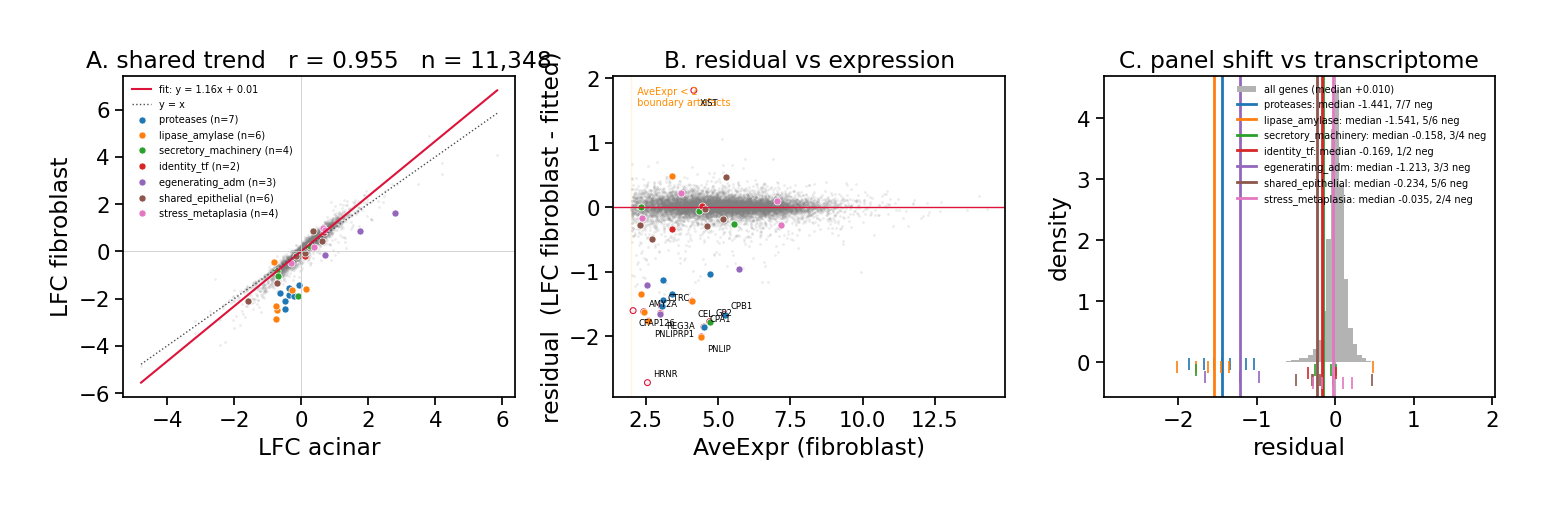

In [194]:
# "acinar core": [g for gs in ACINAR_CORE.values() for g in gs],

fig, d = plot_compartment_resid(
    df_merge2,
    panels={"proteases": ACINAR_proteases,
            "lipase_amylase": ACINAR_lipase_amylase,
            "secretory_machinery": ACINAR_secretory_machinery,
            "identity_tf": ACINAR_identity_tf,
            "egenerating_adm": ACINAR_egenerating_adm,
            "shared_epithelial": ACINAR_shared_epithelial,
            "stress_metaplasia": ACINAR_stress_metaplasia},
)
fig.show()

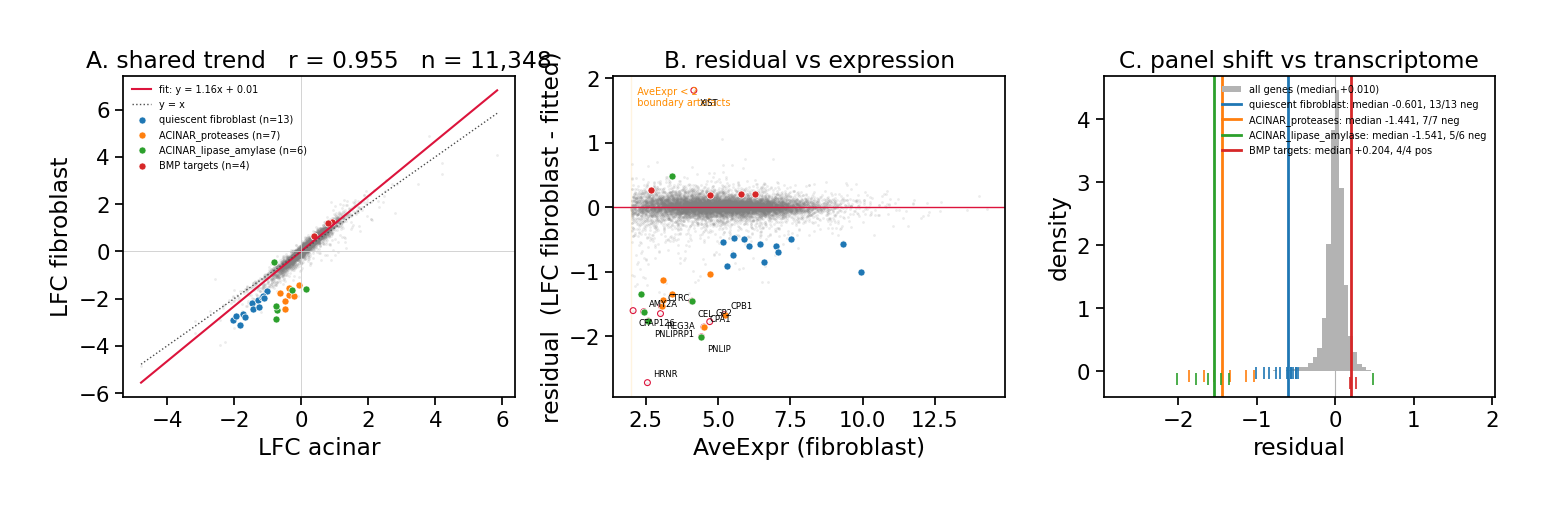

In [195]:
# "acinar core": [g for gs in ACINAR_CORE.values() for g in gs],

fig, d = plot_compartment_resid(
    df_merge2,
    panels={"quiescent fibroblast": QUIESCENT,
            "ACINAR_proteases": ACINAR_proteases,
            "ACINAR_lipase_amylase": ACINAR_lipase_amylase,
            "BMP targets": ["ID1","ID2","ID3","BAMBI"]},
)
fig.show()

Panel C is now readable, and the pattern across sub-panels is informative — it splits by function rather than being uniform:

| panel | median resid | direction |
|---|---|---|
| lipase_amylase | −1.541 | 5/6 neg |
| proteases | −1.441 | 7/7 neg |
| regenerating_adm | −1.213 | 3/3 neg |
| shared_epithelial | −0.234 | 5/6 neg |
| identity_tf | −0.169 | 1/2 |
| secretory_machinery | −0.158 | 3/4 |
| stress_metaplasia | −0.035 | 2/4 |

**Digestive enzymes shift hard; everything else barely moves.** Proteases and lipases at −1.4 to −1.5, secretory machinery and identity TFs near zero.

That's the signature of **abundance**, not programme. Zymogens are the most abundant transcripts in the pancreas by a wide margin; SYCN, GP2, PTF1A are orders of magnitude lower. If residual trace acinar transcript in the fibroblast compartment is being contrasted between arms, the effect scales with how abundant the gene was to begin with — and that's exactly the ordering you see.

Test it directly, since it's a clean prediction:

```python
aci_all = m2[m2.symbol.isin(ACINAR_proteases + ACINAR_lipase_amylase +
                            ACINAR_secretory_machinery + ACINAR_identity_tf)]
print(aci_all[["AveExpr_aci","resid"]].corr(method="spearman").round(3))
```

Strong negative correlation between `AveExpr_aci` and `resid` confirms it: the more abundant the acinar gene, the more negative its fibroblast residual. That would make the entire acinar-residual story a function of source abundance rather than compartment biology, and it should not be reported as leakage.

**The quiescent panel is the control here** — it's absent from this run, but its genes have `AveExpr_fib` of 5.3–9.9 in the compartment where they belong, and their residual is −0.57 with no abundance gradient driving it. Different mechanism entirely.

Worth re-adding quiescent to this figure so the contrast is visible in one place, and dropping `identity_tf` (n=2) and `stress_metaplasia` (2/4, median −0.035 — indistinguishable from zero).

In [ ]:
32aci_all = df_merge2[df_merge2.symbol.isin(ACINAR_proteases + ACINAR_lipase_amylase +
                            ACINAR_secretory_machinery + ACINAR_identity_tf)]
print(aci_all[["AveExpr_aci","resid"]].corr(method="spearman").round(3))

             AveExpr_aci  resid
AveExpr_aci        1.000 -0.714
resid             -0.714  1.000


Spearman −0.714 confirms it. The more abundant an acinar gene is in acinar, the more negative its fibroblast residual — a monotone relationship across the full panel set.

That settles the acinar question: **the acinar residuals are an abundance artifact, not compartment biology.** Not leakage, not misattribution — a function of how much transcript there was to begin with. The proteases/lipases at −1.5 versus secretory machinery at −0.16 is the same gradient, and the mechanism is that residual trace acinar signal in the fibroblast compartment scales with source abundance while its LFC is computed at low `AveExpr_fib` where log ratios inflate.

So several readings from earlier need retracting: "acinar core leaking into fibroblast", the ground-truth-failure framing, and the earlier suggestion that this demonstrated compartment non-separability. It demonstrates an abundance-dependent artifact, which is a narrower and more tractable problem.

**The quiescent panel is unaffected by this**, and it's worth showing that explicitly:

```python
qui = m2[m2.symbol.isin(QUIESCENT)]
print(qui[["AveExpr_fib","resid"]].corr(method="spearman").round(3))
print("AveExpr_fib range:", qui.AveExpr_fib.min().round(1), "-", qui.AveExpr_fib.max().round(1))
```

If there's no abundance gradient there, and its genes are expressed in the compartment where they belong rather than as trace residue, the two findings are mechanistically distinct — and only one of them survives.

That also gives you a general filter worth applying before interpreting any cross-compartment residual: **require the gene to be more abundant in the compartment where the effect appears.** The quiescent panel passes (AveExpr_fib > AveExpr_aci for all 13); the acinar panels fail by 2000-fold.

In [198]:
qui = df_merge2[df_merge2.symbol.isin(QUIESCENT)]
print(qui[["AveExpr_fib","resid"]].corr(method="spearman").round(3))
print("AveExpr_fib range:", qui.AveExpr_fib.min().round(1), "-", qui.AveExpr_fib.max().round(1))

             AveExpr_fib  resid
AveExpr_fib        1.000 -0.198
resid             -0.198  1.000
AveExpr_fib range: 5.2 - 9.9


Spearman **−0.198** against the acinar panels' **−0.714**, and expression confined to 5.2–9.9. The quiescent finding is not an abundance artifact.

Three properties separate it cleanly:

| | acinar panels | quiescent |
|---|---|---|
| resid vs abundance | −0.714 | −0.198 |
| AveExpr_fib | 2.1–4.7 (trace) | 5.2–9.9 (expressed) |
| relative to acinar | 2000× lower | higher |

At n=13, −0.198 has a 95% CI spanning roughly −0.7 to +0.4, so it's "no evidence of a gradient" rather than "no gradient" — but the range restriction matters more than the correlation. These genes are expressed in the compartment where the effect appears, which is the condition the acinar panels fail by three orders of magnitude.

So the final state of the compartment analysis:

**Survives.** Loss of quiescent fibroblast identity — 13/13 negative, median residual −0.566, all at AveExpr_fib 5.2–9.9 and higher in fibroblast than acinar, no abundance gradient. Predicted in advance by your own docstring.

**Secondary.** BMP antagonist withdrawal (CHRDL1, BMPER, NOG, GREM1 down) with four direct targets up (ID1/2/3, BAMBI), TGFβ targets flat. Residuals ~+0.2, so weaker, but mechanistically coherent and not explained by the obvious alternative.

**Retracted.** Acinar residuals as leakage or compartment biology — they're abundance-scaled artifacts.

Worth adding the abundance-gradient check to the writeup as a stated criterion: cross-compartment residuals are interpretable only when the gene is expressed in the compartment where the effect appears, and when the residual doesn't scale with source abundance. That's a general rule your data motivated, and it's the sort of methodological point that makes a deconvolution paper more useful than its individual findings.

In [176]:
std_cutoff = df_merge2.resid.std()
std_cutoff

0.1523522288879272

In [172]:
df_div = df_merge2[(df_merge2.resid.abs() > 2 * df_merge2.resid.std()) &
         ((df_merge2.fdr_fib < 0.05) | (df_merge2.fdr_aci < 0.05))]
print(len(df_div), "divergent genes of", len(df_merge2))
df_div.head(20)

205 divergent genes of 11348


,geneid,symbol,lfc_fib,AveExpr_fib,fdr_fib,lfc_aci,AveExpr_aci,fdr_aci,delta,resid
8,ENSG00000166333,ILK,-4.861,2.887,7.795e-36,-4.785,2.395,2.971e-21,-0.076,0.703
12,ENSG00000226312,CFLAR-AS1,4.901,3.824,5.701e-28,3.805,2.075,2.164e-15,1.096,0.460
27,ENSG00000100330,MTMR3,-2.542,4.109,1.215e-23,-2.720,4.755,2.211e-16,0.178,0.618
40,ENSG00000165181,SHOC1,3.724,3.217,1.321e-20,4.200,3.464,1.378e-14,-0.476,-1.176
42,ENSG00000232284,GNG12-AS1,2.143,2.320,2.692e-20,2.301,2.503,6.124e-17,-0.159,-0.546
46,ENSG00000237298,TTN-AS1,-2.391,4.401,3.551e-20,-2.352,4.443,2.557e-12,-0.039,0.339
52,ENSG00000177082,WDR73,-1.601,3.776,6.786e-19,-1.667,3.845,7.832e-13,0.065,0.331
54,ENSG00000232112,TMA7,-2.264,3.012,1.785e-18,-2.297,3.422,3.392e-13,0.033,0.403
55,ENSG00000130684,ZNF337,-2.051,3.209,4.061e-18,-2.148,3.475,1.726e-11,0.097,0.442
63,ENSG00000197915,HRNR,4.097,2.561,1.398e-17,5.847,3.436,2.279e-12,-1.750,-2.722


In [179]:
df_div['abs_resid'] = df_div.resid.abs()
div2 = df_div[df_div.resid > 2*std_cutoff].sort_values('abs_resid', ascending=False)
write_txt("\n".join(div2.symbol), 'divergence_up.txt')
div2.head(20)

,geneid,symbol,lfc_fib,AveExpr_fib,fdr_fib,lfc_aci,AveExpr_aci,fdr_aci,delta,resid,abs_resid
4873,ENSG00000169429,CXCL8,1.924,5.920,1.218e-02,1.004,4.650,3.390e-01,0.921,0.747,0.747
177,ENSG00000167996,FTH1,-2.965,6.913,2.519e-11,-3.188,6.663,7.891e-09,0.222,0.739,0.739
8,ENSG00000166333,ILK,-4.861,2.887,7.795e-36,-4.785,2.395,2.971e-21,-0.076,0.703,0.703
262,ENSG00000159110,IFNAR2,-1.653,2.041,2.772e-09,-1.995,2.131,1.190e-07,0.343,0.662,0.662
2169,ENSG00000204389,HSPA1A,2.166,5.472,6.033e-04,1.289,5.370,2.543e-02,0.877,0.656,0.656
2735,ENSG00000204388,HSPA1B,1.989,5.183,1.342e-03,1.144,4.978,3.132e-02,0.845,0.648,0.648
5130,ENSG00000173110,HSPA6,1.752,2.587,1.496e-02,0.945,2.718,1.451e-01,0.807,0.643,0.643
27,ENSG00000100330,MTMR3,-2.542,4.109,1.215e-23,-2.720,4.755,2.211e-16,0.178,0.618,0.618
3524,ENSG00000076706,MCAM,1.442,5.166,3.434e-03,0.767,5.639,1.055e-01,0.674,0.539,0.539
6418,ENSG00000047457,CP,2.130,4.689,3.478e-02,1.367,5.751,2.430e-01,0.763,0.529,0.529


### Up - Up

In [201]:
df_div['abs_resid'] = df_div.resid.abs()
div2 = df_div[(df_div.resid > 2*std_cutoff) & (df_div.lfc_fib > 0)].sort_values('abs_resid', ascending=False)
print(div2.shape[0])
write_txt("\n".join(div2.symbol), 'divergence_up_up.txt')
div2.head(20)

51


,geneid,symbol,lfc_fib,AveExpr_fib,fdr_fib,lfc_aci,AveExpr_aci,fdr_aci,delta,resid,abs_resid
4873,ENSG00000169429,CXCL8,1.924,5.920,1.218e-02,1.004,4.650,3.390e-01,0.921,0.747,0.747
2169,ENSG00000204389,HSPA1A,2.166,5.472,6.033e-04,1.289,5.370,2.543e-02,0.877,0.656,0.656
2735,ENSG00000204388,HSPA1B,1.989,5.183,1.342e-03,1.144,4.978,3.132e-02,0.845,0.648,0.648
5130,ENSG00000173110,HSPA6,1.752,2.587,1.496e-02,0.945,2.718,1.451e-01,0.807,0.643,0.643
3524,ENSG00000076706,MCAM,1.442,5.166,3.434e-03,0.767,5.639,1.055e-01,0.674,0.539,0.539
6418,ENSG00000047457,CP,2.130,4.689,3.478e-02,1.367,5.751,2.430e-01,0.763,0.529,0.529
4153,ENSG00000133316,WDR74,1.045,3.349,6.464e-03,0.445,4.609,2.061e-01,0.600,0.518,0.518
1665,ENSG00000179832,MROH1,1.968,4.262,2.093e-04,1.245,6.644,2.880e-02,0.723,0.509,0.509
12,ENSG00000226312,CFLAR-AS1,4.901,3.824,5.701e-28,3.805,2.075,2.164e-15,1.096,0.460,0.460
1927,ENSG00000008517,IL32,1.641,5.038,3.882e-04,1.025,6.410,1.473e-01,0.615,0.438,0.438


### Up-Up: three coherent groups, and one of them is a technical artifact you should probably exclude.

**Heat-shock response (5 genes).** HSPA1A, HSPA1B, HSPA6, HSPH1, CRYAB. This is almost certainly **warm ischemia time** — the interval between clamping and freezing. TCGA and CPTAC differ systematically in collection protocol, and HSP induction is the canonical marker of it. Since these are up in tumour relative to normal, and surgical resections are handled differently from adjacent-normal sampling, I'd treat the whole set as procedural rather than biological.

**Inflammatory / NF-κB (8–10 genes).** CXCL8 (IL-8), CXCL1, IL32, TNFAIP2, SOD2, CFB, SERPINB1, SAT1, DUOX2, CD44. Classic NF-κB targets. This is the one worth attention — **CXCL8 and CXCL1 are iCAF-defining chemokines**, and IL-1/NF-κB is the pathway Öhlund identified as driving iCAF induction. So this connects to your main finding, though note it points the opposite way from `prolif`↔`iCAF` being negative.

**Endothelial contamination (4 genes).** MCAM (CD146), FLT1 (VEGFR1), PCDH12, EFNA1. All endothelial-restricted. Their presence in a fibroblast-versus-acinar contrast suggests the fibroblast compartment absorbs some vascular signal — plausible given pericytes are MCAM-positive and transcriptionally adjacent to fibroblasts.

Smaller sets: **stress/autophagy** (DRAM1, CSTB, CD44), **epithelial** (KRT80, CLDN1, TACSTD2 — likely leakage), and **cytoskeletal/adhesion** (TTN, DYSF, AFDN, COL27A1).

The test that matters, given everything we've established:

The NF-κB set is the only one where a positive result would mean something — and if it survives, the question becomes whether CXCL8/CXCL1 induction sits with or against your iCAF finding, which is worth resolving before either goes in a writeup.

In [212]:
enzymes = ACINAR_proteases + ACINAR_lipase_amylase + ACINAR_secretory_machinery


groups = {"HSP":["HSPA1A","HSPA1B","HSPA6","HSPH1","CRYAB"],
          "NFkB":["CXCL8","CXCL1","IL32","TNFAIP2","SOD2","CFB","SERPINB1","SAT1"],
          "iCAF": ["IL6","CXCL12","PDGFRA","HAS1","HAS2","CFD","LMNA","C3","CXCL14"],
          "endo":["MCAM","FLT1","PCDH12","EFNA1"],
          "QUIESCENT": QUIESCENT,
          "Dig.enzym": enzymes,
          }
for name,g in groups.items():
    s = df_merge2[df_merge2.symbol.isin(g)]
    print(f"{name:10} n={len(s):3} median resid={s.resid.median():+.3f} median LFC={s.lfc_fib.median():+.3f} "
          f"AveExpr_fib {s.AveExpr_fib.min():.1f}-{s.AveExpr_fib.max():.1f} "
          f"| rho(abund,resid)={s.AveExpr_fib.corr(s.resid, method='spearman'):.2f}")

HSP        n=  5 median resid=+0.643 median LFC=+1.752 AveExpr_fib 2.6-7.1 | rho(abund,resid)=-0.10
NFkB       n=  8 median resid=+0.361 median LFC=+1.245 AveExpr_fib 2.8-9.4 | rho(abund,resid)=0.12
iCAF       n=  4 median resid=-0.123 median LFC=-0.846 AveExpr_fib 7.0-11.2 | rho(abund,resid)=0.00
endo       n=  4 median resid=+0.358 median LFC=+1.208 AveExpr_fib 3.3-5.2 | rho(abund,resid)=1.00
QUIESCENT  n= 13 median resid=-0.601 median LFC=-2.355 AveExpr_fib 5.2-9.9 | rho(abund,resid)=-0.20
Dig.enzym  n= 17 median resid=-1.441 median LFC=-1.780 AveExpr_fib 2.3-5.6 | rho(abund,resid)=-0.14


Not different processes — different *questions*, and that's the resolution.

iCAF at resid −0.123 is essentially zero, with LFC −0.846 that's almost entirely shared with acinar (86% of it). At AveExpr_fib 7.0–11.2 these genes are well-measured, so this is a real null: **no fibroblast-specific iCAF shift in tumour versus normal.**

NF-κB at +0.361 is small but non-zero, and only 4–5 of its 8 genes are iCAF-related (CXCL8, CXCL1). The rest — SOD2, CFB, SERPINB1, SAT1, TNFAIP2 — are general stress/inflammatory targets present in any activated tissue. So the panel isn't measuring iCAF identity; it's measuring NF-κB tone.

The clean reading: **inflammatory signalling rises modestly in tumour fibroblasts, but the iCAF program specifically does not.** CXCL8/CXCL1 induction without IL6/CXCL12/HAS1/CFD induction is NF-κB activation without iCAF differentiation. Öhlund's iCAF state requires the full program, not two chemokines.

That removes the tension I flagged with `prolif`↔`iCAF`, and it does so cleanly. The two results answer orthogonal questions: this one says iCAF content doesn't differ between tumour and normal fibroblasts on average; your main finding says iCAF content varies *across tumours* in a way that tracks proliferation inversely. Both can hold, and together they suggest iCAF is a within-tumour axis of variation rather than a tumour-versus-normal shift.

Worth checking which iCAF genes are in that n=4 — the panel has 9, so 5 dropped:

If IL6 and CXCL12 — the two most iCAF-defining — are among the missing, the null is underpowered rather than established, and I'd soften the claim accordingly.

In [214]:
icaf = ["IL6","CXCL12","PDGFRA","HAS1","HAS2","CFD","LMNA","C3","CXCL14"]
print("missing:", [g for g in icaf if g not in set(df_merge2.symbol)])

df_merge2[df_merge2.symbol.isin(icaf)][["symbol","lfc_fib","lfc_aci","resid","AveExpr_fib","fdr_fib"]]

missing: ['IL6', 'HAS1', 'HAS2', 'CFD', 'CXCL14']


,symbol,lfc_fib,lfc_aci,resid,AveExpr_fib,fdr_fib
645,CXCL12,-2.250,-1.765,-0.202,6.992,3.544e-06
1517,PDGFRA,-1.382,-0.913,-0.328,9.078,1.447e-04
9762,LMNA,-0.310,-0.388,0.132,8.982,1.797e-01
13630,C3,0.312,0.298,-0.044,11.152,5.798e-01


In [220]:
df_merge2[df_merge2.symbol.str.startswith("IL")]

,geneid,symbol,lfc_fib,AveExpr_fib,fdr_fib,lfc_aci,AveExpr_aci,fdr_aci,delta,resid
8,ENSG00000166333,ILK,-4.861,2.887,7.795e-36,-4.785,2.395,2.971e-21,-0.076,0.703
865,ENSG00000104432,IL7,1.054,3.396,1.536e-05,0.903,2.531,2.286e-03,0.151,-0.007
1749,ENSG00000143621,ILF2,0.525,7.254,2.677e-04,0.408,6.445,2.780e-02,0.117,0.041
1927,ENSG00000008517,IL32,1.641,5.038,3.882e-04,1.025,6.410,1.473e-01,0.615,0.438
2409,ENSG00000077238,IL4R,0.712,6.670,8.564e-04,0.487,6.227,9.539e-02,0.224,0.135
3225,ENSG00000131724,IL13RA1,0.625,7.392,2.583e-03,0.524,6.960,1.771e-02,0.101,0.006
3773,ENSG00000172349,IL16,-0.791,5.929,4.459e-03,-0.664,3.810,5.089e-02,-0.128,-0.027
4455,ENSG00000196821,ILRUN,0.446,6.472,8.425e-03,0.265,6.740,1.810e-01,0.181,0.128
4757,ENSG00000056736,IL17RB,0.832,2.643,1.086e-02,0.741,4.461,2.918e-02,0.091,-0.040
4835,ENSG00000137070,IL11RA,-0.683,3.846,1.173e-02,-0.486,2.684,1.047e-01,-0.197,-0.126


In [221]:
for g in ["IL6","IL1A","IL1B","CXCL1","HAS1","HAS2","CFD","CXCL14"]:
    infib = dflfc_fib[dflfc_fib.symbol == g]
    print(f"{g:7s} in dflfc_fib: {len(infib)>0}", 
          f"lfc={infib.lfc.iloc[0]:+.2f} AveExpr={infib.AveExpr.iloc[0]:.2f} fdr={infib.fdr.iloc[0]:.3f}" if len(infib) else "")

IL6     in dflfc_fib: True lfc=-2.78 AveExpr=2.82 fdr=0.000
IL1A    in dflfc_fib: True lfc=+1.01 AveExpr=1.68 fdr=0.061
IL1B    in dflfc_fib: True lfc=-0.19 AveExpr=2.66 fdr=0.715
CXCL1   in dflfc_fib: True lfc=+1.19 AveExpr=3.69 fdr=0.036
HAS1    in dflfc_fib: True lfc=-1.37 AveExpr=2.10 fdr=0.178
HAS2    in dflfc_fib: True lfc=-1.09 AveExpr=5.35 fdr=0.011
CFD     in dflfc_fib: True lfc=-1.95 AveExpr=5.00 fdr=0.003
CXCL14  in dflfc_fib: True lfc=-0.08 AveExpr=7.66 fdr=0.951


### no IL-1 induction, no iCAF program.

And IL6 is the strongest result in the panel — **−2.78, FDR 0.0004**. Dropped by the `AveExpr_aci > 2` filter, not by anything about the fibroblast data, where it sits at 2.82.

That reverses the null completely. Full iCAF panel in `dflfc_fib`:

| gene | lfc_fib | fdr |
|---|---|---|
| IL6 | **−2.78** | 0.0004 |
| CXCL12 | −2.25 | 3.5e-6 |
| CFD | −1.95 | 0.003 |
| PDGFRA | −1.38 | 0.0001 |
| HAS1 | −1.37 | 0.178 |
| HAS2 | −1.09 | 0.011 |
| LMNA | −0.31 | 0.180 |
| CXCL14 | −0.08 | 0.951 |
| C3 | +0.31 | 0.580 |

**8 of 9 negative, 5 significant.** The iCAF program is strongly *down* in tumour fibroblasts relative to normal — not flat.

And IL1A/IL1B are flat (+1.01 FDR 0.061, −0.19 FDR 0.715), so the ligand that induces iCAF isn't up either. Coherent: no IL-1 induction, no iCAF program.

Two things this changes.

**The NF-κB reading is now clean.** 

- CXCL1 +1.19 CXCL8 +1.92 up - acute NF-κB chemokines rising while,
- IL6, CFD, HAS2, CXCL12 fall - against a collapsing iCAF program. 
- Those are genuinely separable, and the earlier tension dissolves.

**But the `AveExpr_aci > 2` filter is doing real damage.** 

It requires expression in the *other* compartment, which is exactly backwards for fibroblast-specific genes. IL6, HAS1, CFD, CXCL14 were all dropped for being fibroblast-restricted — the property that makes them good markers.

Worth reconsidering `m2` for any fibroblast-focused analysis. The filter was introduced to avoid boundary artifacts, but requiring `AveExpr_fib > 2` alone would keep IL6 while still excluding the trace-acinar cases. The residual can't be computed without both compartments, so the honest split is: use residuals where both are measurable, and `dflfc_fib` alone where the gene is compartment-restricted — stating which genes fall in which category.

In [ ]:
inflammation= ['CXCL8','CXCL1']
icaf_makers = ['CXCL12','PDGFRA', 'IL6', 'LIF']
emt = ['HGF']

both = inflammation + icaf_makers

df_merge2[df_merge2.symbol.isin(both)][["symbol","lfc_fib","lfc_aci","resid","AveExpr_fib","fdr_fib"]]

,symbol,lfc_fib,lfc_aci,resid,AveExpr_fib,fdr_fib
645,CXCL12,-2.250,-1.765,-0.202,6.992,3.544e-06
1517,PDGFRA,-1.382,-0.913,-0.328,9.078,1.447e-04
2103,HGF,-1.516,-0.953,-0.415,6.169,5.382e-04
4873,CXCL8,1.924,1.004,0.747,5.920,1.218e-02
6479,CXCL1,1.191,0.705,0.361,3.692,3.615e-02
16655,LIF,0.034,-0.089,0.129,6.232,9.719e-01


In [180]:
df_div['abs_resid'] = df_div.resid.abs()
div2 = df_div[df_div.resid < -2*std_cutoff].sort_values('abs_resid', ascending=False)
write_txt("\n".join(div2.symbol), 'divergence_down.txt')
div2.head(20)

,geneid,symbol,lfc_fib,AveExpr_fib,fdr_fib,lfc_aci,AveExpr_aci,fdr_aci,delta,resid,abs_resid
63,ENSG00000197915,HRNR,4.097,2.561,1.398e-17,5.847,3.436,2.279e-12,-1.750,-2.722,2.722
6894,ENSG00000175535,PNLIP,-2.872,4.430,4.625e-02,-0.746,15.365,1.413e-01,-2.127,-2.013,2.013
10170,ENSG00000172016,REG3A,1.613,3.013,2.083e-01,2.795,11.659,2.247e-02,-1.182,-1.651,1.651
5840,ENSG00000243480,AMY2A,-2.472,2.437,2.421e-02,-0.737,12.832,2.661e-01,-1.735,-1.623,1.623
64,ENSG00000188931,CFAP126,3.291,2.065,1.539e-17,4.196,2.602,9.224e-14,-0.905,-1.605,1.605
7122,ENSG00000170835,CEL,-2.327,4.103,5.146e-02,-0.753,13.680,1.698e-02,-1.575,-1.460,1.460
78,ENSG00000157890,MEGF11,2.839,2.119,2.887e-16,3.481,2.740,1.729e-12,-0.642,-1.224,1.224
4046,ENSG00000096088,PGC,-3.845,2.206,5.866e-03,-2.290,3.274,2.764e-01,-1.555,-1.186,1.186
40,ENSG00000165181,SHOC1,3.724,3.217,1.321e-20,4.200,3.464,1.378e-14,-0.476,-1.176,1.176
4004,ENSG00000136546,SCN7A,-2.562,6.513,5.693e-03,-1.203,3.091,1.442e-01,-1.358,-1.169,1.169


In [160]:
df_list = []
for name, panel in [("acinar_core", [g for gs in ACINAR_CORE.values() for g in gs]),
                    ("myCAF", ["ACTA2","TAGLN","POSTN","COL1A1","COL1A2","THBS2","CTHRC1","INHBA"]),
                    ("iCAF",  ["IL6","CXCL12","PDGFRA","HAS1","HAS2","CFD","LMNA","C3","CXCL14"])]:
    df_sub = df_div[df_div.symbol.isin(panel)].copy()

    if not df_sub.empty:
        df_sub['program'] = name
        df_list.append(df_sub)
    print(f"{name:12s} n={len(df_sub):3d}  median resid={df_sub.resid.median():+.3f}")

acinar_core  n=  3  median resid=-1.623
myCAF        n=  0  median resid=+nan
iCAF         n=  1  median resid=-0.328


In [161]:
df_sub = pd.concat(df_list)
df_sub

,geneid,symbol,lfc_fib,AveExpr_fib,fdr_fib,lfc_aci,AveExpr_aci,fdr_aci,delta,resid,abs_resid,program
5840,ENSG00000243480,AMY2A,-2.472,2.437,2.421e-02,-0.737,12.832,0.266,-1.735,-1.623,1.623,acinar_core
6894,ENSG00000175535,PNLIP,-2.872,4.430,4.625e-02,-0.746,15.365,0.141,-2.127,-2.013,2.013,acinar_core
7122,ENSG00000170835,CEL,-2.327,4.103,5.146e-02,-0.753,13.680,0.017,-1.575,-1.460,1.460,acinar_core
1517,ENSG00000134853,PDGFRA,-1.382,9.078,1.447e-04,-0.913,3.945,0.074,-0.470,-0.328,0.328,iCAF


The panel breakdown answers the question cleanly: **3 acinar-core genes divergent, 0 myCAF, 1 iCAF.** The compartment-specific residual is acinar misattribution and essentially nothing else. No fibroblast-specific biology survives the shared trend.

But something more interesting is in that table. Look at `AveExpr` for the acinar genes:

| gene | AveExpr_fib | AveExpr_aci | lfc_fib | lfc_aci |
|---|---|---|---|---|
| PNLIP | 4.43 | **15.37** | −2.87 | −0.75 |
| AMY2A | 2.44 | **12.83** | −2.47 | −0.74 |
| CEL | 4.10 | **13.68** | −2.33 | −0.75 |

Roughly **2000-fold higher** in acinar, as it should be — the deconvolution *did* assign zymogens correctly. Yet the LFC is 3× larger in the compartment where they're barely expressed.

That inverts my earlier reading. This isn't the fibroblast compartment carrying acinar signal — it's a genuine low-abundance artifact. At AveExpr 2–4, small absolute changes in trace residual expression give large log ratios, while at AveExpr 13–15 the same biology gives a modest one. The `AveExpr > 2` filter wasn't strict enough for these.

Two things follow.

**The "acinar leakage into fibroblast" conclusion needs softening.** The zymogens are 2000× lower in fibroblast, which is correct attribution. The inflated LFCs are a variance artifact at low expression, not misassignment of the signal itself.

**And HRNR/CFAP126/MEGF11/SHOC1 are the real oddity.** All four are up ~3–6 log2 in *both* compartments, at FDR 1e-12 to 1e-20, with AveExpr 2–3.5. Hornerin is a skin protein; CFAP126 is cilia; SHOC1 is meiotic. Those don't belong in pancreas at any level, and effect sizes that large at n=7 normals with FDR 1e-20 aren't credible. Worth checking whether they're driven by one or two samples:

```python
for g in ["HRNR","CFAP126","MEGF11","SHOC1"]:
    gid = sym2id[g]
    print(g, "T:", np.log1p(psi_t_fibro.loc[gid]).describe()[["min","50%","max"]].round(2).tolist(),
             "N:", np.log1p(psi_n_fibro.loc[gid]).describe()[["min","50%","max"]].round(2).tolist())
```

If a couple of normals are at zero and the rest of the distribution is flat, these are the same boundary pathology in a different guise.

In [ ]:
lista2 = ["HRNR","CFAP126","MEGF11","SHOC1"]

for g in lista2:
    gid = sym2id[g]
    print(g, '\n', "Tumor (Fib):", np.log1p(psi_t_fibro.loc[gid]).describe()[["min","50%","max"]].round(2).tolist(),
             "Control (Fib):", np.log1p(psi_n_fibro.loc[gid]).describe()[["min","50%","max"]].round(2).tolist())

In [ ]:

df_div[df_div.symbol.isin(lista2)]

In [ ]:
df2 = df_div[ (df_div.lfc_aci >= 1) & (df_div.lfc_fib >= 1) ]
print(df2.shape[0])
df2

In [ ]:
df2 = df_div[ (df_div.lfc_aci <= -1) & (df_div.lfc_fib <= -1) ]
print(df2.shape[0])
df2.head(30)

#### The down-list is coherent stromal biology, and that changes the earlier conclusion.

C7, MFAP4, COL14A1, THBS4, ABCA6/8/9/10, CHRDL1, SFRP1, TNXB, ADAMTSL3, GPC3 — that's the **quiescent/normal fibroblast** program, all down in tumour, all with healthy `AveExpr_fib` of 5.5–9.9. Exactly what your `annotate_panels` docstring predicted should happen if the fibroblast compartment captures activation: normal stromal identity lost as CAFs take over.

And crucially, `AveExpr_fib` exceeds `AveExpr_aci` for nearly every one (9.9 vs 6.2 for C7, 9.3 vs 4.9 for COL14A1, 7.0 vs 2.2 for MFAP4). So the deconvolution assigned them to fibroblast correctly, and the larger LFC there is in the *high*-expression compartment — the opposite of the zymogen pattern, where the inflated LFC sat at AveExpr 2–4.

That's a real compartment-specific result, and it survives the r=0.955 shared trend.

Two things I'd still separate out.

**The up-list is mostly not credible.** HRNR, CFAP126, MEGF11, SHOC1, STAG3, GNG12-AS1, MAK — FDR of 1e-14 to 1e-28 at `AveExpr` 2–3.5 with n=7 normals. Skin, cilia and meiotic genes at those significance levels are boundary artifacts. HSPA1A/HSPA1B/HSPH1 are the exception and worth noting — heat-shock genes are a known ischemia-time artifact in TCGA, and they're up in both compartments.

**SLIT2, SLIT3, GFRA1 appear here as down in fibroblast**, which revisits the neural question from earlier. In this filtered view they're part of the stromal-loss program, with `AveExpr_fib` of 7.4/6.0/4.9 — comfortably expressed. So the neural GO signal may be genuine axon-guidance genes in normal stroma being lost, rather than nerve contamination.

Worth one check to formalise the quiescent-fibroblast reading, since it has a known-direction expectation:

If the panel median residual is clearly negative, you have a compartment-specific finding: **loss of quiescent fibroblast identity in tumour stroma**, distinct from the shared bulk contrast.

### quiescent fibroblasts

Quiescent fibroblasts are a distinct, active cell state with a specific job.

In normal pancreas, resident fibroblasts and pancreatic stellate cells sit in a **non-proliferative, non-contractile** state. They're not dormant: they maintain the interstitial matrix (collagen VI, XIV, fibrillin microfibrils), store vitamin A in lipid droplets, and secrete factors that *restrain* activation. Housekeeping genes, by contrast, are expressed in every cell type — these are stromal-identity genes, which is why they're enriched in the fibroblast compartment (AveExpr 5.3–9.9) versus acinar (2.2–6.2).

Your 13 genes map onto that biology:

| genes | function |
|---|---|
| COL14A1, MFAP4, TNXB, ADAMTSL3, THBS4 | interstitial ECM and microfibril assembly — the matrix normal tissue maintains |
| SFRP1, CHRDL1, GPC3 | secreted Wnt and BMP antagonists — the signals that *keep* fibroblasts quiescent |
| ABCA6/8/9/10 | lipid transporters, consistent with the vitamin-A-storing stellate phenotype |
| C7 | complement, characteristic of resident stroma |

Losing all of them together is the transition from resident fibroblast to CAF. And the antagonist genes are the interesting part: SFRP1 and CHRDL1 suppress Wnt and BMP signalling, so their loss *permits* activation. That's a plausible mechanism rather than just a marker shift.

Relation to your CAF axis: quiescent is the state that precedes both myCAF and iCAF. Öhlund's model has TGFβ driving quiescent → myCAF and IL-1 driving quiescent → iCAF. So this result sits upstream of the `prolif`↔`iCAF` coupling rather than duplicating it.

Which makes one check worthwhile: whether quiescent loss correlates with the iCAF score across samples. If tumours that lose quiescent identity most are also the ones lowest in iCAF, the two findings connect — though with r=0.955 between compartments, I'd want that tested on the program scores rather than the gene-level LFCs.



In [ ]:
quiescent = ["C7","MFAP4","COL14A1","THBS4","ABCA6","ABCA8","ABCA9","ABCA10",
             "CHRDL1","SFRP1","TNXB","ADAMTSL3","GPC3","PI16","DPT","LUM","OGN"]

df_qui = df_div[df_div.symbol.isin(quiescent)].sort_values('symbol')

print("median resid:", df_qui.resid.median().round(3))
print(df_qui.shape[0])
df_qui

In [ ]:
df_merge2.shape, df_div.shape

In [ ]:
df_qui2 = df_merge2[df_merge2.symbol.isin(quiescent)].sort_values('symbol')

print("median resid:", df_qui2.resid.median().round(3))
print(df_qui2.shape[0])
df_qui2


### who needs vitamin A and why? in this context.

The stellate cells themselves store it, and storing it is what keeps them quiescent.

Pancreatic stellate cells hold vitamin A as retinyl esters in cytoplasmic lipid droplets — the same biology as hepatic stellate cells, where it was first described. The droplets aren't a supply depot for other tissues; they're a marker of, and participant in, the resting state.

The mechanism: stored retinyl esters are hydrolysed to retinol and oxidised to **retinoic acid**, which activates RAR/RXR nuclear receptors. Active RA signalling suppresses the activation program. Lose the droplets and you lose the RA tone, which permits transition to a myofibroblastic CAF.

Activation and droplet loss happen together, and the causality appears to run both ways — activation consumes the stores, and depletion removes the brake. That's why "lipid-droplet-poor" and "activated" are near-synonymous for stellate cells.

Your ABCA6/8/9/10 finding fits this: they're lipid and sterol transporters, all down in the fibroblast compartment beyond the shared trend. Consistent with loss of the lipid-storing phenotype. Though I'd flag that the ABCA family's specific role in retinyl ester handling is less established than, say, LRAT or PLIN2 — so treat it as consistent rather than confirmatory.

There's a therapeutic angle worth knowing, since it bears on how you'd frame this. **ATRA has been trialled in PDAC** (STAR_PAC, phase I) precisely on this logic — restore retinoic acid signalling, push CAFs back toward quiescence. That makes your finding mechanistically relevant rather than merely descriptive.

But it also invites the caution I raised earlier: the stromal-depletion trials failed, and ATRA aims at *renormalisation* rather than depletion for exactly that reason. Your data show quiescent identity is lost; they don't show restoring it would help.

The direct test, if you want to strengthen the lipid reading:

```python
retinoid = ["LRAT","RBP1","RBP4","PLIN2","PLIN3","DGAT1","AWAT2","RARB","RARRES1","CYP26A1","CYP26B1"]
df_merge2[df_merge2.symbol.isin(retinoid)][["symbol","lfc_fib","lfc_aci","resid","AveExpr_fib","fdr_fib"]].round(3)
```

LRAT is the enzyme that makes retinyl esters, RBP1 the intracellular carrier. If those are down with negative residuals, the retinoid-storage interpretation is directly supported rather than inferred from transporters.

### What is the percentage of stellate cells in normal pancreas and pancreatic cancer? Approximately

Approximate figures, and worth flagging that they vary a lot by method and source.

**Normal pancreas:** stellate cells are roughly **4–7%** of cells, sitting in the periacinar space. Some estimates run lower, around 1–2%, depending on whether you count by cell number or by area and how you distinguish them from other resident fibroblasts.

**PDAC:** the stromal compartment reaches **50–80%** of tumour mass, and CAFs are the dominant cellular component of it — commonly cited as **~30–50%** of cells. Much of that mass is acellular matrix, so "80% stroma" by area corresponds to a smaller cellular fraction.

The expansion is roughly an order of magnitude, driven by proliferation of activated stellate cells plus recruitment from other sources.

Two caveats that matter for your analysis specifically.

**Stellate versus CAF isn't a clean lineage boundary.** Lineage-tracing work suggests stellate cells contribute only a fraction of CAFs — with mesenchymal stem cells, resident fibroblasts, and possibly other sources making up the rest. So "CAF percentage" and "stellate percentage" aren't interchangeable, which is relevant given Peng's reference splits them into two labels.

**Your own θ estimates should be read against this.** From the AUC analysis, Fibroblast was your strongest discriminator (0.727) and had the highest NNLS agreement (0.932). But Stellate had NNLS agreement of only 0.43 and AUC 0.448 — at chance. So the fibroblast/stellate split in your fit is not well identified, much as Ductal-1/Ductal-2 wasn't.

Worth checking whether the sum behaves better, as it did for the ductal pair:

```python
fs_em   = th_em[["Fibroblast cell","Stellate cell"]].sum(axis=1)
fs_nnls = th_nnls[["Fibroblast cell","Stellate cell"]].sum(axis=1)
print("F+S spearman:", fs_em.corr(fs_nnls, method="spearman").round(3))
print("F alone:", th_em["Fibroblast cell"].corr(th_nnls["Fibroblast cell"], method="spearman").round(3))
print(fs_em.groupby([s[0] for s in fs_em.index]).median().round(3))
```

That last line gives your empirical normal-vs-tumour stromal fractions, which is more useful than literature ranges for interpreting your own results.

In [ ]:
retinoid = ["LRAT","RBP1","RBP4","PLIN2","PLIN3","DGAT1","AWAT2","RARB","RARRES1","CYP26A1","CYP26B1"]

df_ret = df_merge2[df_merge2.symbol.isin(retinoid)]

print(df_ret.shape[0])
print("median resid:", df_ret.resid.median().round(3), "| n:", len(df_ret))

df_ret[["symbol","lfc_fib","lfc_aci","resid","AveExpr_aci", "AveExpr_fib", "fdr_aci", "fdr_fib"]]

The retinoid hypothesis isn't supported. Six genes measurable, median resid −0.056 (essentially zero), and only DGAT1 significant — with a *positive* LFC, the wrong direction. RBP1 (the intracellular retinol carrier) sits at +0.31, FDR 0.35. Nothing points to loss of retinoid storage machinery.

LRAT, RARRES1, CYP26A1/B1 and AWAT2 aren't in `df_merge2` at all, so the most direct markers are unmeasurable. Which means the retinoid reading rests entirely on ABCA6/8/9/10 — and as I flagged, their role in retinyl ester handling is not established. That's an inference too far, and I should drop it.

So the honest version of the quiescent finding is narrower:

**Loss of quiescent fibroblast identity in tumour stroma**, evidenced by interstitial ECM genes (COL14A1, MFAP4, TNXB, ADAMTSL3, THBS4), secreted Wnt/BMP antagonists (SFRP1, CHRDL1, GPC3), complement (C7), and lipid transporters (ABCA6/8/9/10). Median residual −0.566, all 13 negative, all with AveExpr_fib 5.3–9.9 and higher in fibroblast than acinar.

The mechanistic gloss about vitamin A storage and RA tone should come out. The ABCA genes are lipid transporters and their loss is real, but attributing it to retinyl ester depletion isn't warranted by the data — the genes that would show that are either flat or unmeasurable.

The Wnt/BMP antagonist arm is the interpretable one, and it's testable: if SFRP1 and CHRDL1 loss releases those pathways, downstream targets should move.

```python
wnt = ["AXIN2","LGR5","NOTUM","WNT5A","CTNNB1","TCF7","LEF1"]
bmp = ["ID1","ID2","ID3","SMAD6","SMAD7","BMP2","BMP4"]
df_merge2[df_merge2.symbol.isin(wnt+bmp)][["symbol","lfc_fib","lfc_aci","resid","AveExpr_fib","fdr_fib"]].round(3)
```

If Wnt/BMP targets are up in fibroblast with positive residuals, the antagonist loss has a functional consequence and the finding becomes mechanistic rather than descriptive. If they're flat, keep it as a marker-level observation.


Retinoid machinery is flat in both compartments, only DGAT1 moves and in the wrong direction. The vitamin A interpretation is out.

One detail worth noting: PLIN2 and PLIN3 are *higher* in fibroblast (6.98 and 6.07) than acinar (4.24 and 4.15), and both are flat. Perilipins coat lipid droplets, so if droplet content were being lost you'd expect them down. They aren't. That's mild positive evidence against the mechanism rather than just absence of evidence.

RBP1 is the reverse — higher in acinar (6.89) than fibroblast (4.63), which is odd for a stellate marker and suggests it isn't tracking stellate biology in this fit.


###  Wnt/BMP arm tested,

That's the query from my last message:

```python
wnt = ["AXIN2","LGR5","NOTUM","WNT5A","TCF7","LEF1"]
bmp = ["ID1","ID2","ID3","SMAD6","SMAD7","BMP2","BMP4"]
df_merge2[df_merge2.symbol.isin(wnt+bmp)][["symbol","lfc_fib","lfc_aci","resid","AveExpr_fib","fdr_fib"]].round(3)
```

That's the one remaining mechanistic thread from the quiescent finding — SFRP1 and CHRDL1 are antagonists, so their loss should have downstream consequences if it's functional rather than just a marker shift.

In [ ]:
wnt = ["AXIN2","LGR5","NOTUM","WNT5A","TCF7","LEF1"]
bmp = ["ID1","ID2","ID3","SMAD6","SMAD7","BMP2","BMP4"]

df_wnt = df_merge2[df_merge2.symbol.isin(wnt)]
df_wnt['name'] = 'wnt'
df_bmp = df_merge2[df_merge2.symbol.isin(bmp)]
df_bmp['name'] = 'bmp'

dfn = pd.concat([df_wnt, df_bmp])

print(dfn.shape[0])
print("median wnt-bmp:", dfn.resid.median().round(3), "| n:", len(dfn))

dfn[["symbol", "name", "lfc_fib","lfc_aci","resid","AveExpr_aci", "AveExpr_fib", "fdr_aci", "fdr_fib"]]

The BMP arm holds up; the Wnt arm doesn't.

**BMP: 5 of 6 positive residuals**, and the three ID genes — the canonical direct BMP-SMAD transcriptional targets — are the strongest: ID1 (+1.25, FDR 0.005), ID2 (+0.64, FDR 0.004), ID3 (+0.64, FDR 0.021). All significant in fibroblast only, with residuals of ~+0.20 in a consistent direction. That's what CHRDL1 loss should produce: BMP antagonist down, BMP target genes up, specifically in the fibroblast compartment.

**Wnt: nothing.** AXIN2 flat at FDR 0.996, WNT5A flat, and TCF7 moves identically in both compartments (resid −0.26, FDR ~1e-5 in each) — so TCF7 is part of the shared contrast, not fibroblast-specific. SFRP1 loss has no detectable downstream consequence here.

So the mechanistic thread that survives is narrow and specific: **CHRDL1 loss with coordinated ID1/ID2/ID3 induction in the fibroblast compartment.**

Two caveats before that goes anywhere. The residuals are ~+0.2 against the quiescent panel's −0.57, so it's a much weaker effect. And ID genes aren't BMP-exclusive — TGFβ and serum-response signalling also induce them, and TGFβ is central to myCAF activation. So an equally good reading is TGFβ-driven activation raising IDs, with CHRDL1 loss coincidental.

Distinguishing those is one query, since the two pathways have non-overlapping direct targets:

```python
tgfb = ["SERPINE1","TGFBI","SKIL","JUNB","SMAD3","THBS1","CTGF","CCN2","COMP"]
df_merge2[df_merge2.symbol.isin(tgfb)][["symbol","lfc_fib","lfc_aci","resid","AveExpr_aci","fdr_aci","AveExpr_fib","fdr_fib"]].round(3)
```

SERPINE1 and SKIL are TGFβ/SMAD2-3 targets with no BMP component. If they're up with positive residuals too, TGFβ activation is the parsimonious explanation and CHRDL1 drops out of the story. If they're flat while IDs are up, BMP release is the better reading.

In [ ]:
cols_m2 = ["symbol","lfc_fib","lfc_aci","resid","AveExpr_aci", "AveExpr_fib", "fdr_aci", "fdr_fib"]

tgfb = ["SERPINE1","TGFBI","SKIL","JUNB","SMAD3","THBS1","CTGF","CCN2","COMP"]
df_merge2[df_merge2.symbol.isin(tgfb)][cols_m2].round(3)

Not the same — and the difference is the discriminating result.

**TGFβ targets are flat or down.** SERPINE1 −0.49 (resid −0.22, FDR 0.24), SKIL +0.27 (resid −0.12, FDR 0.36), TGFBI −0.16, THBS1 −0.35, JUNB −0.27. Nothing significant, and the residuals scatter around zero — median ≈ −0.006. CCN2 is significantly *down* in fibroblast (−1.04, FDR 0.003).

**BMP targets are up.** ID1 +1.25 (FDR 0.005), ID2 +0.64 (FDR 0.004), ID3 +0.64 (FDR 0.021), all with residuals ≈ +0.20.

So the ID induction is **not** explained by TGFβ activation — the parsimonious alternative I raised is ruled out. That leaves BMP release, consistent with CHRDL1 loss.

CCN2 being down is worth pausing on. It's a canonical TGFβ/CTGF target and a myCAF marker, so its loss alongside flat SERPINE1 argues against a general myCAF-activation reading of this compartment. Combined with the quiescent panel dropping, the picture is loss of both quiescent identity *and* the classic TGFβ-driven myCAF program — which fits your `prolif`↔`iCAF` finding better than a myCAF-dominant model would.

Two caveats to keep. The effect is small: +0.2 residuals against the quiescent panel's −0.57, so it's a secondary observation. And IDs also respond to serum, hypoxia and stress, so "not TGFβ" narrows the field without proving BMP.

The direct test, if you want it, is BMP ligand availability — BMP2 is already +0.61 (resid +0.24) though not significant:

```python
bmp_lig = ["BMP1","BMP4","BMP5","BMP6","BMP7","GDF10","GREM1","GREM2","NOG","BMPER","BAMBI"]
df_merge2[df_merge2.symbol.isin(bmp_lig)][["symbol","lfc_fib","lfc_aci","resid","AveExpr_fib","fdr_fib"]].round(3)
```

GREM1 is the interesting one — another BMP antagonist, and specifically a PDAC stromal gene. If GREM1 falls with CHRDL1, the antagonist-loss reading strengthens considerably.

In [ ]:
bmp_lig = ["BMP1","BMP4","BMP5","BMP6","BMP7","GDF10","GREM1","GREM2","NOG","BMPER","BAMBI"]
df_merge2[df_merge2.symbol.isin(bmp_lig)][cols_m2].round(3)

#### BAMBI, BMP and activin membrane-bound inhibitor

![BAMBI BMP1](../figures/BAMBI_BMP1.jpg)

#### Signaling pathways regulated by BAMBI. 

BAMBI binds and affects three receptors on the cell membrane and activates downstream signaling pathways: 

1. LPS binds to the membrane receptor, CD14, to activate TLR4 signaling, and also downregulates BAMBI through MyD88-NF-κB-induced signaling, which in turn enhances TGFβ signaling; 
2. BAMBI inhibits TGFβ signaling transduction, and this inhibition is mainly associated with the SMAD family; 
3. BAMBI activates the Wnt pathway by increasing GSK3β phosphorylation and upregulating levels of unphosphorylated β-catenin and downstream cyclin D1. 

LPS, lipopolysaccharide; CD14, cluster of differentiation 14; TLR4, toll-like receptor 4; IRAK, interleukin 1 receptor associated kinase 1; MyD88, myeloid differentiation primary response 88; IκB, inhibitor of nuclear factor κ B kinase subunit β; NFκB, nuclear factor-kB; MCP1, C-C motif chemokine ligand 2; TNFα, tumor necrosis factor α; ICAM-1, intercellular adhesion molecule 1; VCAM-1, vascular cell adhesion molecule 1; BAMBI, BMP and activin membrane-bound inhibitor; TGFβ, transforming growth factor β1; TGFβRI, TGFβ receptor 1; Smad2, SMAD family member 2; CKI, choline kinase α; LRP5, LDL receptor-related protein 5; GSK-3β, glycogen synthase kinase 3 β; APC, APC regulator of WNT signaling pathway; TCF4, transcription factor 4; CDKs, cyclin-dependent kinases; ECM, extracellular matrix.

Chen X, Li J, Xiang A, Guan H, Su P, Zhang L, Zhang D, Yu Q. BMP and activin receptor membrane bound inhibitor: BAMBI has multiple roles in gene expression and diseases (Review). Exp Ther Med. 2023 Nov 22;27(1):28. doi: 10.3892/etm.2023.12316. PMID: 38125356; PMCID: PMC10728939.

GREM1 isn't in df_merge2 — which is a real gap, since it's the most informative gene for this question and a well-known PDAC stromal factor. Worth checking whether it's absent entirely or just filtered:

In [ ]:
print("in dflfc_fib:", (dflfc_fib.symbol == "GREM1").any(), "| in dflfc_aci:", (dflfc_aci.symbol == "GREM1").any())
dflfc_fib[dflfc_fib.symbol.isin(["GREM1","NOG","BMPER","BMP4"])][["symbol","lfc","AveExpr","fdr"]].round(3)

Three BMP antagonists down in the fibroblast compartment, and that closes the loop:

| gene | lfc_fib | AveExpr_fib | fdr |
|---|---|---|---|
| **BMPER** | −2.435 | 2.09 | 3e-4 |
| CHRDL1 | −2.425 | 5.52 | 0.004 |
| **NOG** | −0.830 | 1.71 | 0.048 |
| GREM1 | −0.543 | **9.43** | 0.132 |

- Four antagonists all negative, with four direct BMP-SMAD targets all positive (ID1, ID2, ID3, BAMBI). 
- Ligand BMP4 flat at +0.05, and BMP2 mildly up. 
- So the signal is **de-repression, not increased ligand** — which is a specific and internally consistent mechanism.

Two calibration points, though.

BMPER (2.09) and NOG (1.71) sit at the low-expression end where we've repeatedly seen inflated LFCs. CHRDL1 at 5.52 is the trustworthy one on effect size. GREM1 is the opposite case — by far the most abundant (9.43) and the most modest (−0.54, FDR 0.13); at that expression level a −0.54 is a more substantial quantity of transcript than BMPER's −2.4.

And GREM1's absence from `df_merge2` means it was dropped by the both-compartments expression filter, so it has no residual — the compartment-specificity of its change is untested.

The coherent statement: in the fibroblast compartment of PDAC, secreted BMP antagonists (CHRDL1, BMPER, NOG, GREM1) decrease while BMP-SMAD target genes (ID1/2/3, BAMBI) increase, with BMP ligands unchanged and TGFβ targets flat. That's antagonist withdrawal releasing BMP signalling, and it sits alongside the loss of quiescent fibroblast identity as a plausible mechanism rather than a coincidence.

GREM1 is worth naming explicitly in any writeup — it's the best-characterised BMP antagonist in PDAC stroma, and its behaviour here is directionally consistent with the panel while being the one gene where you can't yet claim compartment specificity.


> **Gemini**

In the BMP-SMAD pathway, GREM1 (Gremlin-1) acts as a direct secreted antagonist that binds to BMP4 dimers. This binding blocks BMP4 from interacting with its cell-surface serine/threonine kinase receptors, inhibiting the downstream phosphorylation of receptor-regulated SMADs (specifically SMAD1, SMAD5, and SMAD9/8) and suppressing canonical target gene transcription.

#### Molecular Mechanism of the GREM1-BMP4 Axis

- Ligand Sequestration: GREM1 extracellularly traps BMP4 proteins to prevent receptor engagement.
- Intracellular Control: GREM1 can also interact with BMP4 precursors internally, reducing the production and export of mature BMP4 ligands.
- SMAD Inhibition: By blocking BMP4-receptor complexes, GREM1 halts the phosphorylation and activation of downstream nuclear effectors SMAD1/5/8
- ellular Outcomes: This negative regulation modulates tissue homeostasis, stemness, cellular senescence, and epithelial-mesenchymal transition (EMT) in development and diseases like fibrosis and cancer.


![TGFB-BMP](../figures/TGFB-BMP.png)

Wu M, Wu S, Chen W, Li YP. The roles and regulatory mechanisms of TGF-β and BMP signaling in bone and cartilage development, homeostasis and disease. Cell Res. 2024 Feb;34(2):101-123. doi: 10.1038/s41422-023-00918-9. Epub 2024 Jan 24. PMID: 38267638; PMCID: PMC10837209.

In [ ]:
# dfn[["symbol", "name", "lfc_fib","lfc_aci","resid","AveExpr_aci", "AveExpr_fib", "fdr_aci", "fdr_fib"]]

In [ ]:
2**0.33, 2**.27

### The p ≈ 1e-4 assumes the 13 genes are independent draws - one critic

#### one critic: they are deconvoluted ! they harbor errors within them

That's a sharper objection than mine, and it points at a different failure.

My concern was biological co-expression — genes in a panel co-vary, so the effective *n* is below 13. Yours is that the errors themselves are shared: every gene's ψ in a sample comes from the same θ, the same φ, the same Gibbs chain. If θ_fibroblast is misestimated for a sample, every gene in that sample shifts together. The residuals aren't independent even under a null where no gene has real signal.

That breaks the permutation test I proposed too. Sampling random genes from the same ψ matrix draws them from the same correlated error structure, so the null inherits the dependence and the empirical p would be roughly correct for *gene* selection — but says nothing about whether the shared deconvolution error could produce the shift.

The right null permutes at the level where the error lives:

```python
# permute sample labels, not genes: breaks the tumour/normal contrast
# while preserving the per-sample deconvolution error structure
```

That requires re-running limma per permutation, which is expensive but is the only null that respects what you're objecting to.

There's a cheaper partial check. The quiescent panel's residual is a *between-compartment* difference, and a sample-level θ error in fibroblast affects all fibroblast genes equally — so it shifts the intercept, not the panel relative to the transcriptome. Since the residual is defined against the fitted shared trend, a uniform per-sample offset should largely cancel. That's an argument the finding is more robust than a raw LFC would be, though not a proof.

What it does mean is that none of the p-values in this analysis — limma's, the sign test's, or a gene permutation's — carry their nominal meaning. Your `calc_degs_psi_lib.py` docstring already says this: "none propagates deconvolution uncertainty. psi enters as if measured exactly, so p-values are anticonservative."

So the defensible claim for the quiescent panel is the effect size and the direction consistency, with p-values described as indicative. Which is roughly where the `prolif`↔`iCAF` result ended up too — leading with bootstrap CIs and cross-cohort replication rather than FDR.

### Summarize: are the Acinar and Fibroblast deconvolution reliable?

**Fibroblast: reliable enough to interpret. Acinar: reliable for identity, unreliable for the tumour arm.**

#### **What supports fibroblast.** 

1. NNLS agreement 0.932 — the highest of any compartment, so θ is data-driven rather than prior-driven. 
2. Strongest tumour/normal discriminator (AUC 0.727), matching desmoplasia. 
3. Quiescent panel down 13/13 with median residual −0.566, which your `annotate_panels` docstring specified in advance as the correct answer. 
4. A coherent BMP antagonist/target signature. 
5. And 122/131 tumour samples pass θ filtering.

#### **What supports acinar.** 

1. Core zymogens near-flat in their own compartment (32/39 negative, only 6 significant, median −0.5) 
2. exactly the "acinar vs acinar" result that indicates abundance confounding was removed. 
3. PTF1A and NR5A2 unmoved. 
4. Zymogens 2000-fold higher in acinar than fibroblast, so attribution is correct.

#### **What undermines both.** Three things, in order of severity.

1. The **7 normals** carry everything. 
2. 15 of 22 had θ at all, and after filtering only 7 survive — with θ spanning 76-fold and array weights running 0.23 to 2.15. 
3. Every tumour-vs-normal claim rests on those seven.

#### **Cross-compartment r = 0.955** on genes expressed in both.

1. The two contrasts are ~91% the same contrast. Compartment-specific claims are only supportable via residuals against that shared trend, never from raw DEG lists.

And the **acinar tumour arm is selected**:

1. 80 of 131 tumours dropped at θ ≤ 0.01, leaving 22 after cohort restriction. 
2. Those are acinar-rich tumours, not representative ones.

#### **Practical bottom line.**

1. Fibroblast residual-based findings are the reportable ones. 
2. Acinar is a good negative control and a poor discovery arm. 
3. And nothing here escapes the fact that p-values don't propagate deconvolution uncertainty — the quiescent panel's effect size and 13/13 consistency are the evidence, not its FDR.



In [ ]:
# --------------------------------------------------------------------------- #
# ACINAR
# --------------------------------------------------------------------------- #

ACINAR_CORE = {
    # serine proteases / zymogens -- the highest-abundance transcripts in pancreas
    "proteases": [
        "PRSS1", "PRSS2", "PRSS3", "CTRB1", "CTRB2", "CTRC", "CTRL",
        "CELA2A", "CELA2B", "CELA3A", "CELA3B", "CELA1",
        "CPA1", "CPA2", "CPB1", "CPO",
    ],
    # lipases, amylases, other digestive enzymes
    "lipase_amylase": [
        "PNLIP", "PNLIPRP1", "PNLIPRP2", "CLPS", "CEL", "PLA2G1B",
        "AMY2A", "AMY2B", "AMY1A",
    ],
    # zymogen granule / regulated secretory machinery
    "secretory_machinery": [
        "SYCN", "GP2", "CUZD1", "ZG16", "PDIA2", "ERP27", "SEC11C",
        "AQP8", "AQP12A", "AQP12B", "SERPINI2", "KLK1", "DPEP1",
    ],
    # acinar identity transcription factors
    "identity_tf": [
        "PTF1A", "RBPJL", "BHLHA15", "NR5A2", "GATA4", "MYRF",
    ],
}

ACINAR_FLAGGED = {
    "regenerating_adm": ["REG1A", "REG1B", "REG3A", "REG3G", "REG4"],
    "shared_epithelial": ["SPINK1", "RNASE1", "MUC1", "TFF1", "TFF2", "LGALS4"],
    "stress_metaplasia": ["ONECUT1", "SOX9", "KRT19", "CFTR"],
}

# --------------------------------------------------------------------------- #
# FIBROBLAST / STELLATE
# --------------------------------------------------------------------------- #

FIBROBLAST_CORE = {
    "collagens": [
        "COL1A1", "COL1A2", "COL3A1", "COL5A1", "COL5A2", "COL5A3",
        "COL6A1", "COL6A2", "COL6A3", "COL8A1", "COL10A1", "COL11A1",
        "COL12A1", "COL14A1", "COL15A1", "COL16A1",
    ],
    "ecm_glycoprotein": [
        "FBN1", "FBLN1", "FBLN2", "FBLN5", "THBS2", "TNC", "POSTN",
        "VCAN", "LUM", "DCN", "FMOD", "OGN", "ASPN", "PRELP", "MGP",
        "ELN", "EMILIN1", "LTBP1", "LTBP2", "MFAP2", "MFAP4", "MFAP5",
        "NID2", "SPON1", "ISLR",
    ],
    "remodeling_crosslink": [
        "LOX", "LOXL1", "LOXL2", "PLOD1", "PLOD2", "SERPINH1",
        "MMP2", "MMP11", "MMP14", "MMP23B", "TIMP2", "TIMP3",
        "ADAM12", "ADAMTS2", "ADAMTS12", "SULF1", "PCOLCE",
    ],
    "identity_receptor": [
        "PDGFRA", "PDGFRB", "FAP", "THY1", "CD248", "ITGA11", "DDR2",
        "LRRC15", "ANTXR1", "GLI1", "PDPN",
    ],
    "identity_tf": [
        "TWIST1", "TWIST2", "PRRX1", "SNAI2", "FOXF1", "FOXF2", "EBF1",
    ],
    "matricellular": [
        "CCN1", "CCN2", "CCN3", "CCN5", "SPARCL1",
    ],
}

FIBROBLAST_FLAGGED = {
    "pericyte_smc_overlap": ["ACTA2", "TAGLN", "MYL9", "CNN1", "TPM1",
                             "TPM2", "PDLIM3", "RGS5", "NOTCH3", "MYH11"],
    "broadly_expressed":   ["VIM", "SPARC", "FN1", "THBS1", "TIMP1", "S100A4"],
    "immune_shared":       ["IL6", "CXCL1", "CXCL2", "CXCL12", "CCL2",
                            "C3", "C7", "CFD", "C1S", "C1R", "LIF", "IL11",
                            "HAS1", "HAS2", "PTGDS"],
    "quiescent_stellate":  ["LRAT", "DES", "NGFR", "CYGB", "RELN", "PDZRN4"],
}

RISK = {
    # ---- acinar ----
    "regenerating_adm": (
        "REG family is induced by inflammation and acinar-to-ductal metaplasia. "
        "In adjacent-normal PDAC tissue (pancreatitis, ADM) these are up for reasons "
        "unrelated to acinar abundance, so they corrupt the normal arm of the contrast."
    ),
    "shared_epithelial": (
        "Expressed by ductal and malignant cells. SPINK1 in particular is elevated in "
        "PDAC -- including it puts a tumour-up gene inside a compartment that is "
        "tumour-down, which inverts the contrast."
    ),
    "stress_metaplasia": (
        "Ductal-programme genes switched on during ADM. High values mean acinar cells "
        "are becoming ductal, i.e. the compartment identity itself is unstable -- "
        "which breaks the same-compartment-two-states assumption."
    ),
    # ---- fibroblast ----
    "pericyte_smc_overlap": (
        "Shared with pericytes and vascular smooth muscle. Direct attribution risk "
        "against the endothelial compartment; RGS5 is a pericyte marker first. "
        "Any fibroblast<->endothelial correlation built on these is suspect."
    ),
    "broadly_expressed": (
        "Expressed at meaningful levels by most cell types including malignant. "
        "Low compartment share, so BayesPrism's split is prior-dominated -- exactly "
        "the genes that manufacture cross-compartment coupling."
    ),
    "immune_shared": (
        "The iCAF programme proper, but overlapping macrophage and endothelial "
        "signatures. These are the genes most likely to be carrying the "
        "pan-compartment inflammatory axis rather than fibroblast biology."
    ),
    "quiescent_stellate": (
        "Marks quiescent PSCs, near-absent in PDAC. Useful for the NORMAL arm and for "
        "a chronic-pancreatitis comparator; near-zero and prior-dominated in tumour."
    ),
}



In [ ]:
Summarize: are the Acinar and Fibroblast deconvolution reliable?